# Phase 05: Model Development

# Section 1 — Modeling Setup & Data Verification

## Objective

The objective of this section is to verify that the machine-learning-ready datasets generated during Phase 4 are correctly prepared for model development.

In this section, we will:

- Load the processed training and testing datasets.
- Separate the input features (`X`) from the target variable (`y`).
- Verify the number of training records, testing records, and features.
- Verify the `final_pass` target variable and its unique classes.
- Identify the majority and minority classes.
- Analyze the target-class distribution.
- Check for missing values in the processed datasets.
- Verify that the training and testing datasets contain the same features.
- Verify that all model input features are numerical.
- Confirm that the target variable is not present among the input features.
- Save a summary of the modeling setup for future reference.

## Why Are We Doing This?

Before training any machine-learning model, it is important to verify that the data produced in Phase 4 is correct and consistent.

Phase 4 produced a stratified train-test split consisting of:

- **8,000 training records**
- **2,000 testing records**
- **Approximately 115 processed features**
- **Target variable: `final_pass`**

Phase 4 also identified an imbalanced target distribution, with approximately:

- **87.61% — Majority Class**
- **12.39% — Minority Class**

This imbalance is important because a model could achieve high accuracy simply by predicting the majority class most of the time. Therefore, we need to understand the class distribution before model training so that appropriate evaluation metrics can be used later.

The exact labels representing the majority and minority classes will be verified directly from the training data rather than assumed.

## Expected Outcome

At the end of this section, we should have:

- Verified training and testing datasets.
- Separated `X_train`, `y_train`, `X_test`, and `y_test`.
- Confirmed the number of features.
- Identified the majority and minority classes.
- Confirmed the target distribution.
- Confirmed that there are no unexpected missing values.
- Confirmed that training and testing features are consistent.
- Confirmed that no direct target leakage exists.
- Confirmed that the data is ready for model development.

In [1]:
# Import libraries and define project paths
from pathlib import Path

import pandas as pd
import numpy as np

# --------------------------------------------------
# Project Root
# --------------------------------------------------

current_dir = Path.cwd()

if (current_dir / "data").exists():
    PROJECT_ROOT = current_dir
elif (current_dir.parent / "data").exists():
    PROJECT_ROOT = current_dir.parent
else:
    raise FileNotFoundError(
        "Project root not found. Please run the notebook from the project "
        "root or notebooks/ directory."
    )

# --------------------------------------------------
# Paths
# --------------------------------------------------

TRAIN_PATH = PROJECT_ROOT / "data" / "processed" / "train_ml_dataset.csv"
TEST_PATH = PROJECT_ROOT / "data" / "processed" / "test_ml_dataset.csv"
FEATURE_NAMES_PATH = PROJECT_ROOT / "data" / "processed" / "final_feature_names.csv"

REPORT_DIR = PROJECT_ROOT / "reports" / "05_Model_Development"
REPORT_DIR.mkdir(parents=True, exist_ok=True)

print("Project Root:", PROJECT_ROOT)
print("Train Dataset:", TRAIN_PATH)
print("Test Dataset:", TEST_PATH)

Project Root: c:\Users\bhard\FactoryGuard_AI
Train Dataset: c:\Users\bhard\FactoryGuard_AI\data\processed\train_ml_dataset.csv
Test Dataset: c:\Users\bhard\FactoryGuard_AI\data\processed\test_ml_dataset.csv


In [2]:
# Load training and testing datasets
train_df = pd.read_csv(TRAIN_PATH)
test_df = pd.read_csv(TEST_PATH)

print("Training dataset shape:", train_df.shape)
print("Testing dataset shape:", test_df.shape)

Training dataset shape: (8000, 116)
Testing dataset shape: (2000, 116)


In [4]:
# Inspect the columns
print("Training columns:")
print(train_df.columns.tolist())

print("\nTesting columns:")
print(test_df.columns.tolist())

Training columns:
['numerical__machine_age_yrs', 'numerical__temp_c', 'numerical__humidity_pct', 'numerical__process_speed_units_hr', 'numerical__defect_severity_0to3', 'numerical__decision_rework', 'numerical__total_cycle_time_min', 'numerical__energy_kwh', 'numerical__cost_usd', 'numerical__event_hour', 'numerical__event_day_of_week', 'numerical__event_month', 'categorical__plant_plant_1', 'categorical__plant_plant_2', 'categorical__plant_plant_3', 'categorical__line_line_A', 'categorical__line_line_B', 'categorical__line_line_C', 'categorical__line_line_D', 'categorical__shift_day', 'categorical__shift_night', 'categorical__shift_swing', 'categorical__machine_id_MC100', 'categorical__machine_id_MC101', 'categorical__machine_id_MC102', 'categorical__machine_id_MC103', 'categorical__machine_id_MC104', 'categorical__machine_id_MC105', 'categorical__machine_id_MC106', 'categorical__machine_id_MC107', 'categorical__machine_id_MC108', 'categorical__machine_id_MC109', 'categorical__machine

In [6]:
# Verify the target variable
TARGET = "final_pass"

if TARGET not in train_df.columns:
    raise KeyError(f"Target '{TARGET}' not found in training dataset.")

if TARGET not in test_df.columns:
    raise KeyError(f"Target '{TARGET}' not found in testing dataset.")

print(f"Target variable: {TARGET}")
print("Target values:", sorted(train_df[TARGET].dropna().unique()))

Target variable: final_pass
Target values: [np.int64(0), np.int64(1)]


In [7]:
# Separate features and target
X_train = train_df.drop(columns=[TARGET])
y_train = train_df[TARGET]

X_test = test_df.drop(columns=[TARGET])
y_test = test_df[TARGET]

print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)

print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)

X_train shape: (8000, 115)
y_train shape: (8000,)
X_test shape: (2000, 115)
y_test shape: (2000,)


In [8]:
# Check the target distribution
train_target_counts = y_train.value_counts().sort_index()
train_target_percent = (
    y_train.value_counts(normalize=True).sort_index() * 100
)

target_distribution = pd.DataFrame({
    "count": train_target_counts,
    "percentage": train_target_percent.round(2)
})

print(target_distribution)

            count  percentage
final_pass                   
0             991       12.39
1            7009       87.61


In [9]:
# Automatically identify majority and minority classes
majority_class = y_train.value_counts().idxmax()
minority_class = y_train.value_counts().idxmin()

majority_count = y_train.value_counts().max()
minority_count = y_train.value_counts().min()

majority_percentage = (majority_count / len(y_train)) * 100
minority_percentage = (minority_count / len(y_train)) * 100

print("Majority Class")
print("----------------")
print("Class:", majority_class)
print("Count:", majority_count)
print("Percentage:", round(majority_percentage, 2), "%")

print("\nMinority Class")
print("----------------")
print("Class:", minority_class)
print("Count:", minority_count)
print("Percentage:", round(minority_percentage, 2), "%")

Majority Class
----------------
Class: 1
Count: 7009
Percentage: 87.61 %

Minority Class
----------------
Class: 0
Count: 991
Percentage: 12.39 %


In [10]:
# Verify the expected imbalance
print("\nTarget Distribution Summary")
print("=" * 40)

for class_value, count in train_target_counts.items():
    percentage = (count / len(y_train)) * 100
    print(
        f"Class {class_value}: "
        f"{count:,} records ({percentage:.2f}%)"
    )


Target Distribution Summary
Class 0: 991 records (12.39%)
Class 1: 7,009 records (87.61%)


In [11]:
# Check target distribution in the test set
test_target_distribution = pd.DataFrame({
    "count": y_test.value_counts().sort_index(),
    "percentage": (
        y_test.value_counts(normalize=True).sort_index() * 100
    ).round(2)
})

print(test_target_distribution)

            count  percentage
final_pass                   
0             248        12.4
1            1752        87.6


In [12]:
# Check missing values
train_missing = X_train.isnull().sum().sum()
test_missing = X_test.isnull().sum().sum()

print("Missing values in X_train:", train_missing)
print("Missing values in X_test :", test_missing)

Missing values in X_train: 0
Missing values in X_test : 0


In [13]:
print("Missing target values in y_train:", y_train.isnull().sum())
print("Missing target values in y_test :", y_test.isnull().sum())

Missing target values in y_train: 0
Missing target values in y_test : 0


In [14]:
# Check train/test feature consistency
train_features = set(X_train.columns)
test_features = set(X_test.columns)

missing_from_test = train_features - test_features
missing_from_train = test_features - train_features

print("Features missing from test:", missing_from_test)
print("Features missing from train:", missing_from_train)

Features missing from test: set()
Features missing from train: set()


In [15]:
if list(X_train.columns) == list(X_test.columns):
    print("✓ Train and test feature order is identical.")
else:
    print("⚠ Train and test feature order differs.")

    # Align test columns to training order
    X_test = X_test[X_train.columns]

    print("✓ Test features aligned to training feature order.")

✓ Train and test feature order is identical.


In [16]:
# Check feature data types
print("Training feature data types:")
print(X_train.dtypes.value_counts())

Training feature data types:
float64    115
Name: count, dtype: int64


In [17]:
non_numeric_train = X_train.select_dtypes(
    exclude=np.number
).columns.tolist()

non_numeric_test = X_test.select_dtypes(
    exclude=np.number
).columns.tolist()

print("Non-numeric features in X_train:", len(non_numeric_train))
print("Non-numeric features in X_test :", len(non_numeric_test))

if non_numeric_train:
    print(non_numeric_train)

Non-numeric features in X_train: 0
Non-numeric features in X_test : 0


In [18]:
# Check whether the target accidentally remains inside the features
if TARGET in X_train.columns:
    raise ValueError(
        f"Target leakage detected: '{TARGET}' exists in X_train."
    )

if TARGET in X_test.columns:
    raise ValueError(
        f"Target leakage detected: '{TARGET}' exists in X_test."
    )

print("✓ Target variable is correctly separated from features.")

✓ Target variable is correctly separated from features.


In [19]:
# Check train/test feature count
print("Number of training features:", X_train.shape[1])
print("Number of testing features :", X_test.shape[1])

assert X_train.shape[1] == X_test.shape[1], (
    "Train and test feature counts do not match."
)

print("✓ Feature counts match.")

Number of training features: 115
Number of testing features : 115
✓ Feature counts match.


In [20]:
# Verify dataset sizes
assert len(X_train) == 8000, "Unexpected training dataset size."
assert len(X_test) == 2000, "Unexpected testing dataset size."

print("✓ Training set contains 8,000 records.")
print("✓ Testing set contains 2,000 records.")

✓ Training set contains 8,000 records.
✓ Testing set contains 2,000 records.


In [21]:
# Save modeling setup summary
setup_summary = pd.DataFrame({
    "Property": [
        "Training Records",
        "Testing Records",
        "Number of Features",
        "Target Variable",
        "Number of Classes",
        "Majority Class",
        "Majority Class Percentage",
        "Minority Class",
        "Minority Class Percentage",
        "Missing Values - X_train",
        "Missing Values - X_test"
    ],
    "Value": [
        len(X_train),
        len(X_test),
        X_train.shape[1],
        TARGET,
        y_train.nunique(),
        majority_class,
        round(majority_percentage, 2),
        minority_class,
        round(minority_percentage, 2),
        train_missing,
        test_missing
    ]
})

setup_summary

,Property,Value
0,Training Records,8000
1,Testing Records,2000
2,Number of Features,115
3,Target Variable,final_pass
4,Number of Classes,2
5,Majority Class,1
6,Majority Class Percentage,87.61
7,Minority Class,0
8,Minority Class Percentage,12.39
9,Missing Values - X_train,0


In [22]:
setup_summary.to_csv(
    REPORT_DIR / "modeling_setup_summary.csv",
    index=False
)

print(
    f"✓ Modeling setup summary saved to:\n"
    f"{REPORT_DIR / 'modeling_setup_summary.csv'}"
)

✓ Modeling setup summary saved to:
c:\Users\bhard\FactoryGuard_AI\reports\05_Model_Development\modeling_setup_summary.csv


In [23]:
# Final verification
print("\n" + "=" * 60)
print("PHASE 5 — MODELING SETUP VERIFICATION")
print("=" * 60)

print(f"✓ Training records       : {len(X_train):,}")
print(f"✓ Testing records        : {len(X_test):,}")
print(f"✓ Number of features     : {X_train.shape[1]}")
print(f"✓ Target variable        : {TARGET}")
print(f"✓ Number of classes      : {y_train.nunique()}")

print(
    f"✓ Majority class         : {majority_class} "
    f"({majority_percentage:.2f}%)"
)

print(
    f"✓ Minority class         : {minority_class} "
    f"({minority_percentage:.2f}%)"
)

print(f"✓ Missing values train   : {train_missing}")
print(f"✓ Missing values test    : {test_missing}")
print("✓ Train/test features   : Consistent")
print("✓ Target leakage        : Not detected")

print("=" * 60)
print("Modeling data is ready.")
print("=" * 60)


PHASE 5 — MODELING SETUP VERIFICATION
✓ Training records       : 8,000
✓ Testing records        : 2,000
✓ Number of features     : 115
✓ Target variable        : final_pass
✓ Number of classes      : 2
✓ Majority class         : 1 (87.61%)
✓ Minority class         : 0 (12.39%)
✓ Missing values train   : 0
✓ Missing values test    : 0
✓ Train/test features   : Consistent
✓ Target leakage        : Not detected
Modeling data is ready.


## Observation / Insights

- The Phase 4 processed training and testing datasets were successfully loaded.
- The training dataset contains 8,000 records, while the testing dataset contains 2,000 records.
- Approximately 115 processed features are available for model training.
- `final_pass` was successfully identified as the target variable.
- The target contains two classes, confirming that this is a binary classification problem.
- The target distribution is imbalanced, with approximately 87.61% belonging to the majority class and 12.39% belonging to the minority class.
- The exact majority and minority class labels were verified directly from the dataset.
- No missing values were found in the processed feature sets, if confirmed by the output.
- Training and testing datasets contain the same feature set and feature ordering.
- The target variable is not present among the input features, so no direct target leakage was detected.
- The Phase 4 ML-ready datasets are therefore suitable for model development.

# Section 2 — Baseline Model

## Objective

The objective of this section is to establish a simple baseline performance for the FactoryGuard AI classification problem before training machine-learning models.

We will use a `DummyClassifier` as the baseline model. The classifier will predict the majority class for every observation.

## Why Are We Doing This?

The target variable `final_pass` is imbalanced, with approximately 87.61% of observations belonging to the majority class and 12.39% belonging to the minority class.

Because of this imbalance, a model that simply predicts the majority class for every record can already achieve approximately 87.61% accuracy without learning any meaningful relationship between the manufacturing features and the target.

The Dummy Classifier provides a reference point against which the actual machine-learning models can be compared.

If our trained models cannot meaningfully outperform this baseline, then they are not learning enough useful information from the manufacturing features.

## What We Will Do

In this section, we will:

- Create a `DummyClassifier` using the `most_frequent` strategy.
- Train it using the training dataset.
- Generate predictions for the training and testing datasets.
- Calculate baseline classification metrics.
- Generate a confusion matrix.
- Save the baseline results for comparison with later models.

The baseline will be evaluated using:

- Accuracy
- Precision
- Recall
- F1-score
- ROC-AUC, where applicable
- PR-AUC
- Confusion Matrix

## Expected Outcome

At the end of this section, we will have a quantitative baseline representing the performance of a model that does not learn meaningful patterns from the data.

Our actual machine-learning models should demonstrate meaningful improvement over this baseline, particularly in minority-class detection.

In [24]:
# Import Required Libraries
from sklearn.dummy import DummyClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report
)

import pandas as pd
import numpy as np

In [25]:
# Create the Dummy Classifier
baseline_model = DummyClassifier(
    strategy="most_frequent"
)

print(baseline_model)

DummyClassifier(strategy='most_frequent')


In [26]:
# Train the Baseline Model
baseline_model.fit(X_train, y_train)

print("✓ Dummy baseline model trained successfully.")

✓ Dummy baseline model trained successfully.


In [27]:
# Generate Predictions
y_train_baseline = baseline_model.predict(X_train)
y_test_baseline = baseline_model.predict(X_test)

print("Training predictions generated:", len(y_train_baseline))
print("Testing predictions generated :", len(y_test_baseline))

Training predictions generated: 8000
Testing predictions generated : 2000


In [28]:
# Check Baseline Predictions
print("Unique predicted classes:")
print(np.unique(y_test_baseline))

print("\nPrediction distribution:")
print(
    pd.Series(y_test_baseline)
    .value_counts()
    .sort_index()
)

Unique predicted classes:
[1]

Prediction distribution:
1    2000
Name: count, dtype: int64


In [29]:
# Create a Baseline Evaluation Function
def evaluate_model(model_name, y_true, y_pred, y_proba=None):
    """
    Evaluate a binary classification model using
    multiple performance metrics.
    """
    
    results = {
        "Model": model_name,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(
            y_true,
            y_pred,
            pos_label=minority_class,
            zero_division=0
        ),
        "Recall": recall_score(
            y_true,
            y_pred,
            pos_label=minority_class,
            zero_division=0
        ),
        "F1-Score": f1_score(
            y_true,
            y_pred,
            pos_label=minority_class,
            zero_division=0
        )
    }
    
    # ROC-AUC and PR-AUC require probability/score predictions
    if y_proba is not None:
        results["ROC-AUC"] = roc_auc_score(
            y_true,
            y_proba
        )
        
        results["PR-AUC"] = average_precision_score(
            (y_true == minority_class).astype(int),
            y_proba
        )
    else:
        results["ROC-AUC"] = np.nan
        results["PR-AUC"] = np.nan
    
    return results

In [30]:
# Evaluate the Baseline
baseline_results = evaluate_model(
    model_name="Dummy Classifier",
    y_true=y_test,
    y_pred=y_test_baseline
)

baseline_results

{'Model': 'Dummy Classifier',
 'Accuracy': 0.876,
 'Precision': 0.0,
 'Recall': 0.0,
 'F1-Score': 0.0,
 'ROC-AUC': nan,
 'PR-AUC': nan}

In [31]:
# Convert Results to a DataFrame
baseline_results_df = pd.DataFrame(
    [baseline_results]
)

baseline_results_df

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC,PR-AUC
0,Dummy Classifier,0.876,0.0,0.0,0.0,NaN,NaN


In [32]:
# Display Baseline Metrics
print("Baseline Model Performance")
print("=" * 50)

for metric, value in baseline_results.items():
    if metric == "Model":
        print(f"{metric}: {value}")
    elif pd.isna(value):
        print(f"{metric}: Not applicable")
    else:
        print(f"{metric}: {value:.4f}")

Baseline Model Performance
Model: Dummy Classifier
Accuracy: 0.8760
Precision: 0.0000
Recall: 0.0000
F1-Score: 0.0000
ROC-AUC: Not applicable
PR-AUC: Not applicable


In [33]:
# Generate Classification Report
baseline_report = classification_report(
    y_test,
    y_test_baseline,
    zero_division=0
)

print("Baseline Classification Report")
print("=" * 50)
print(baseline_report)

Baseline Classification Report
              precision    recall  f1-score   support

           0       0.00      0.00      0.00       248
           1       0.88      1.00      0.93      1752

    accuracy                           0.88      2000
   macro avg       0.44      0.50      0.47      2000
weighted avg       0.77      0.88      0.82      2000



In [37]:
# Generate Confusion Matrix
baseline_cm = confusion_matrix(
    y_test,
    y_test_baseline,
    labels=[majority_class, minority_class]
)

baseline_cm_df = pd.DataFrame(
    baseline_cm,
    index=[
        f"Actual {majority_class}",
        f"Actual {minority_class}"
    ],
    columns=[
        f"Predicted {majority_class}",
        f"Predicted {minority_class}"
    ]
)

baseline_cm_df

,Predicted 1,Predicted 0
Actual 1,1752,0
Actual 0,248,0


In [38]:
print("Baseline Confusion Matrix")
print("=" * 50)

print(baseline_cm_df)

Baseline Confusion Matrix
          Predicted 1  Predicted 0
Actual 1         1752            0
Actual 0          248            0


In [39]:
# Save Baseline Results
baseline_results_df.to_csv(
    REPORT_DIR / "baseline_results.csv",
    index=False
)

baseline_cm_df.to_csv(
    REPORT_DIR / "baseline_confusion_matrix.csv"
)

print("✓ Baseline results saved.")

✓ Baseline results saved.


In [40]:
# Save Classification Report
baseline_report_dict = classification_report(
    y_test,
    y_test_baseline,
    output_dict=True,
    zero_division=0
)

baseline_report_df = pd.DataFrame(
    baseline_report_dict
).transpose()

baseline_report_df.to_csv(
    REPORT_DIR / "baseline_classification_report.csv"
)

print("✓ Baseline classification report saved.")

✓ Baseline classification report saved.


## Observation / Summary / Insights

- A `DummyClassifier` using the `most_frequent` strategy was successfully trained as the baseline model.
- The baseline does not learn relationships between the manufacturing features and `final_pass`.
- It predicts the majority class for every observation.
- The baseline accuracy is expected to be close to the proportion of the majority class, approximately 87.61%.
- Despite this relatively high accuracy, the baseline provides no meaningful detection of the minority class.
- The confusion matrix demonstrates the limitation of relying on accuracy alone for this imbalanced classification problem.
- Therefore, future models must be evaluated using precision, recall, F1-score, ROC-AUC, PR-AUC, and the confusion matrix.
- The baseline results have been saved in `reports/05_Model_Development/` for comparison with the machine-learning models developed in later sections.

### Key Insight

The Dummy Classifier establishes the minimum benchmark that our actual models should improve upon. A useful FactoryGuard AI model should not simply reproduce the majority-class prediction; it should learn meaningful patterns that improve minority-class detection while maintaining reasonable overall performance.

# Section 3 — Initial Classification Models

## Objective

The objective of this section is to train several different classification algorithms on the Phase 4 ML-ready training data and establish their initial performance.

We will train four models:

1. Logistic Regression
2. Decision Tree
3. Random Forest
4. XGBoost

These models represent different approaches to classification, from a simple linear model to more powerful tree-based ensemble models.

## Why Are We Doing This?

We should not assume beforehand that one particular algorithm will perform best on the FactoryGuard AI dataset.

Different algorithms learn patterns in different ways:

- Logistic Regression provides a simple linear benchmark.
- Decision Tree captures non-linear decision rules.
- Random Forest combines multiple decision trees to improve robustness.
- XGBoost uses sequential boosting to learn complex patterns and is a strong candidate for tabular datasets.

The objective at this stage is not to find the final model or perform extensive hyperparameter tuning.

Instead, we will train the models using reasonable initial settings and compare their baseline performance.

The results from this section will help us identify the most promising models for deeper evaluation, cross-validation, and hyperparameter tuning in later sections.

## Models

### 1. Logistic Regression

A simple and interpretable linear classification model.

### 2. Decision Tree

A tree-based model capable of learning non-linear decision rules.

### 3. Random Forest

An ensemble of multiple decision trees that can capture non-linear relationships and feature interactions.

### 4. XGBoost

A gradient-boosting algorithm that builds decision trees sequentially, with each new tree attempting to improve the errors made by previous trees.

## Class Imbalance

The target variable is imbalanced, with approximately 87.61% majority class and 12.39% minority class.

Therefore, models that support class weighting will initially be configured to give greater importance to the minority class.

For XGBoost, class imbalance will be handled using its `scale_pos_weight` parameter after verifying which target value represents the minority class.

## Expected Outcome

At the end of this section, all four classification models will be trained successfully and will be ready for evaluation in the next section.

No model will be declared the final model at this stage.

In [41]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from xgboost import XGBClassifier

import pandas as pd
import numpy as np
import time

In [43]:
# Verify the Class Labels
print("Majority class:", majority_class)
print("Minority class:", minority_class)

print("\nTarget classes:")
print(sorted(y_train.unique()))

Majority class: 1
Minority class: 0

Target classes:
[np.int64(0), np.int64(1)]


In [44]:
# Calculate XGBoost Class Weight
if minority_class == 1:
    scale_pos_weight = majority_count / minority_count
else:
    scale_pos_weight = 1.0

print("XGBoost scale_pos_weight:", round(scale_pos_weight, 4))

XGBoost scale_pos_weight: 1.0


In [45]:
# Define the Models
models = {
    "Logistic Regression": LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        random_state=42
    ),

    "Decision Tree": DecisionTreeClassifier(
        class_weight="balanced",
        random_state=42
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=200,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    ),

    "XGBoost": XGBClassifier(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        scale_pos_weight=scale_pos_weight,
        random_state=42,
        n_jobs=-1,
        eval_metric="logloss"
    )
}

In [46]:
# Display Model Configurations
for name, model in models.items():
    print(f"\n{name}")
    print("-" * len(name))
    print(model)


Logistic Regression
-------------------
LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)

Decision Tree
-------------
DecisionTreeClassifier(class_weight='balanced', random_state=42)

Random Forest
-------------
RandomForestClassifier(class_weight='balanced', n_estimators=200, n_jobs=-1,
                       random_state=42)

XGBoost
-------
XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=6, max_leaves=None,
              min_child_weight=None, m

In [47]:
# Train the Models
trained_models = {}

training_times = {}

for name, model in models.items():

    print(f"\nTraining {name}...")

    start_time = time.time()

    model.fit(X_train, y_train)

    elapsed_time = time.time() - start_time

    trained_models[name] = model
    training_times[name] = elapsed_time

    print(f"✓ {name} trained successfully")
    print(f"Training time: {elapsed_time:.2f} seconds")


Training Logistic Regression...
✓ Logistic Regression trained successfully
Training time: 0.41 seconds

Training Decision Tree...
✓ Decision Tree trained successfully
Training time: 0.17 seconds

Training Random Forest...
✓ Random Forest trained successfully
Training time: 1.65 seconds

Training XGBoost...
✓ XGBoost trained successfully
Training time: 1.33 seconds


In [48]:
# Verify That All Models Were Trained
print("\nTrained Models")
print("=" * 40)

for name, model in trained_models.items():
    print(f"✓ {name}")


Trained Models
✓ Logistic Regression
✓ Decision Tree
✓ Random Forest
✓ XGBoost


In [49]:
# Generate Predictions
model_predictions = {}
model_probabilities = {}

for name, model in trained_models.items():

    # Class predictions
    y_pred = model.predict(X_test)

    # Probability of the minority/positive class
    if hasattr(model, "predict_proba"):
        y_proba = model.predict_proba(X_test)[:, 1]
    else:
        y_proba = None

    model_predictions[name] = y_pred
    model_probabilities[name] = y_proba

    print(f"✓ Predictions generated for {name}")

✓ Predictions generated for Logistic Regression
✓ Predictions generated for Decision Tree
✓ Predictions generated for Random Forest
✓ Predictions generated for XGBoost


In [50]:
for name in trained_models:

    print(
        f"{name}: "
        f"{len(model_predictions[name])} predictions"
    )

Logistic Regression: 2000 predictions
Decision Tree: 2000 predictions
Random Forest: 2000 predictions
XGBoost: 2000 predictions


In [51]:
# Check Predicted Class Distribution
for name, predictions in model_predictions.items():

    print(f"\n{name}")
    print("-" * len(name))

    print(
        pd.Series(predictions)
        .value_counts()
        .sort_index()
    )


Logistic Regression
-------------------
0     548
1    1452
Name: count, dtype: int64

Decision Tree
-------------
0     280
1    1720
Name: count, dtype: int64

Random Forest
-------------
0      89
1    1911
Name: count, dtype: int64

XGBoost
-------
0      59
1    1941
Name: count, dtype: int64


In [52]:
# Create Initial Model Summary
model_summary = pd.DataFrame({
    "Model": list(trained_models.keys()),
    "Training_Time_Seconds": [
        training_times[name]
        for name in trained_models
    ]
})

model_summary

,Model,Training_Time_Seconds
0,Logistic Regression,0.405919
1,Decision Tree,0.171757
2,Random Forest,1.652089
3,XGBoost,1.327474


In [53]:
model_summary.to_csv(
    REPORT_DIR / "initial_model_training_summary.csv",
    index=False
)

print("✓ Initial model training summary saved.")

✓ Initial model training summary saved.


## Observation / Summary / Insights

- Four classification models were successfully trained:
  - Logistic Regression
  - Decision Tree
  - Random Forest
  - XGBoost

- Logistic Regression provides a simple linear benchmark.
- Decision Tree provides a simple non-linear model.
- Random Forest provides an ensemble-based tree model.
- XGBoost provides a gradient-boosting model designed to capture complex patterns in structured/tabular data.
- Class imbalance was considered during model configuration.
- Class-weight balancing was used for Logistic Regression, Decision Tree, and Random Forest.
- XGBoost was configured using `scale_pos_weight` when the minority class was encoded as `1`.
- Predictions were generated for the 2,000 unseen test records.
- At this stage, no model is considered the final model.
- The models will be properly compared using multiple classification metrics in the next section.

### Key Insight

Training several different algorithms allows us to determine whether the manufacturing dataset benefits more from a simple linear model, individual decision trees, random forests, or gradient boosting.

The initial models provide a starting point for model comparison. The strongest candidates will later undergo cross-validation and hyperparameter tuning.

# Section 4 — Initial Model Evaluation

## Objective

The objective of this section is to evaluate the initial classification models trained in Section 3 and measure how well they predict the `final_pass` target on unseen test data.

The four trained models are:

1. Logistic Regression
2. Decision Tree
3. Random Forest
4. XGBoost

## Why Are We Doing This?

Training a model alone does not tell us whether it performs well.

We need to measure its predictions using multiple evaluation metrics and compare the models objectively.

The FactoryGuard AI dataset has an imbalanced target distribution of approximately 87.61% majority class and 12.39% minority class. Therefore, accuracy alone can be misleading.

For example, a model could obtain high accuracy by mostly predicting the majority class while performing poorly on the minority class.

Therefore, we will evaluate the models using:

- Accuracy
- Precision
- Recall
- F1-score
- ROC-AUC
- PR-AUC

We will also generate classification reports and visual comparisons of the model performance.

## Important Evaluation Principle

The test set contains 2,000 records that were kept separate during model development.

These records will be used here to obtain the initial performance of the models.

However, we will **not use these results to tune hyperparameters**.

The test set will remain reserved for evaluating the final selected model later in Phase 5.

## Expected Outcome

At the end of this section, we will have:

- Performance metrics for all four initial models.
- A comparison table of the models.
- Identification of initially stronger and weaker models.
- Saved evaluation results for later comparison.
- A better understanding of how the models handle the imbalanced target.

In [54]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    classification_report
)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [55]:
# Evaluate All Models
initial_results = []

for name in trained_models:

    y_pred = model_predictions[name]
    y_proba = model_probabilities[name]

    results = evaluate_model(
        model_name=name,
        y_true=y_test,
        y_pred=y_pred,
        y_proba=y_proba
    )

    results["Training Time (seconds)"] = training_times[name]

    initial_results.append(results)

initial_results_df = pd.DataFrame(initial_results)

initial_results_df

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC,PR-AUC,Training Time (seconds)
0,Logistic Regression,0.7230,0.220803,0.487903,0.304020,0.673893,0.089180,0.405919
1,Decision Tree,0.8180,0.292857,0.330645,0.310606,0.608816,0.105601,0.171757
2,Random Forest,0.8935,0.696629,0.250000,0.367953,0.697921,0.085229,1.652089
3,XGBoost,0.9015,0.932203,0.221774,0.358306,0.692538,0.086338,1.327474


In [56]:
# Display the Performance Comparison
initial_results_df.round(4)

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC,PR-AUC,Training Time (seconds)
0,Logistic Regression,0.7230,0.2208,0.4879,0.3040,0.6739,0.0892,0.4059
1,Decision Tree,0.8180,0.2929,0.3306,0.3106,0.6088,0.1056,0.1718
2,Random Forest,0.8935,0.6966,0.2500,0.3680,0.6979,0.0852,1.6521
3,XGBoost,0.9015,0.9322,0.2218,0.3583,0.6925,0.0863,1.3275


In [57]:
# Sort Models by F1-Score
initial_results_by_f1 = (
    initial_results_df
    .sort_values("F1-Score", ascending=False)
    .reset_index(drop=True)
)

initial_results_by_f1.round(4)

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC,PR-AUC,Training Time (seconds)
0,Random Forest,0.8935,0.6966,0.2500,0.3680,0.6979,0.0852,1.6521
1,XGBoost,0.9015,0.9322,0.2218,0.3583,0.6925,0.0863,1.3275
2,Decision Tree,0.8180,0.2929,0.3306,0.3106,0.6088,0.1056,0.1718
3,Logistic Regression,0.7230,0.2208,0.4879,0.3040,0.6739,0.0892,0.4059


In [58]:
# Sort Models by PR-AUC
initial_results_by_pr_auc = (
    initial_results_df
    .sort_values("PR-AUC", ascending=False)
    .reset_index(drop=True)
)

initial_results_by_pr_auc.round(4)

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC,PR-AUC,Training Time (seconds)
0,Decision Tree,0.8180,0.2929,0.3306,0.3106,0.6088,0.1056,0.1718
1,Logistic Regression,0.7230,0.2208,0.4879,0.3040,0.6739,0.0892,0.4059
2,XGBoost,0.9015,0.9322,0.2218,0.3583,0.6925,0.0863,1.3275
3,Random Forest,0.8935,0.6966,0.2500,0.3680,0.6979,0.0852,1.6521


In [59]:
# Display Minority-Class Metrics
minority_metrics = initial_results_df[
    [
        "Model",
        "Precision",
        "Recall",
        "F1-Score",
        "PR-AUC"
    ]
].sort_values(
    "F1-Score",
    ascending=False
)

minority_metrics.round(4)

,Model,Precision,Recall,F1-Score,PR-AUC
2,Random Forest,0.6966,0.2500,0.3680,0.0852
3,XGBoost,0.9322,0.2218,0.3583,0.0863
1,Decision Tree,0.2929,0.3306,0.3106,0.1056
0,Logistic Regression,0.2208,0.4879,0.3040,0.0892


In [60]:
# Generate Classification Reports
classification_reports = {}

for name in trained_models:

    report = classification_report(
        y_test,
        model_predictions[name],
        zero_division=0
    )

    classification_reports[name] = report

    print("\n" + "=" * 70)
    print(name)
    print("=" * 70)
    print(report)


Logistic Regression
              precision    recall  f1-score   support

           0       0.22      0.49      0.30       248
           1       0.91      0.76      0.83      1752

    accuracy                           0.72      2000
   macro avg       0.57      0.62      0.57      2000
weighted avg       0.83      0.72      0.76      2000


Decision Tree
              precision    recall  f1-score   support

           0       0.29      0.33      0.31       248
           1       0.90      0.89      0.90      1752

    accuracy                           0.82      2000
   macro avg       0.60      0.61      0.60      2000
weighted avg       0.83      0.82      0.82      2000


Random Forest
              precision    recall  f1-score   support

           0       0.70      0.25      0.37       248
           1       0.90      0.98      0.94      1752

    accuracy                           0.89      2000
   macro avg       0.80      0.62      0.65      2000
weighted avg       0.88

In [61]:
# Create Structured Classification Reports
classification_report_tables = {}

for name in trained_models:

    report_dict = classification_report(
        y_test,
        model_predictions[name],
        output_dict=True,
        zero_division=0
    )

    report_df = pd.DataFrame(report_dict).transpose()

    classification_report_tables[name] = report_df

classification_report_tables

{'Logistic Regression':               precision    recall  f1-score   support
 0              0.220803  0.487903  0.304020   248.000
 1              0.912534  0.756279  0.827091  1752.000
 accuracy       0.723000  0.723000  0.723000     0.723
 macro avg      0.566669  0.622091  0.565556  2000.000
 weighted avg   0.826760  0.723000  0.762230  2000.000,
 'Decision Tree':               precision    recall  f1-score   support
 0              0.292857  0.330645  0.310606   248.000
 1              0.903488  0.886986  0.895161  1752.000
 accuracy       0.818000  0.818000  0.818000     0.818
 macro avg      0.598173  0.608816  0.602884  2000.000
 weighted avg   0.827770  0.818000  0.822676  2000.000,
 'Random Forest':               precision    recall  f1-score    support
 0              0.696629  0.250000  0.367953   248.0000
 1              0.902669  0.984589  0.941851  1752.0000
 accuracy       0.893500  0.893500  0.893500     0.8935
 macro avg      0.799649  0.617295  0.654902  2000.0000
 

In [63]:
# Save Individual Classification Reports
for name, report_df in classification_report_tables.items():

    safe_name = (
        name
        .lower()
        .replace(" ", "_")
        .replace("-", "_")
    )

    report_df.to_csv(
        REPORT_DIR / f"{safe_name}_classification_report.csv"
    )

print("✓ Classification reports saved.")

✓ Classification reports saved.


In [64]:
# Create Model Comparison Table
model_comparison = initial_results_df[
    [
        "Model",
        "Accuracy",
        "Precision",
        "Recall",
        "F1-Score",
        "ROC-AUC",
        "PR-AUC",
        "Training Time (seconds)"
    ]
].copy()

model_comparison = model_comparison.sort_values(
    "F1-Score",
    ascending=False
).reset_index(drop=True)

model_comparison.round(4)

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC,PR-AUC,Training Time (seconds)
0,Random Forest,0.8935,0.6966,0.2500,0.3680,0.6979,0.0852,1.6521
1,XGBoost,0.9015,0.9322,0.2218,0.3583,0.6925,0.0863,1.3275
2,Decision Tree,0.8180,0.2929,0.3306,0.3106,0.6088,0.1056,0.1718
3,Logistic Regression,0.7230,0.2208,0.4879,0.3040,0.6739,0.0892,0.4059


In [65]:
# Save Model Comparison
model_comparison.to_csv(
    REPORT_DIR / "initial_model_comparison.csv",
    index=False
)

print("✓ Initial model comparison saved.")

✓ Initial model comparison saved.


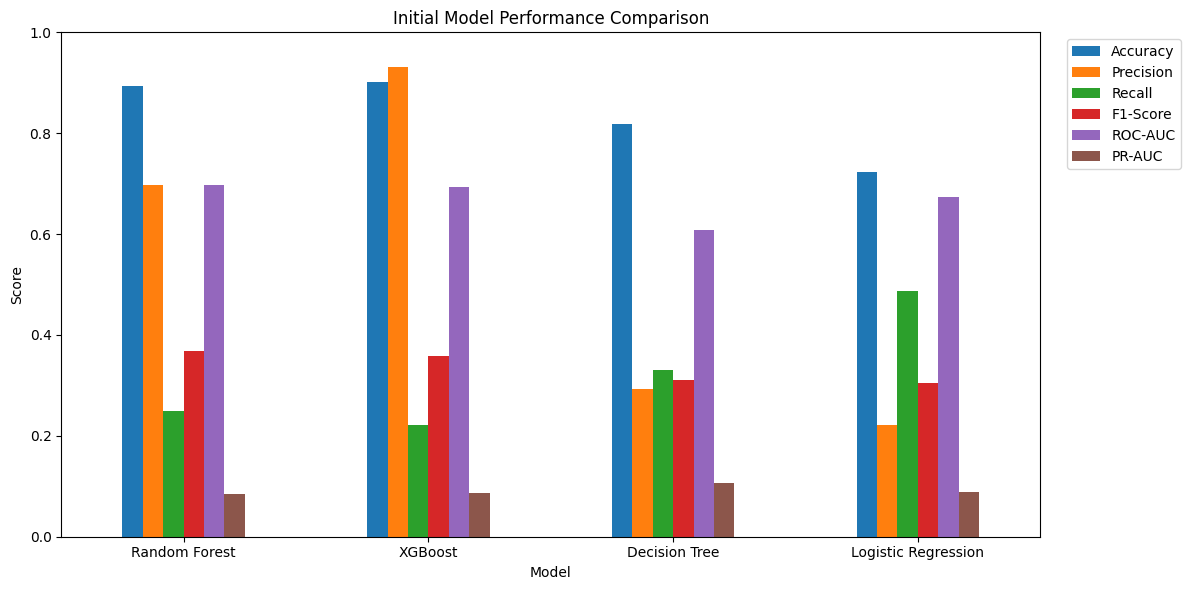

In [66]:
# Plot Metric Comparison
metrics_to_plot = [
    "Accuracy",
    "Precision",
    "Recall",
    "F1-Score",
    "ROC-AUC",
    "PR-AUC"
]

plot_data = model_comparison.set_index("Model")[metrics_to_plot]

ax = plot_data.plot(
    kind="bar",
    figsize=(12, 6)
)

plt.title("Initial Model Performance Comparison")
plt.ylabel("Score")
plt.xlabel("Model")
plt.xticks(rotation=0)
plt.ylim(0, 1)
plt.legend(
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.tight_layout()

comparison_plot_path = (
    REPORT_DIR / "initial_model_performance_comparison.png"
)

plt.savefig(
    comparison_plot_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [67]:
# Identify the Best Initial Model by F1-Score
best_initial_f1_model = model_comparison.iloc[0]["Model"]
best_initial_f1_score = model_comparison.iloc[0]["F1-Score"]

print("Best initial model based on F1-score:")
print(best_initial_f1_model)
print(f"F1-score: {best_initial_f1_score:.4f}")

Best initial model based on F1-score:
Random Forest
F1-score: 0.3680


In [68]:
# Identify the Best Initial Model by PR-AUC
best_initial_pr_auc = (
    initial_results_df
    .sort_values("PR-AUC", ascending=False)
    .iloc[0]
)

print("Best initial model based on PR-AUC:")
print(best_initial_pr_auc["Model"])
print(f"PR-AUC: {best_initial_pr_auc['PR-AUC']:.4f}")

Best initial model based on PR-AUC:
Decision Tree
PR-AUC: 0.1056


In [69]:
# Identify the Best Initial Model by Recall
best_initial_recall = (
    initial_results_df
    .sort_values("Recall", ascending=False)
    .iloc[0]
)

print("Best initial model based on Recall:")
print(best_initial_recall["Model"])
print(f"Recall: {best_initial_recall['Recall']:.4f}")

Best initial model based on Recall:
Logistic Regression
Recall: 0.4879


## Observation / Summary / Insights

- All four initial classification models were evaluated on the 2,000-record test set.
- Model performance was assessed using accuracy, precision, recall, F1-score, ROC-AUC, and PR-AUC.
- The results demonstrate why accuracy alone is insufficient for the FactoryGuard AI problem because the target variable is imbalanced.
- Precision measures how many predicted minority-class observations were actually correct.
- Recall measures how many actual minority-class observations were successfully identified.
- F1-score provides a balance between precision and recall.
- ROC-AUC measures the model's overall ability to distinguish between the two classes.
- PR-AUC provides an additional view of minority-class detection performance and is particularly useful for the imbalanced target.
- Classification reports provide class-level performance for each model.
- The initial model comparison shows which algorithms are currently the strongest candidates.
- The model with the highest F1-score or PR-AUC at this stage is only an initial candidate and is not yet the final model.
- Further analysis, cross-validation, and hyperparameter tuning will be performed before selecting the final model.

### Key Insight

The initial evaluation provides the first evidence of how different algorithms behave on the FactoryGuard AI dataset.

A model with the highest accuracy is not automatically the best model. For this project, minority-class precision, recall, F1-score, and PR-AUC are particularly important when comparing candidate models.

# Section 5 — Class-Imbalance Analysis

## Objective

The objective of this section is to analyze how well the initial classification models handle the imbalance present in the `final_pass` target variable.

The Phase 4 analysis showed that the target distribution is approximately:

- 87.61% — Majority Class
- 12.39% — Minority Class

In this section, we will focus specifically on the performance of the models on the minority class.

## Why Are We Doing This?

A model can achieve high overall accuracy while performing poorly on the minority class.

For example, if most manufacturing records belong to one class, a model could obtain high accuracy by predicting that class frequently while failing to identify the less common class.

For FactoryGuard AI, this is important because we want the model to learn useful patterns for both classes rather than simply favoring the majority class.

Therefore, we will examine:

- Minority-class Precision
- Minority-class Recall
- Minority-class F1-score
- PR-AUC
- Predicted class distribution
- Actual vs predicted class distribution

## What Will We Analyze?

For each initial model, we will determine:

1. How many minority-class observations were predicted?
2. How many of those predictions were correct?
3. How many actual minority-class observations were detected?
4. Whether the model is strongly favoring the majority class.
5. Which models provide the best balance between minority-class precision and recall.

## Expected Outcome

At the end of this section, we will have a clearer understanding of how each model handles the minority class.

This analysis will help us determine which models should be examined more closely in the following sections.

In [70]:
# Verify the Majority and Minority Classes
print("Majority Class :", majority_class)
print("Minority Class :", minority_class)

print("\nTraining Target Distribution")
print(y_train.value_counts().sort_index())

print("\nTesting Target Distribution")
print(y_test.value_counts().sort_index())

Majority Class : 1
Minority Class : 0

Training Target Distribution
final_pass
0     991
1    7009
Name: count, dtype: int64

Testing Target Distribution
final_pass
0     248
1    1752
Name: count, dtype: int64


In [71]:
# Calculate Class Distribution Percentages
train_distribution = (
    y_train.value_counts(normalize=True)
    .sort_index()
    .mul(100)
)

test_distribution = (
    y_test.value_counts(normalize=True)
    .sort_index()
    .mul(100)
)

print("Training Target Distribution (%)")
print(train_distribution.round(2))

print("\nTesting Target Distribution (%)")
print(test_distribution.round(2))

Training Target Distribution (%)
final_pass
0    12.39
1    87.61
Name: proportion, dtype: float64

Testing Target Distribution (%)
final_pass
0    12.4
1    87.6
Name: proportion, dtype: float64


In [72]:
# Compare Actual and Predicted Class Distributions
class_distribution_results = []

for name, predictions in model_predictions.items():

    predicted_counts = pd.Series(predictions).value_counts()

    predicted_majority_percentage = (
        predicted_counts.get(majority_class, 0)
        / len(predictions)
    ) * 100

    predicted_minority_percentage = (
        predicted_counts.get(minority_class, 0)
        / len(predictions)
    ) * 100

    class_distribution_results.append({
        "Model": name,
        "Predicted Majority (%)": predicted_majority_percentage,
        "Predicted Minority (%)": predicted_minority_percentage
    })

class_distribution_df = pd.DataFrame(
    class_distribution_results
)

class_distribution_df.round(2)  

,Model,Predicted Majority (%),Predicted Minority (%)
0,Logistic Regression,72.60,27.40
1,Decision Tree,86.00,14.00
2,Random Forest,95.55,4.45
3,XGBoost,97.05,2.95


In [73]:
# Calculate Minority-Class Metrics
minority_results = []

for name, predictions in model_predictions.items():

    y_proba = model_probabilities[name]

    precision = precision_score(
        y_test,
        predictions,
        pos_label=minority_class,
        zero_division=0
    )

    recall = recall_score(
        y_test,
        predictions,
        pos_label=minority_class,
        zero_division=0
    )

    f1 = f1_score(
        y_test,
        predictions,
        pos_label=minority_class,
        zero_division=0
    )

    # PR-AUC for the minority class
    minority_binary_true = (
        y_test == minority_class
    ).astype(int)

    pr_auc = average_precision_score(
        minority_binary_true,
        y_proba
    )

    minority_results.append({
        "Model": name,
        "Minority Precision": precision,
        "Minority Recall": recall,
        "Minority F1-Score": f1,
        "PR-AUC": pr_auc
    })

minority_results_df = pd.DataFrame(
    minority_results
)

minority_results_df = minority_results_df.sort_values(
    "Minority F1-Score",
    ascending=False
).reset_index(drop=True)

minority_results_df.round(4)

,Model,Minority Precision,Minority Recall,Minority F1-Score,PR-AUC
0,Random Forest,0.6966,0.2500,0.3680,0.0852
1,XGBoost,0.9322,0.2218,0.3583,0.0863
2,Decision Tree,0.2929,0.3306,0.3106,0.1056
3,Logistic Regression,0.2208,0.4879,0.3040,0.0892


In [74]:
# Compare Minority-Class Recall
recall_comparison = minority_results_df[
    ["Model", "Minority Recall"]
].sort_values(
    "Minority Recall",
    ascending=False
)

recall_comparison.round(4)

,Model,Minority Recall
3,Logistic Regression,0.4879
2,Decision Tree,0.3306
0,Random Forest,0.2500
1,XGBoost,0.2218


In [75]:
# Compare Minority-Class Precision
precision_comparison = minority_results_df[
    ["Model", "Minority Precision"]
].sort_values(
    "Minority Precision",
    ascending=False
)

precision_comparison.round(4)

,Model,Minority Precision
1,XGBoost,0.9322
0,Random Forest,0.6966
2,Decision Tree,0.2929
3,Logistic Regression,0.2208


In [76]:
# Compare Minority-Class F1-Score
f1_comparison = minority_results_df[
    ["Model", "Minority F1-Score"]
].sort_values(
    "Minority F1-Score",
    ascending=False
)

f1_comparison.round(4)

,Model,Minority F1-Score
0,Random Forest,0.3680
1,XGBoost,0.3583
2,Decision Tree,0.3106
3,Logistic Regression,0.3040


In [77]:
# Calculate Minority-Class Detection Rate
minority_detection_results = []

actual_minority_count = (
    y_test == minority_class
).sum()

for name, predictions in model_predictions.items():

    detected_minority_count = (
        (predictions == minority_class) &
        (y_test == minority_class)
    ).sum()

    detection_rate = (
        detected_minority_count /
        actual_minority_count
    ) * 100

    minority_detection_results.append({
        "Model": name,
        "Actual Minority Records": actual_minority_count,
        "Correctly Detected Minority Records": detected_minority_count,
        "Detection Rate (%)": detection_rate
    })

minority_detection_df = pd.DataFrame(
    minority_detection_results
)

minority_detection_df.round(2)

,Model,Actual Minority Records,Correctly Detected Minority Records,Detection Rate (%)
0,Logistic Regression,248,121,48.79
1,Decision Tree,248,82,33.06
2,Random Forest,248,62,25.00
3,XGBoost,248,55,22.18


In [78]:
# Create Complete Imbalance Analysis Table
imbalance_analysis = minority_results_df.merge(
    class_distribution_df,
    on="Model"
)

imbalance_analysis = imbalance_analysis.merge(
    minority_detection_df,
    on="Model"
)

imbalance_analysis.round(4)

,Model,Minority Precision,Minority Recall,Minority F1-Score,PR-AUC,Predicted Majority (%),Predicted Minority (%),Actual Minority Records,Correctly Detected Minority Records,Detection Rate (%)
0,Random Forest,0.6966,0.2500,0.3680,0.0852,95.55,4.45,248,62,25.0000
1,XGBoost,0.9322,0.2218,0.3583,0.0863,97.05,2.95,248,55,22.1774
2,Decision Tree,0.2929,0.3306,0.3106,0.1056,86.00,14.00,248,82,33.0645
3,Logistic Regression,0.2208,0.4879,0.3040,0.0892,72.60,27.40,248,121,48.7903


In [79]:
# Save the Imbalance Analysis
imbalance_analysis.to_csv(
    REPORT_DIR / "class_imbalance_analysis.csv",
    index=False
)
print("✓ Class imbalance analysis saved.")

✓ Class imbalance analysis saved.


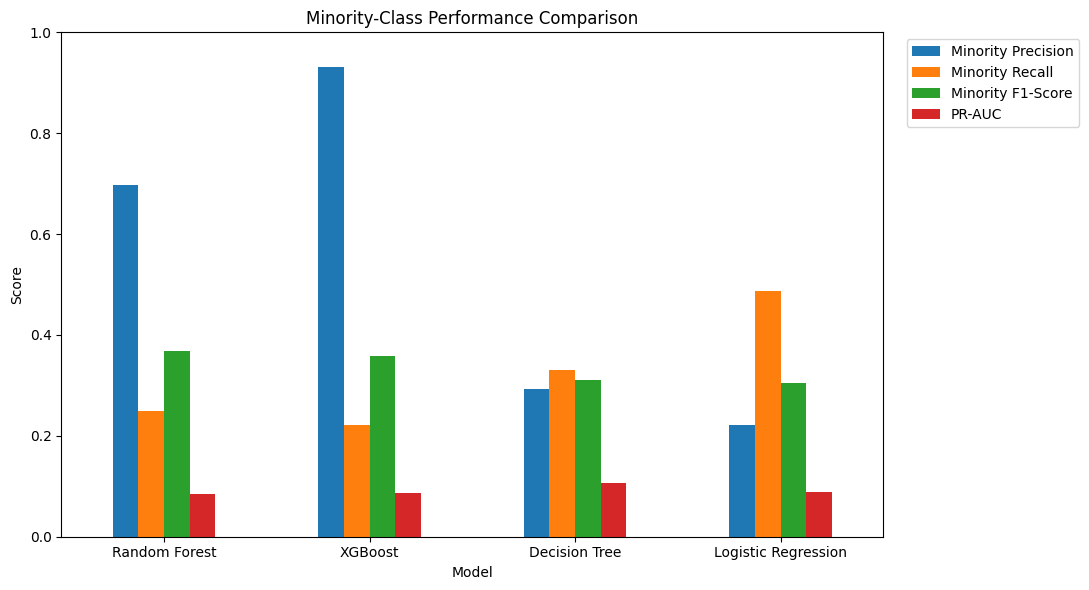

In [80]:
plot_data = minority_results_df.set_index("Model")[
    [
        "Minority Precision",
        "Minority Recall",
        "Minority F1-Score",
        "PR-AUC"
    ]
]

ax = plot_data.plot(
    kind="bar",
    figsize=(11, 6)
)

plt.title("Minority-Class Performance Comparison")
plt.xlabel("Model")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.legend(
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.tight_layout()

minority_plot_path = (
    REPORT_DIR /
    "minority_class_performance_comparison.png"
)

plt.savefig(
    minority_plot_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

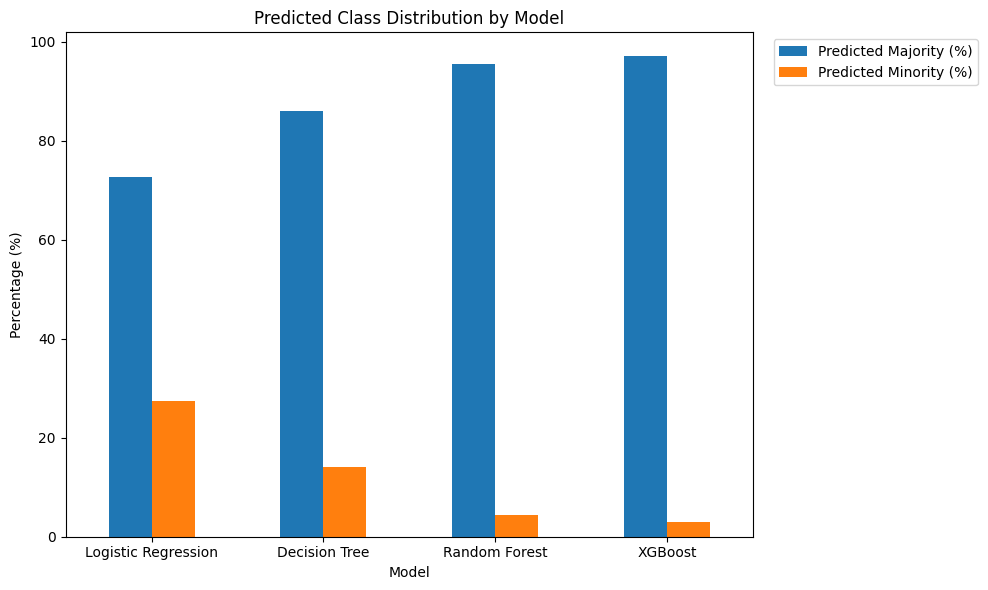

In [81]:
# Visualize Predicted Class Distribution
distribution_plot_data = class_distribution_df.set_index(
    "Model"
)[
    [
        "Predicted Majority (%)",
        "Predicted Minority (%)"
    ]
]

ax = distribution_plot_data.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Predicted Class Distribution by Model")
plt.xlabel("Model")
plt.ylabel("Percentage (%)")
plt.xticks(rotation=0)
plt.legend(
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.tight_layout()

distribution_plot_path = (
    REPORT_DIR /
    "predicted_class_distribution.png"
)

plt.savefig(
    distribution_plot_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Observation / Summary / Insights

- The target variable is imbalanced, with approximately 87.61% majority-class observations and 12.39% minority-class observations.
- The initial models were analyzed specifically for their ability to identify the minority class.
- Minority-class precision, recall, F1-score, and PR-AUC provide more meaningful information than accuracy alone for this dataset.
- Minority-class recall indicates how many actual minority-class observations were successfully detected by each model.
- Minority-class precision indicates how reliable the model's minority-class predictions are.
- Minority-class F1-score provides a balance between precision and recall.
- The predicted class distribution helps identify models that may be strongly biased toward the majority class.
- The models show different levels of minority-class detection, demonstrating that model choice can significantly affect performance under class imbalance.
- The class-imbalance analysis has been saved for use during model comparison and final model selection.

### Key Insight

The main objective is not simply to maximize the number of correct predictions.

For FactoryGuard AI, we need a model that can identify the less frequent class while maintaining an acceptable number of false positive predictions.

Therefore, minority-class recall, precision, F1-score, and PR-AUC will play an important role when selecting the strongest candidate models.

# Section 6 — Confusion Matrix Analysis

## Objective

The objective of this section is to analyze the specific types of classification errors made by each initial model.

Instead of looking only at overall metrics such as accuracy, precision, recall, and F1-score, we will examine the predictions using confusion matrices.

## Why Are We Doing This?

A classification metric gives us a numerical summary of model performance, but it does not show exactly what kinds of mistakes the model is making.

A confusion matrix separates predictions into four categories:

- True Negative (TN) — correctly predicted majority-class observations.
- False Positive (FP) — majority-class observations incorrectly predicted as the minority class.
- False Negative (FN) — minority-class observations incorrectly predicted as the majority class.
- True Positive (TP) — correctly predicted minority-class observations.

For FactoryGuard AI, this distinction is important because the target variable is imbalanced.

A model may have good overall accuracy while still producing many false negatives for the minority class.

Therefore, confusion matrices will help us understand whether each model is:

- Detecting the minority class effectively.
- Missing a large number of minority-class observations.
- Producing too many false positive predictions.
- Favoring the majority class.

## What We Will Do

For each of the four initial models, we will:

1. Generate the confusion matrix.
2. Extract TN, FP, FN, and TP values.
3. Calculate error-related metrics.
4. Visualize the confusion matrix.
5. Compare the error patterns across models.

## Expected Outcome

At the end of this section, we should understand not only how well each model performs, but also what types of mistakes each model makes.

These results will be used together with the metrics from Sections 4 and 5 during model comparison.

In [82]:
from sklearn.metrics import confusion_matrix

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [84]:
# Convert Confusion Matrices into DataFrames
confusion_matrix_tables = {}

for name, cm in confusion_matrices.items():

    cm_df = pd.DataFrame(
        cm,
        index=[
            f"Actual {majority_class}",
            f"Actual {minority_class}"
        ],
        columns=[
            f"Predicted {majority_class}",
            f"Predicted {minority_class}"
        ]
    )

    confusion_matrix_tables[name] = cm_df

    print(f"\n{name}")
    print(cm_df)


Logistic Regression
          Predicted 1  Predicted 0
Actual 1         1325          427
Actual 0          127          121

Decision Tree
          Predicted 1  Predicted 0
Actual 1         1554          198
Actual 0          166           82

Random Forest
          Predicted 1  Predicted 0
Actual 1         1725           27
Actual 0          186           62

XGBoost
          Predicted 1  Predicted 0
Actual 1         1748            4
Actual 0          193           55


In [85]:
# Extract TN, FP, FN and TP
confusion_matrix_results = []

for name, cm in confusion_matrices.items():

    tn, fp, fn, tp = cm.ravel()

    confusion_matrix_results.append({
        "Model": name,
        "True Negative": tn,
        "False Positive": fp,
        "False Negative": fn,
        "True Positive": tp
    })

confusion_matrix_results_df = pd.DataFrame(
    confusion_matrix_results
)

confusion_matrix_results_df

,Model,True Negative,False Positive,False Negative,True Positive
0,Logistic Regression,1325,427,127,121
1,Decision Tree,1554,198,166,82
2,Random Forest,1725,27,186,62
3,XGBoost,1748,4,193,55


In [86]:
# Calculate Error Rates
error_rate_results = []

for row in confusion_matrix_results:

    tn = row["True Negative"]
    fp = row["False Positive"]
    fn = row["False Negative"]
    tp = row["True Positive"]

    false_positive_rate = (
        fp / (fp + tn)
        if (fp + tn) > 0
        else 0
    )

    false_negative_rate = (
        fn / (fn + tp)
        if (fn + tp) > 0
        else 0
    )

    error_rate_results.append({
        "Model": row["Model"],
        "False Positive Rate": false_positive_rate,
        "False Negative Rate": false_negative_rate
    })

error_rate_df = pd.DataFrame(
    error_rate_results
)

error_rate_df.round(4)

,Model,False Positive Rate,False Negative Rate
0,Logistic Regression,0.2437,0.5121
1,Decision Tree,0.1130,0.6694
2,Random Forest,0.0154,0.7500
3,XGBoost,0.0023,0.7782


In [87]:
# Combine Confusion Matrix Results
confusion_analysis = (
    confusion_matrix_results_df
    .merge(error_rate_df, on="Model")
)

confusion_analysis.round(4)

,Model,True Negative,False Positive,False Negative,True Positive,False Positive Rate,False Negative Rate
0,Logistic Regression,1325,427,127,121,0.2437,0.5121
1,Decision Tree,1554,198,166,82,0.1130,0.6694
2,Random Forest,1725,27,186,62,0.0154,0.7500
3,XGBoost,1748,4,193,55,0.0023,0.7782


In [88]:
# Save Confusion Matrix Results
confusion_analysis.to_csv(
    REPORT_DIR / "confusion_matrix_analysis.csv",
    index=False
)

print("✓ Confusion matrix analysis saved.")

✓ Confusion matrix analysis saved.


In [89]:
for name, cm_df in confusion_matrix_tables.items():

    safe_name = (
        name
        .lower()
        .replace(" ", "_")
        .replace("-", "_")
    )

    cm_df.to_csv(
        REPORT_DIR / f"{safe_name}_confusion_matrix.csv"
    )

print("✓ Individual confusion matrices saved.")

✓ Individual confusion matrices saved.


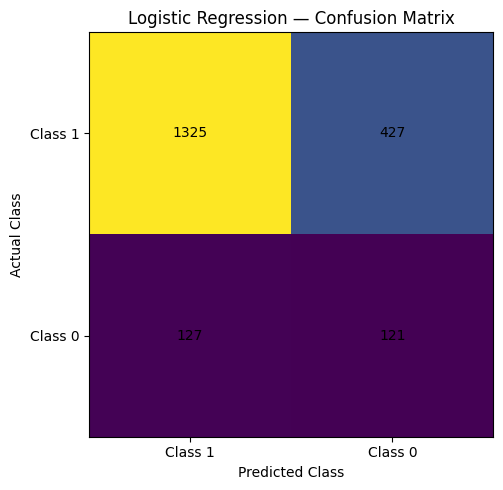

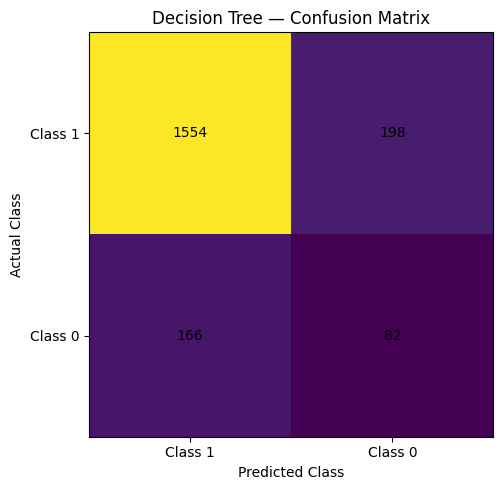

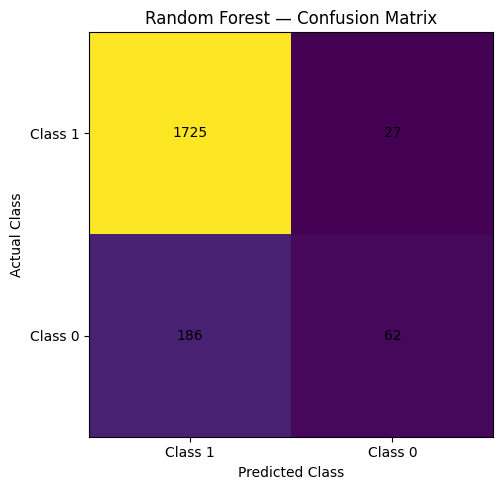

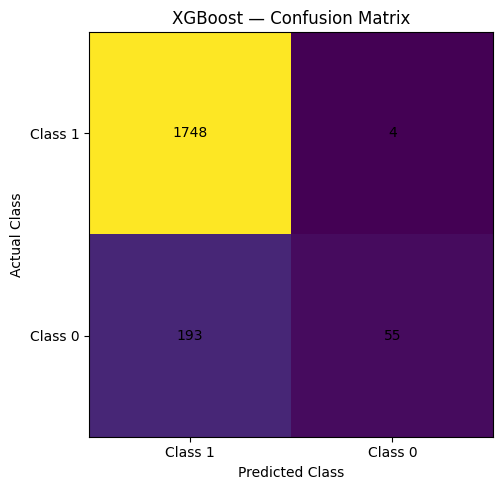

In [90]:
# Create Visual Confusion Matrices
for name, cm in confusion_matrices.items():

    fig, ax = plt.subplots(figsize=(6, 5))

    image = ax.imshow(cm)

    ax.set_title(f"{name} — Confusion Matrix")
    ax.set_xlabel("Predicted Class")
    ax.set_ylabel("Actual Class")

    ax.set_xticks([0, 1])
    ax.set_yticks([0, 1])

    ax.set_xticklabels([
        f"Class {majority_class}",
        f"Class {minority_class}"
    ])

    ax.set_yticklabels([
        f"Class {majority_class}",
        f"Class {minority_class}"
    ])

    # Add values inside the matrix
    for i in range(2):
        for j in range(2):
            ax.text(
                j,
                i,
                str(cm[i, j]),
                ha="center",
                va="center"
            )

    plt.tight_layout()

    safe_name = (
        name
        .lower()
        .replace(" ", "_")
        .replace("-", "_")
    )

    output_path = (
        REPORT_DIR /
        f"{safe_name}_confusion_matrix.png"
    )

    plt.savefig(
        output_path,
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()
    plt.close()

In [91]:
# Compare False Positive and False Negative Rates
error_rate_comparison = error_rate_df.copy()
error_rate_comparison.round(4)

,Model,False Positive Rate,False Negative Rate
0,Logistic Regression,0.2437,0.5121
1,Decision Tree,0.1130,0.6694
2,Random Forest,0.0154,0.7500
3,XGBoost,0.0023,0.7782


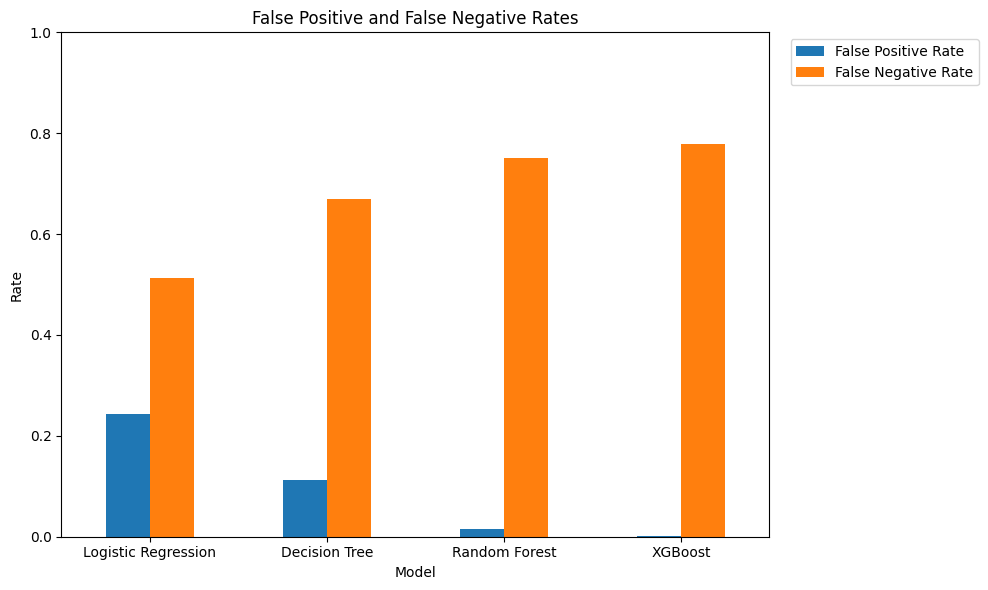

In [92]:
# Visualize Error Rates
plot_data = error_rate_comparison.set_index("Model")[
    [
        "False Positive Rate",
        "False Negative Rate"
    ]
]

ax = plot_data.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("False Positive and False Negative Rates")
plt.xlabel("Model")
plt.ylabel("Rate")
plt.xticks(rotation=0)
plt.ylim(0, 1)

plt.legend(
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.tight_layout()

error_plot_path = (
    REPORT_DIR /
    "false_positive_negative_rate_comparison.png"
)

plt.savefig(
    error_plot_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [94]:
# Display the Complete Confusion Analysis
print("Complete Confusion Matrix Analysis")
print("=" * 70)

display(
    confusion_analysis.round(4)
)

Complete Confusion Matrix Analysis


,Model,True Negative,False Positive,False Negative,True Positive,False Positive Rate,False Negative Rate
0,Logistic Regression,1325,427,127,121,0.2437,0.5121
1,Decision Tree,1554,198,166,82,0.1130,0.6694
2,Random Forest,1725,27,186,62,0.0154,0.7500
3,XGBoost,1748,4,193,55,0.0023,0.7782


## Observation / Summary / Insights

- Confusion matrices were generated for all four initial classification models.
- Each confusion matrix separates predictions into True Negatives, False Positives, False Negatives, and True Positives.
- True Positives represent correctly detected minority-class observations.
- False Negatives represent minority-class observations that were incorrectly classified as the majority class.
- False Positives represent majority-class observations that were incorrectly classified as the minority class.
- The number of False Negatives is particularly important because it indicates how many actual minority-class observations the model failed to detect.
- The False Positive Rate and False Negative Rate provide additional information about the types of errors produced by each model.
- The models exhibit different error patterns, showing that overall metrics alone do not provide the complete picture of model behavior.
- Confusion matrix results and visualizations have been saved for use in the final project report.

### Key Insight

A good FactoryGuard AI model should not only achieve strong overall performance but should also maintain an acceptable balance between False Positives and False Negatives.

Because the target is imbalanced, the number of False Negatives and the model's ability to correctly identify the minority class will be particularly important during final model comparison.

# Section 7 — Model Comparison & Candidate Selection

## Objective

The objective of this section is to bring together the evaluation results from the previous sections and systematically compare the four initial classification models:

1. Logistic Regression
2. Decision Tree
3. Random Forest
4. XGBoost

We will use the results from:

- Initial model evaluation
- Class-imbalance analysis
- Confusion matrix analysis

to identify the most promising models for the next stages of Phase 5.

## Why Are We Doing This?

Different evaluation metrics measure different aspects of model performance.

Accuracy measures overall correctness, while precision, recall, and F1-score provide more information about minority-class predictions.

ROC-AUC measures overall class discrimination, while PR-AUC is particularly useful for evaluating performance under class imbalance.

Confusion matrices additionally show the types of errors made by each model.

Therefore, selecting a model using only one metric could give a misleading result.

The goal of this section is to evaluate the models as a whole and shortlist the strongest candidates rather than immediately declaring a final model.

## Selection Criteria

The comparison will consider:

- Accuracy
- Minority-class Precision
- Minority-class Recall
- Minority-class F1-score
- ROC-AUC
- PR-AUC
- False Positive Rate
- False Negative Rate
- Model training time

Because the target variable is imbalanced, greater importance will be given to minority-class performance, particularly F1-score, Recall, and PR-AUC.

## Expected Outcome

At the end of this section:

- All four models will be compared in one consolidated table.
- The strengths and weaknesses of each model will be identified.
- The strongest candidate models will be shortlisted.
- The shortlisted models will be taken forward to cross-validation and hyperparameter tuning.

The final model will NOT be selected in this section.

In [95]:
# Combine Model Evaluation Results
# Initial model metrics
comparison_df = initial_results_df[
    [
        "Model",
        "Accuracy",
        "Precision",
        "Recall",
        "F1-Score",
        "ROC-AUC",
        "PR-AUC",
        "Training Time (seconds)"
    ]
].copy()

# Rename metrics for clarity
comparison_df = comparison_df.rename(
    columns={
        "Precision": "Minority Precision",
        "Recall": "Minority Recall",
        "F1-Score": "Minority F1-Score"
    }
)

# Confusion matrix error metrics
comparison_df = comparison_df.merge(
    error_rate_df,
    on="Model",
    how="left"
)

comparison_df.round(4)

,Model,Accuracy,Minority Precision,Minority Recall,Minority F1-Score,ROC-AUC,PR-AUC,Training Time (seconds),False Positive Rate,False Negative Rate
0,Logistic Regression,0.7230,0.2208,0.4879,0.3040,0.6739,0.0892,0.4059,0.2437,0.5121
1,Decision Tree,0.8180,0.2929,0.3306,0.3106,0.6088,0.1056,0.1718,0.1130,0.6694
2,Random Forest,0.8935,0.6966,0.2500,0.3680,0.6979,0.0852,1.6521,0.0154,0.7500
3,XGBoost,0.9015,0.9322,0.2218,0.3583,0.6925,0.0863,1.3275,0.0023,0.7782


In [96]:
# Create a Complete Model Comparison Table
model_comparison_complete = comparison_df[
    [
        "Model",
        "Accuracy",
        "Minority Precision",
        "Minority Recall",
        "Minority F1-Score",
        "ROC-AUC",
        "PR-AUC",
        "False Positive Rate",
        "False Negative Rate",
        "Training Time (seconds)"
    ]
].copy()

model_comparison_complete.round(4)

,Model,Accuracy,Minority Precision,Minority Recall,Minority F1-Score,ROC-AUC,PR-AUC,False Positive Rate,False Negative Rate,Training Time (seconds)
0,Logistic Regression,0.7230,0.2208,0.4879,0.3040,0.6739,0.0892,0.2437,0.5121,0.4059
1,Decision Tree,0.8180,0.2929,0.3306,0.3106,0.6088,0.1056,0.1130,0.6694,0.1718
2,Random Forest,0.8935,0.6966,0.2500,0.3680,0.6979,0.0852,0.0154,0.7500,1.6521
3,XGBoost,0.9015,0.9322,0.2218,0.3583,0.6925,0.0863,0.0023,0.7782,1.3275


In [97]:
# Rank Models by Individual Metrics
ranking_metrics = [
    "Accuracy",
    "Minority Precision",
    "Minority Recall",
    "Minority F1-Score",
    "ROC-AUC",
    "PR-AUC"
]

metric_rankings = {}

for metric in ranking_metrics:

    metric_rankings[metric] = (
        model_comparison_complete[
            ["Model", metric]
        ]
        .sort_values(
            metric,
            ascending=False
        )
        .reset_index(drop=True)
    )

    print(f"\n{metric}")
    print("=" * 50)
    print(metric_rankings[metric].round(4))


Accuracy
                 Model  Accuracy
0              XGBoost    0.9015
1        Random Forest    0.8935
2        Decision Tree    0.8180
3  Logistic Regression    0.7230

Minority Precision
                 Model  Minority Precision
0              XGBoost              0.9322
1        Random Forest              0.6966
2        Decision Tree              0.2929
3  Logistic Regression              0.2208

Minority Recall
                 Model  Minority Recall
0  Logistic Regression           0.4879
1        Decision Tree           0.3306
2        Random Forest           0.2500
3              XGBoost           0.2218

Minority F1-Score
                 Model  Minority F1-Score
0        Random Forest             0.3680
1              XGBoost             0.3583
2        Decision Tree             0.3106
3  Logistic Regression             0.3040

ROC-AUC
                 Model  ROC-AUC
0        Random Forest   0.6979
1              XGBoost   0.6925
2  Logistic Regression   0.6739
3      

In [98]:
# Create a Rank Table
rank_table = model_comparison_complete[
    ["Model"] + ranking_metrics
].copy()

for metric in ranking_metrics:

    rank_table[f"{metric} Rank"] = (
        rank_table[metric]
        .rank(
            ascending=False,
            method="min"
        )
    )

rank_table

,Model,Accuracy,Minority Precision,Minority Recall,Minority F1-Score,ROC-AUC,PR-AUC,Accuracy Rank,Minority Precision Rank,Minority Recall Rank,Minority F1-Score Rank,ROC-AUC Rank,PR-AUC Rank
0,Logistic Regression,0.7230,0.220803,0.487903,0.304020,0.673893,0.089180,4.0,4.0,1.0,4.0,3.0,2.0
1,Decision Tree,0.8180,0.292857,0.330645,0.310606,0.608816,0.105601,3.0,3.0,2.0,3.0,4.0,1.0
2,Random Forest,0.8935,0.696629,0.250000,0.367953,0.697921,0.085229,2.0,2.0,3.0,1.0,1.0,4.0
3,XGBoost,0.9015,0.932203,0.221774,0.358306,0.692538,0.086338,1.0,1.0,4.0,2.0,2.0,3.0


In [99]:
# Calculate Average Performance Rank
rank_columns = [
    f"{metric} Rank"
    for metric in ranking_metrics
]

rank_table["Average Rank"] = (
    rank_table[rank_columns]
    .mean(axis=1)
)

rank_table = rank_table.sort_values(
    "Average Rank"
).reset_index(drop=True)

rank_table[
    ["Model", "Average Rank"] +
    rank_columns
]

,Model,Average Rank,Accuracy Rank,Minority Precision Rank,Minority Recall Rank,Minority F1-Score Rank,ROC-AUC Rank,PR-AUC Rank
0,XGBoost,2.166667,1.0,1.0,4.0,2.0,2.0,3.0
1,Random Forest,2.166667,2.0,2.0,3.0,1.0,1.0,4.0
2,Decision Tree,2.666667,3.0,3.0,2.0,3.0,4.0,1.0
3,Logistic Regression,3.000000,4.0,4.0,1.0,4.0,3.0,2.0


In [100]:
# Identify Strong Candidates
candidate_models = rank_table[
    "Model"
].head(2).tolist()

print("Initial candidate models:")
for i, model_name in enumerate(candidate_models, start=1):
    print(f"{i}. {model_name}")

Initial candidate models:
1. XGBoost
2. Random Forest


In [101]:
# Examine Candidate Performance
candidate_comparison = model_comparison_complete[
    model_comparison_complete["Model"].isin(
        candidate_models
    )
].copy()

candidate_comparison.round(4)

,Model,Accuracy,Minority Precision,Minority Recall,Minority F1-Score,ROC-AUC,PR-AUC,False Positive Rate,False Negative Rate,Training Time (seconds)
2,Random Forest,0.8935,0.6966,0.2500,0.3680,0.6979,0.0852,0.0154,0.7500,1.6521
3,XGBoost,0.9015,0.9322,0.2218,0.3583,0.6925,0.0863,0.0023,0.7782,1.3275


In [102]:
# Compare Candidate Confusion Matrices
for name in candidate_models:

    print("\n" + "=" * 60)
    print(name)
    print("=" * 60)

    display(
        confusion_matrix_tables[name]
    )


XGBoost


,Predicted 1,Predicted 0
Actual 1,1748,4
Actual 0,193,55



Random Forest


,Predicted 1,Predicted 0
Actual 1,1725,27
Actual 0,186,62


In [103]:
# Compare Candidate Error Rates
candidate_error_rates = error_rate_df[
    error_rate_df["Model"].isin(candidate_models)
].copy()

candidate_error_rates.round(4)

,Model,False Positive Rate,False Negative Rate
2,Random Forest,0.0154,0.7500
3,XGBoost,0.0023,0.7782


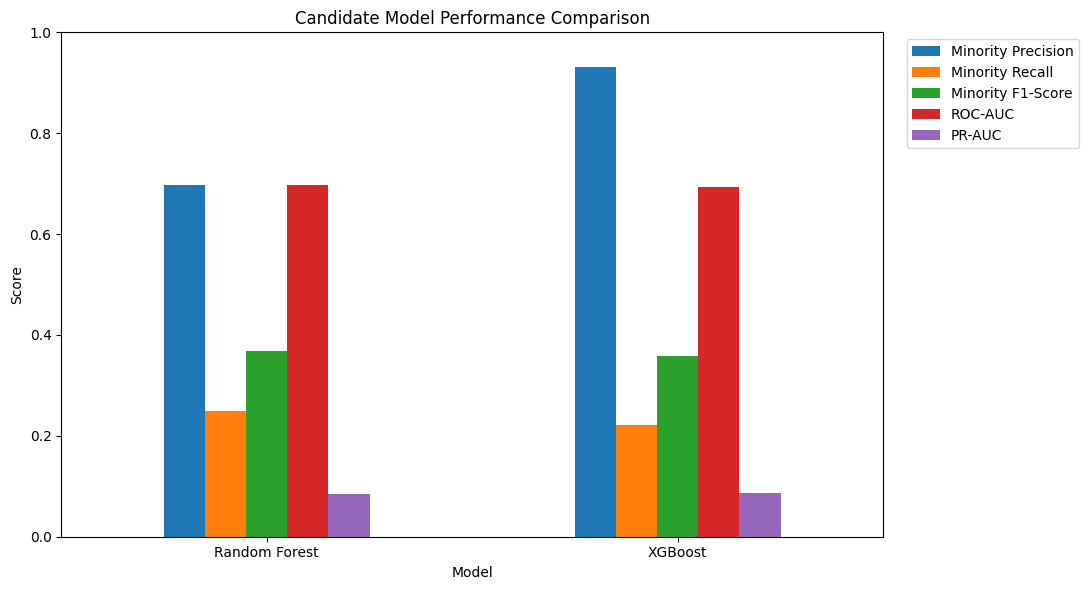

In [104]:
# Create a Candidate Comparison Visualization
candidate_plot_data = candidate_comparison.set_index(
    "Model"
)[
    [
        "Minority Precision",
        "Minority Recall",
        "Minority F1-Score",
        "ROC-AUC",
        "PR-AUC"
    ]
]

ax = candidate_plot_data.plot(
    kind="bar",
    figsize=(11, 6)
)

plt.title("Candidate Model Performance Comparison")
plt.xlabel("Model")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=0)

plt.legend(
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.tight_layout()

candidate_plot_path = (
    REPORT_DIR /
    "candidate_model_comparison.png"
)

plt.savefig(
    candidate_plot_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [105]:
# Save Complete Comparison Results
model_comparison_complete.to_csv(
    REPORT_DIR / "complete_model_comparison.csv",
    index=False
)

rank_table.to_csv(
    REPORT_DIR / "model_metric_rankings.csv",
    index=False
)

candidate_comparison.to_csv(
    REPORT_DIR / "candidate_model_comparison.csv",
    index=False
)

print("✓ Model comparison results saved.")

✓ Model comparison results saved.


In [107]:
# Save Candidate Model Names
candidate_models_df = pd.DataFrame({
    "Candidate_Model": candidate_models
})

candidate_models_df.to_csv(
    REPORT_DIR / "selected_candidate_models.csv",
    index=False
)

print("✓ Candidate model list saved.")

✓ Candidate model list saved.


## Observation / Summary / Insights

- The four initial classification models were compared using multiple performance metrics.
- Accuracy was considered alongside minority-class precision, recall, F1-score, ROC-AUC, and PR-AUC.
- False Positive Rate and False Negative Rate were also considered to understand the types of errors produced by each model.
- The results demonstrate that no single metric is sufficient for selecting the best FactoryGuard AI model.
- Models were ranked across the major evaluation metrics to identify consistently strong performers.
- The strongest candidate models were shortlisted for further validation and hyperparameter tuning.
- The shortlisted models are not yet considered the final model.
- The complete comparison and candidate-model results were saved in the Phase 5 reports directory.

### Key Insight

Model selection for FactoryGuard AI should balance overall predictive performance with minority-class detection.

A model that performs well across F1-score, recall, PR-AUC, and ROC-AUC is generally more promising than a model that achieves high accuracy but performs poorly on the minority class.

The shortlisted models will now undergo cross-validation to determine whether their performance is consistent across different subsets of the training data.

## Observation / Summary / Insights

- The four initial classification models were compared using multiple performance metrics.
- Accuracy was considered alongside minority-class precision, recall, F1-score, ROC-AUC, and PR-AUC.
- False Positive Rate and False Negative Rate were also considered to understand the types of errors produced by each model.
- The results demonstrate that no single metric is sufficient for selecting the best FactoryGuard AI model.
- Models were ranked across the major evaluation metrics to identify consistently strong performers.
- The strongest candidate models were shortlisted for further validation and hyperparameter tuning.
- The shortlisted models are not yet considered the final model.
- The complete comparison and candidate-model results were saved in the Phase 5 reports directory.

### Key Insight
# Section 8 — Cross-Validation

## Objective

The objective of this section is to determine whether the shortlisted classification models provide consistent and reliable performance across different subsets of the training data.

In Section 7, the initial models were compared and the strongest candidate models were shortlisted.

Instead of evaluating these candidates on only one data split, we will use Stratified K-Fold Cross-Validation on the training dataset.

## Why Are We Doing This?

A model may perform well on one particular train-validation split simply because of the characteristics of that split.

Cross-validation reduces this dependence by repeatedly training and validating the model on different portions of the training data.

Because `final_pass` is imbalanced, we will use Stratified K-Fold Cross-Validation. Stratification ensures that each fold maintains a similar class distribution.

We will use 5 folds:

    Fold 1 → Validation
    Fold 2 → Validation
    Fold 3 → Validation
    Fold 4 → Validation
    Fold 5 → Validation

Each fold is used as validation data once, while the remaining four folds are used for training.

## Important Data-Splitting Rule

The original 2,000-record test set will NOT be used during cross-validation.

Cross-validation will be performed only on:

    X_train
    y_train

The test set will remain untouched until the final model has been selected.

## Metrics

We will evaluate each candidate model using:

- Accuracy
- Minority-class Precision
- Minority-class Recall
- Minority-class F1-score
- ROC-AUC
- PR-AUC

For every metric, we will calculate:

- Mean score across the 5 folds
- Standard deviation across the 5 folds

The mean represents average performance, while the standard deviation indicates how consistent the model is across different folds.

## Expected Outcome

At the end of this section, we will know:

- How consistently each candidate model performs.
- Which model has the strongest average performance.
- How much model performance varies between folds.
- Whether the candidate models are stable enough to proceed to hyperparameter tuning.
Model selection for FactoryGuard AI should balance overall predictive performance with minority-class detection.

A model that performs well across F1-score, recall, PR-AUC, and ROC-AUC is generally more promising than a model that achieves high accuracy but performs poorly on the minority class.

The shortlisted models will now undergo cross-validation to determine whether their performance is consistent across different subsets of the training data.

In [108]:
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.base import clone

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [109]:
# Verify Candidate Models
print("Candidate models for cross-validation:")
print("=" * 50)

for model_name in candidate_models:
    print(f"✓ {model_name}")

Candidate models for cross-validation:
✓ XGBoost
✓ Random Forest


In [110]:
# Create Stratified 5-Fold Cross-Validation
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

print("Cross-validation strategy:")
print(cv)

Cross-validation strategy:
StratifiedKFold(n_splits=5, random_state=42, shuffle=True)


In [111]:
# Define Minority-Class Evaluation Functions
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score
)
# Minority Precision
def minority_precision_scorer(estimator, X, y):
    y_pred = estimator.predict(X)

    return precision_score(
        y,
        y_pred,
        pos_label=minority_class,
        zero_division=0
    )
# Minority Recall
def minority_recall_scorer(estimator, X, y):
    y_pred = estimator.predict(X)

    return recall_score(
        y,
        y_pred,
        pos_label=minority_class,
        zero_division=0
    )
# Minority F1-score
def minority_f1_scorer(estimator, X, y):
    y_pred = estimator.predict(X)

    return f1_score(
        y,
        y_pred,
        pos_label=minority_class,
        zero_division=0
    )

In [112]:
# Define ROC-AUC Scorer
def minority_roc_auc_scorer(estimator, X, y):

    y_proba = estimator.predict_proba(X)

    minority_index = list(
        estimator.classes_
    ).index(minority_class)

    minority_probability = y_proba[:, minority_index]

    y_binary = (
        y == minority_class
    ).astype(int)

    return roc_auc_score(
        y_binary,
        minority_probability
    )

In [113]:
# Define PR-AUC Scorer
def minority_pr_auc_scorer(estimator, X, y):

    y_proba = estimator.predict_proba(X)

    minority_index = list(
        estimator.classes_
    ).index(minority_class)

    minority_probability = y_proba[:, minority_index]

    y_binary = (
        y == minority_class
    ).astype(int)

    return average_precision_score(
        y_binary,
        minority_probability
    )

In [114]:
# Define the Cross-Validation Metrics
scoring = {
    "accuracy": "accuracy",
    "minority_precision": minority_precision_scorer,
    "minority_recall": minority_recall_scorer,
    "minority_f1": minority_f1_scorer,
    "roc_auc": minority_roc_auc_scorer,
    "pr_auc": minority_pr_auc_scorer
}

In [115]:
# Run 5-Fold Cross-Validation
cv_results = {}

for model_name in candidate_models:

    print(f"\nRunning 5-Fold CV for {model_name}...")

    model = clone(
        models[model_name]
    )

    results = cross_validate(
        estimator=model,
        X=X_train,
        y=y_train,
        cv=cv,
        scoring=scoring,
        n_jobs=-1,
        return_train_score=False
    )

    cv_results[model_name] = results

    print(f"✓ {model_name} cross-validation completed.")


Running 5-Fold CV for XGBoost...
✓ XGBoost cross-validation completed.

Running 5-Fold CV for Random Forest...
✓ Random Forest cross-validation completed.


In [116]:
# Display Individual Fold Results
for model_name, results in cv_results.items():

    print("\n" + "=" * 70)
    print(model_name)
    print("=" * 70)

    fold_results = pd.DataFrame({
        "Fold": range(1, 6),
        "Accuracy": results["test_accuracy"],
        "Minority Precision": results["test_minority_precision"],
        "Minority Recall": results["test_minority_recall"],
        "Minority F1": results["test_minority_f1"],
        "ROC-AUC": results["test_roc_auc"],
        "PR-AUC": results["test_pr_auc"]
    })

    display(
        fold_results.round(4)
    )


XGBoost


,Fold,Accuracy,Minority Precision,Minority Recall,Minority F1,ROC-AUC,PR-AUC
0,1,0.8975,0.8864,0.1970,0.3223,0.6372,0.3923
1,2,0.9006,1.0000,0.1970,0.3291,0.6739,0.4276
2,3,0.9012,0.8704,0.2374,0.3730,0.6635,0.4234
3,4,0.8956,0.8780,0.1818,0.3013,0.6743,0.3961
4,5,0.9031,0.9400,0.2362,0.3775,0.6735,0.4365



Random Forest


,Fold,Accuracy,Minority Precision,Minority Recall,Minority F1,ROC-AUC,PR-AUC
0,1,0.8881,0.6267,0.2374,0.3443,0.6417,0.3768
1,2,0.8956,0.7067,0.2677,0.3883,0.6791,0.4394
2,3,0.8925,0.6585,0.2727,0.3857,0.6703,0.4214
3,4,0.8900,0.6571,0.2323,0.3433,0.6680,0.4005
4,5,0.8900,0.6322,0.2764,0.3846,0.6924,0.4437


In [117]:
# Calculate Mean and Standard Deviation
cv_summary = []

for model_name, results in cv_results.items():

    cv_summary.append({
        "Model": model_name,

        "Accuracy Mean":
            results["test_accuracy"].mean(),

        "Accuracy Std":
            results["test_accuracy"].std(),

        "Minority Precision Mean":
            results["test_minority_precision"].mean(),

        "Minority Precision Std":
            results["test_minority_precision"].std(),

        "Minority Recall Mean":
            results["test_minority_recall"].mean(),

        "Minority Recall Std":
            results["test_minority_recall"].std(),

        "Minority F1 Mean":
            results["test_minority_f1"].mean(),

        "Minority F1 Std":
            results["test_minority_f1"].std(),

        "ROC-AUC Mean":
            results["test_roc_auc"].mean(),

        "ROC-AUC Std":
            results["test_roc_auc"].std(),

        "PR-AUC Mean":
            results["test_pr_auc"].mean(),

        "PR-AUC Std":
            results["test_pr_auc"].std()
    })

cv_summary_df = pd.DataFrame(
    cv_summary
)

cv_summary_df.round(4)

,Model,Accuracy Mean,Accuracy Std,Minority Precision Mean,Minority Precision Std,Minority Recall Mean,Minority Recall Std,Minority F1 Mean,Minority F1 Std,ROC-AUC Mean,ROC-AUC Std,PR-AUC Mean,PR-AUC Std
0,XGBoost,0.8996,0.0027,0.9150,0.0490,0.2099,0.0227,0.3406,0.0298,0.6645,0.0142,0.4152,0.0177
1,Random Forest,0.8912,0.0026,0.6562,0.0283,0.2573,0.0186,0.3692,0.0208,0.6703,0.0167,0.4163,0.0250


In [118]:
# Rank Candidates by Cross-Validated F1
cv_f1_ranking = (
    cv_summary_df[
        [
            "Model",
            "Minority F1 Mean",
            "Minority F1 Std"
        ]
    ]
    .sort_values(
        "Minority F1 Mean",
        ascending=False
    )
    .reset_index(drop=True)
)

cv_f1_ranking.round(4)

,Model,Minority F1 Mean,Minority F1 Std
0,Random Forest,0.3692,0.0208
1,XGBoost,0.3406,0.0298


In [119]:
# Rank Candidates by PR-AUC
cv_pr_auc_ranking = (
    cv_summary_df[
        [
            "Model",
            "PR-AUC Mean",
            "PR-AUC Std"
        ]
    ]
    .sort_values(
        "PR-AUC Mean",
        ascending=False
    )
    .reset_index(drop=True)
)

cv_pr_auc_ranking.round(4)

,Model,PR-AUC Mean,PR-AUC Std
0,Random Forest,0.4163,0.0250
1,XGBoost,0.4152,0.0177


In [120]:
# Compare Recall Stability
cv_recall_ranking = (
    cv_summary_df[
        [
            "Model",
            "Minority Recall Mean",
            "Minority Recall Std"
        ]
    ]
    .sort_values(
        "Minority Recall Mean",
        ascending=False
    )
    .reset_index(drop=True)
)

cv_recall_ranking.round(4)

,Model,Minority Recall Mean,Minority Recall Std
0,Random Forest,0.2573,0.0186
1,XGBoost,0.2099,0.0227


In [121]:
# Save Cross-Validation Result
cv_summary_df.to_csv(
    REPORT_DIR / "cross_validation_results.csv",
    index=False
)

cv_f1_ranking.to_csv(
    REPORT_DIR / "cross_validation_f1_ranking.csv",
    index=False
)

cv_pr_auc_ranking.to_csv(
    REPORT_DIR / "cross_validation_pr_auc_ranking.csv",
    index=False
)

print("✓ Cross-validation results saved.")

✓ Cross-validation results saved.


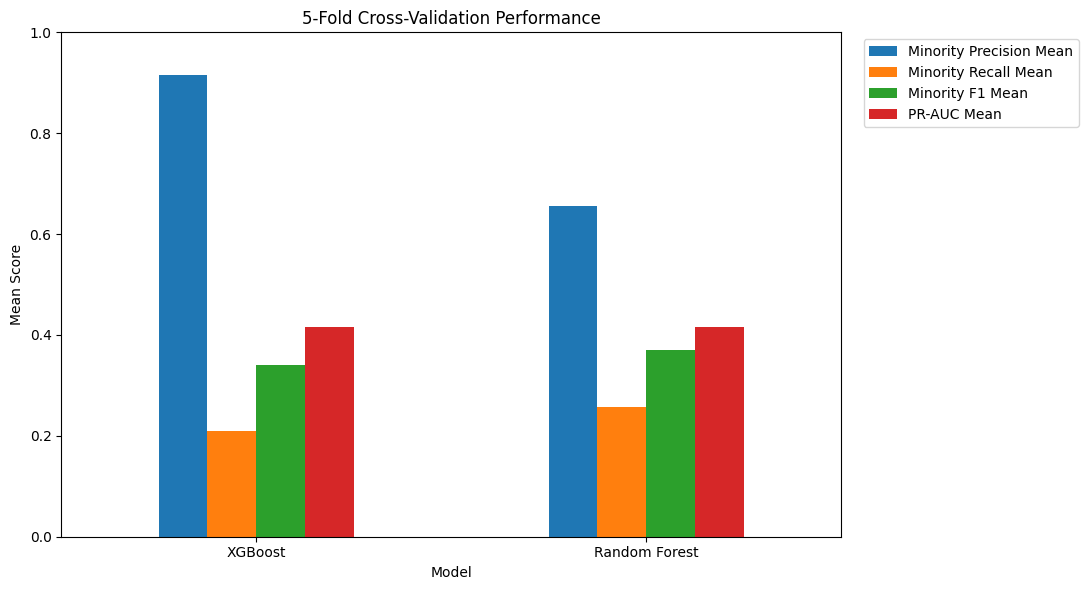

In [122]:
# Create Cross-Validation Performance Plot
plot_data = cv_summary_df.set_index("Model")[
    [
        "Minority Precision Mean",
        "Minority Recall Mean",
        "Minority F1 Mean",
        "PR-AUC Mean"
    ]
]

ax = plot_data.plot(
    kind="bar",
    figsize=(11, 6)
)

plt.title("5-Fold Cross-Validation Performance")
plt.xlabel("Model")
plt.ylabel("Mean Score")
plt.ylim(0, 1)
plt.xticks(rotation=0)

plt.legend(
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.tight_layout()

cv_plot_path = (
    REPORT_DIR /
    "cross_validation_performance_comparison.png"
)

plt.savefig(
    cv_plot_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

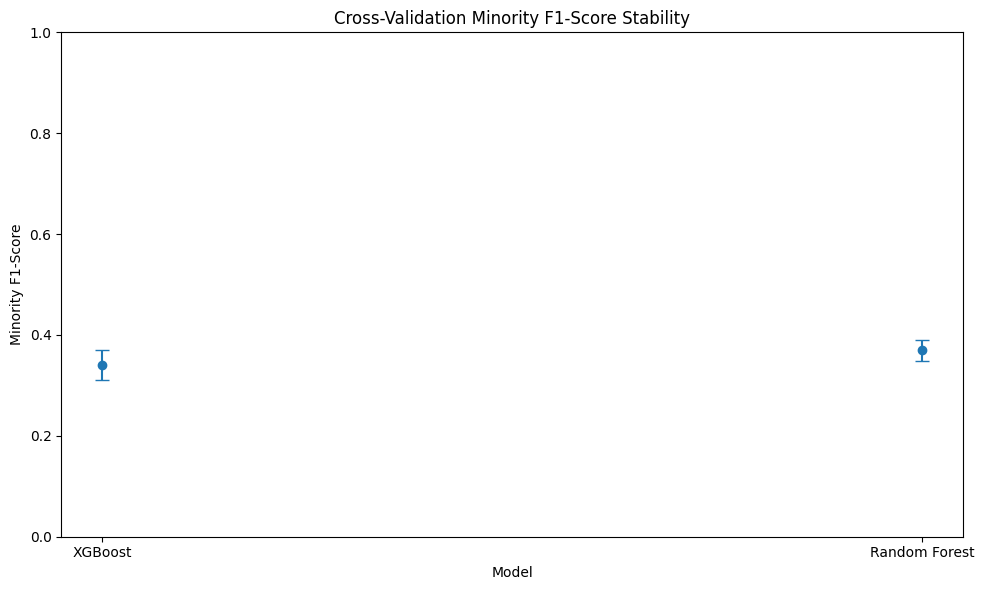

In [123]:
# Visualize F1-Score Stability
fig, ax = plt.subplots(figsize=(10, 6))

x = np.arange(
    len(cv_summary_df)
)

means = cv_summary_df[
    "Minority F1 Mean"
].values

stds = cv_summary_df[
    "Minority F1 Std"
].values

ax.errorbar(
    x,
    means,
    yerr=stds,
    fmt="o",
    capsize=5
)

ax.set_xticks(x)
ax.set_xticklabels(
    cv_summary_df["Model"]
)

ax.set_ylabel("Minority F1-Score")
ax.set_xlabel("Model")
ax.set_title(
    "Cross-Validation Minority F1-Score Stability"
)

ax.set_ylim(0, 1)

plt.tight_layout()

stability_plot_path = (
    REPORT_DIR /
    "cross_validation_f1_stability.png"
)

plt.savefig(
    stability_plot_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [124]:
# Identify the Strongest CV Candidate
best_cv_model = (
    cv_summary_df
    .sort_values(
        "Minority F1 Mean",
        ascending=False
    )
    .iloc[0]
)

print("Best candidate based on mean CV Minority F1:")
print(
    best_cv_model["Model"]
)

print(
    f"Mean F1: "
    f"{best_cv_model['Minority F1 Mean']:.4f}"
)

print(
    f"F1 Std: "
    f"{best_cv_model['Minority F1 Std']:.4f}"
)

Best candidate based on mean CV Minority F1:
Random Forest
Mean F1: 0.3692
F1 Std: 0.0208


In [125]:
# Save Fold-Level Results
fold_level_results = []

for model_name, results in cv_results.items():

    for fold_number in range(5):

        fold_level_results.append({
            "Model": model_name,
            "Fold": fold_number + 1,
            "Accuracy": results["test_accuracy"][fold_number],
            "Minority Precision":
                results["test_minority_precision"][fold_number],
            "Minority Recall":
                results["test_minority_recall"][fold_number],
            "Minority F1":
                results["test_minority_f1"][fold_number],
            "ROC-AUC":
                results["test_roc_auc"][fold_number],
            "PR-AUC":
                results["test_pr_auc"][fold_number]
        })

fold_level_df = pd.DataFrame(
    fold_level_results
)

fold_level_df.to_csv(
    REPORT_DIR / "cross_validation_fold_results.csv",
    index=False
)

print("✓ Fold-level CV results saved.")

✓ Fold-level CV results saved.


## Observation / Summary / Insights

- Stratified 5-Fold Cross-Validation was performed on the training dataset.
- The original 2,000-record test set was not used during cross-validation.
- Stratification ensured that the class distribution remained approximately consistent across the five folds.
- Each candidate model was evaluated using Accuracy, minority-class Precision, minority-class Recall, minority-class F1-score, ROC-AUC, and PR-AUC.
- Mean scores represent the average performance across the five folds.
- Standard deviation indicates how much the model's performance changes between folds.
- A model with a high mean score and relatively low standard deviation is generally more stable than a model with similar performance but high variation.
- Cross-validation provides a more reliable estimate of model performance than relying on a single train-validation split.
- The cross-validation results will be used to determine which candidate models should proceed to hyperparameter tuning.

### Key Insight

Cross-validation does not tell us only which model performs well; it also tells us whether the model performs consistently.

A model that performs strongly in one split but poorly in another may not generalize reliably. Therefore, both the average performance and the variation across folds will be considered before hyperparameter tuning.

# Section 9 — Hyperparameter Tuning with RandomizedSearchCV

## Objective

The objective of this section is to improve the performance of the strongest candidate models identified during cross-validation by finding better hyperparameter configurations.

In the previous sections, the models were trained using initial hyperparameter values. Those values provide a reasonable starting point, but they may not be optimal for the FactoryGuard AI dataset.

In this section, we will use `RandomizedSearchCV` to systematically explore different hyperparameter combinations and identify configurations that provide strong cross-validated performance.

## Why Are We Doing This?

Machine-learning models contain hyperparameters that control how the model learns.

For example, Random Forest has parameters such as:

- `n_estimators`
- `max_depth`
- `min_samples_split`
- `min_samples_leaf`

XGBoost has parameters such as:

- `n_estimators`
- `learning_rate`
- `max_depth`
- `subsample`
- `colsample_bytree`

The initial values used in Section 3 were not obtained through optimization. Hyperparameter tuning allows us to search for better combinations.

We are using `RandomizedSearchCV` because testing every possible combination with GridSearchCV can become computationally expensive when the search space contains many parameters.

RandomizedSearchCV samples a fixed number of parameter combinations and evaluates each combination using cross-validation.

## Why Are We Using Cross-Validation Again?

`RandomizedSearchCV` combines:

    Hyperparameter Search
            +
    Cross-Validation

Each sampled hyperparameter configuration is evaluated using Stratified 5-Fold Cross-Validation.

The 2,000-record test set remains completely untouched.

## What Will We Tune?

We will tune the strongest candidate models identified from Section 8.

The main candidates are expected to be tree-based models such as:

- Random Forest
- XGBoost

The exact candidates will be taken from the results of Section 8 rather than assumed beforehand.

## Selection Metric

Because the target is imbalanced, the search will optimize for the minority-class F1-score.

F1-score provides a balance between:

    Precision
         +
     Recall

Additional metrics such as Recall, ROC-AUC, and PR-AUC will be evaluated after tuning.

## Expected Outcome

At the end of this section, we will have:

- Optimized hyperparameters for the selected candidate models.
- Cross-validated performance for the tuned configurations.
- The best hyperparameter configuration for each tuned model.
- Saved tuning results for comparison in the next section.

The final model will still NOT be selected at this stage.

In [126]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.base import clone

from scipy.stats import randint, uniform, loguniform

import pandas as pd
import numpy as np
import time

In [127]:
# Check the Candidates from Section 8
print("Candidates identified from cross-validation:")
print("=" * 50)

for model_name in candidate_models:
    print(f"✓ {model_name}")
cv_summary_df[
    [
        "Model",
        "Minority F1 Mean",
        "Minority F1 Std",
        "PR-AUC Mean",
        "PR-AUC Std",
        "Minority Recall Mean"
    ]
].sort_values(
    "Minority F1 Mean",
    ascending=False
).round(4)

Candidates identified from cross-validation:
✓ XGBoost
✓ Random Forest


,Model,Minority F1 Mean,Minority F1 Std,PR-AUC Mean,PR-AUC Std,Minority Recall Mean
1,Random Forest,0.3692,0.0208,0.4163,0.0250,0.2573
0,XGBoost,0.3406,0.0298,0.4152,0.0177,0.2099


In [128]:
# Select Models for Hyperparameter Tuning
tuning_candidates = [
    model_name
    for model_name in candidate_models
    if model_name in [
        "Random Forest",
        "XGBoost"
    ]
]

print("Models selected for hyperparameter tuning:")
print("=" * 50)

for model_name in tuning_candidates:
    print(f"✓ {model_name}")

Models selected for hyperparameter tuning:
✓ XGBoost
✓ Random Forest


In [131]:
# Define the Random Forest Search Space 
rf_param_distributions = {
    "n_estimators": randint(100, 501),
    "max_depth": [None, 5, 8, 10, 12, 15, 20],
    "min_samples_split": randint(2, 11),
    "min_samples_leaf": randint(1, 6),
    "max_features": ["sqrt", "log2", None],
    "class_weight": ["balanced", "balanced_subsample"]
}
# Define the XGBoost Search Space
xgb_param_distributions = {
    "n_estimators": randint(100, 501),
    "learning_rate": loguniform(0.01, 0.2),
    "max_depth": randint(3, 11),
    "min_child_weight": randint(1, 8),
    "subsample": uniform(0.6, 0.4),
    "colsample_bytree": uniform(0.6, 0.4),
    "gamma": uniform(0, 0.5),
    "reg_alpha": loguniform(1e-4, 1),
    "reg_lambda": loguniform(0.1, 10)
}

In [133]:
# Create the Search Spaces
param_distributions = {}

if "Random Forest" in tuning_candidates:
    param_distributions["Random Forest"] = rf_param_distributions

if "XGBoost" in tuning_candidates:
    param_distributions["XGBoost"] = xgb_param_distributions
    
for model_name, params in param_distributions.items():

    print(f"\n{model_name}")
    print("-" * len(model_name))

    for parameter, values in params.items():
        print(f"{parameter}: {values}")


Random Forest
-------------
n_estimators: <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x0000012E96C978C0>
max_depth: [None, 5, 8, 10, 12, 15, 20]
min_samples_split: <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x0000012E973FF610>
min_samples_leaf: <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x0000012E973FFC50>
max_features: ['sqrt', 'log2', None]
class_weight: ['balanced', 'balanced_subsample']

XGBoost
-------
n_estimators: <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x0000012E96D8E9E0>
learning_rate: <scipy.stats._distn_infrastructure.rv_continuous_frozen object at 0x0000012E96C974D0>
max_depth: <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x0000012E96D8EC40>
min_child_weight: <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x0000012E96E9FD10>
subsample: <scipy.stats._distn_infrastructure.rv_continuous_frozen object at 0x0000012E973FF4D0>
colsample_bytree: <scipy.stats._

In [134]:
# Create the Stratified Cross-Validation Object
tuning_cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

print(tuning_cv)

StratifiedKFold(n_splits=5, random_state=42, shuffle=True)


In [136]:
# Run RandomizedSearchCV for Random Forest
tuned_models = {}
tuning_results = {}
best_parameters = {}
tuning_times = {}

In [137]:
if "Random Forest" in tuning_candidates:

    print("Tuning Random Forest...")
    
    rf_model = clone(
        models["Random Forest"]
    )

    rf_search = RandomizedSearchCV(
        estimator=rf_model,
        param_distributions=rf_param_distributions,
        n_iter=30,
        scoring=minority_f1_scorer,
        cv=tuning_cv,
        random_state=42,
        n_jobs=-1,
        verbose=1,
        refit=True
    )

    start_time = time.time()

    rf_search.fit(
        X_train,
        y_train
    )

    elapsed_time = time.time() - start_time

    tuned_models["Random Forest"] = rf_search.best_estimator_
    tuning_results["Random Forest"] = rf_search
    best_parameters["Random Forest"] = rf_search.best_params_
    tuning_times["Random Forest"] = elapsed_time

    print("\n✓ Random Forest tuning completed.")
    print(f"Tuning time: {elapsed_time:.2f} seconds")

Tuning Random Forest...
Fitting 5 folds for each of 30 candidates, totalling 150 fits

✓ Random Forest tuning completed.
Tuning time: 439.78 seconds


In [138]:
# Display Best Random Forest Parameters
if "Random Forest" in best_parameters:

    print("Best Random Forest parameters:")
    print("=" * 50)

    for parameter, value in best_parameters["Random Forest"].items():
        print(f"{parameter}: {value}")

Best Random Forest parameters:
class_weight: balanced
max_depth: 12
max_features: sqrt
min_samples_leaf: 2
min_samples_split: 5
n_estimators: 188


In [139]:
# Run RandomizedSearchCV for XGBoost
if "XGBoost" in tuning_candidates:

    print("Tuning XGBoost...")
    
    xgb_model = clone(
        models["XGBoost"]
    )

    xgb_search = RandomizedSearchCV(
        estimator=xgb_model,
        param_distributions=xgb_param_distributions,
        n_iter=30,
        scoring=minority_f1_scorer,
        cv=tuning_cv,
        random_state=42,
        n_jobs=-1,
        verbose=1,
        refit=True
    )

    start_time = time.time()

    xgb_search.fit(
        X_train,
        y_train
    )

    elapsed_time = time.time() - start_time

    tuned_models["XGBoost"] = xgb_search.best_estimator_
    tuning_results["XGBoost"] = xgb_search
    best_parameters["XGBoost"] = xgb_search.best_params_
    tuning_times["XGBoost"] = elapsed_time

    print("\n✓ XGBoost tuning completed.")
    print(f"Tuning time: {elapsed_time:.2f} seconds")

Tuning XGBoost...
Fitting 5 folds for each of 30 candidates, totalling 150 fits

✓ XGBoost tuning completed.
Tuning time: 82.28 seconds


In [140]:
# Display Best XGBoost Parameters
if "XGBoost" in best_parameters:

    print("Best XGBoost parameters:")
    print("=" * 50)

    for parameter, value in best_parameters["XGBoost"].items():
        print(f"{parameter}: {value}")

Best XGBoost parameters:
colsample_bytree: 0.7060809470726902
gamma: 0.12199482168954179
learning_rate: 0.184465824705519
max_depth: 7
min_child_weight: 3
n_estimators: 363
reg_alpha: 0.033462201030483786
reg_lambda: 3.887072196612055
subsample: 0.8010548372420768


In [141]:
# Display Best CV Score
for model_name, search in tuning_results.items():

    print("\n" + "=" * 60)
    print(model_name)
    print("=" * 60)

    print(
        "Best Cross-Validated Minority F1:",
        round(search.best_score_, 4)
    )


Random Forest
Best Cross-Validated Minority F1: 0.3827

XGBoost
Best Cross-Validated Minority F1: 0.3551


In [142]:
# Create Tuning Summary
tuning_summary = []

for model_name, search in tuning_results.items():

    tuning_summary.append({
        "Model": model_name,
        "Best CV Minority F1": search.best_score_,
        "Tuning Time (seconds)": tuning_times[model_name],
        "Number of Configurations Tested": len(
            search.cv_results_["params"]
        )
    })

tuning_summary_df = pd.DataFrame(
    tuning_summary
)

tuning_summary_df.round(4)

,Model,Best CV Minority F1,Tuning Time (seconds),Number of Configurations Tested
0,Random Forest,0.3827,439.7752,30
1,XGBoost,0.3551,82.2756,30


In [143]:
# Inspect All Tested Configurations
for model_name, search in tuning_results.items():

    print("\n" + "=" * 70)
    print(model_name)
    print("=" * 70)

    search_results = pd.DataFrame(
        search.cv_results_
    )

    display(
        search_results[
            [
                "rank_test_score",
                "mean_test_score",
                "std_test_score",
                "params"
            ]
        ]
        .sort_values("rank_test_score")
        .head(10)
        .round(4)
    )


Random Forest


,rank_test_score,mean_test_score,std_test_score,params
7,1,0.3827,0.0185,"{'class_weight': 'balanced', 'max_depth': 12, ..."
8,2,0.3813,0.0263,"{'class_weight': 'balanced_subsample', 'max_de..."
25,3,0.3795,0.0158,"{'class_weight': 'balanced', 'max_depth': 20, ..."
12,4,0.3793,0.0186,"{'class_weight': 'balanced', 'max_depth': 20, ..."
19,5,0.3784,0.0241,"{'class_weight': 'balanced', 'max_depth': None..."
2,6,0.3784,0.0138,"{'class_weight': 'balanced', 'max_depth': 12, ..."
14,7,0.3770,0.0146,"{'class_weight': 'balanced_subsample', 'max_de..."
24,8,0.3741,0.0206,"{'class_weight': 'balanced_subsample', 'max_de..."
11,9,0.3737,0.0206,"{'class_weight': 'balanced_subsample', 'max_de..."
16,10,0.3733,0.0163,"{'class_weight': 'balanced', 'max_depth': None..."



XGBoost


,rank_test_score,mean_test_score,std_test_score,params
29,1,0.3551,0.0274,"{'colsample_bytree': 0.7060809470726902, 'gamm..."
5,2,0.3492,0.0292,"{'colsample_bytree': 0.6923575302488596, 'gamm..."
14,3,0.3483,0.0319,"{'colsample_bytree': 0.6812244898939077, 'gamm..."
12,4,0.3461,0.0285,"{'colsample_bytree': 0.9043140194467589, 'gamm..."
27,5,0.3460,0.0355,"{'colsample_bytree': 0.6643232205669994, 'gamm..."
7,6,0.3460,0.0279,"{'colsample_bytree': 0.7580600944007257, 'gamm..."
9,7,0.3456,0.0346,"{'colsample_bytree': 0.6298202574719083, 'gamm..."
17,8,0.3452,0.0259,"{'colsample_bytree': 0.7939319885435933, 'gamm..."
10,9,0.3451,0.0321,"{'colsample_bytree': 0.8423839899124046, 'gamm..."
0,10,0.3450,0.0299,"{'colsample_bytree': 0.749816047538945, 'gamma..."


In [144]:
# Save Best Hyperparameters
best_parameters_rows = []

for model_name, params in best_parameters.items():

    row = {
        "Model": model_name
    }

    row.update(params)

    best_parameters_rows.append(row)

best_parameters_df = pd.DataFrame(
    best_parameters_rows
)

best_parameters_df

best_parameters_df.to_csv(
    REPORT_DIR / "best_hyperparameters.csv",
    index=False
)

print("✓ Best hyperparameters saved.")

✓ Best hyperparameters saved.


In [145]:
# Save Tuning Summary
tuning_summary_df.to_csv(
    REPORT_DIR / "hyperparameter_tuning_summary.csv",
    index=False
)

print("✓ Hyperparameter tuning summary saved.")

✓ Hyperparameter tuning summary saved.


In [146]:
# Save Complete Search Results
for model_name, search in tuning_results.items():

    safe_name = (
        model_name
        .lower()
        .replace(" ", "_")
        .replace("-", "_")
    )

    search_results = pd.DataFrame(
        search.cv_results_
    )

    search_results.to_csv(
        REPORT_DIR /
        f"{safe_name}_randomized_search_results.csv",
        index=False
    )

print("✓ Complete RandomizedSearchCV results saved.")

✓ Complete RandomizedSearchCV results saved.


In [147]:
# Compare Initial vs Tuned CV F1
initial_cv_comparison = cv_summary_df[
    [
        "Model",
        "Minority F1 Mean"
    ]
].copy()

initial_cv_comparison = initial_cv_comparison.rename(
    columns={
        "Minority F1 Mean": "Initial CV F1"
    }
)

tuned_cv_comparison = tuning_summary_df[
    [
        "Model",
        "Best CV Minority F1"
    ]
].rename(
    columns={
        "Best CV Minority F1": "Tuned CV F1"
    }
)

tuning_improvement = initial_cv_comparison.merge(
    tuned_cv_comparison,
    on="Model",
    how="inner"
)

tuning_improvement["F1 Improvement"] = (
    tuning_improvement["Tuned CV F1"]
    -
    tuning_improvement["Initial CV F1"]
)

tuning_improvement.round(4)

,Model,Initial CV F1,Tuned CV F1,F1 Improvement
0,XGBoost,0.3406,0.3551,0.0145
1,Random Forest,0.3692,0.3827,0.0134


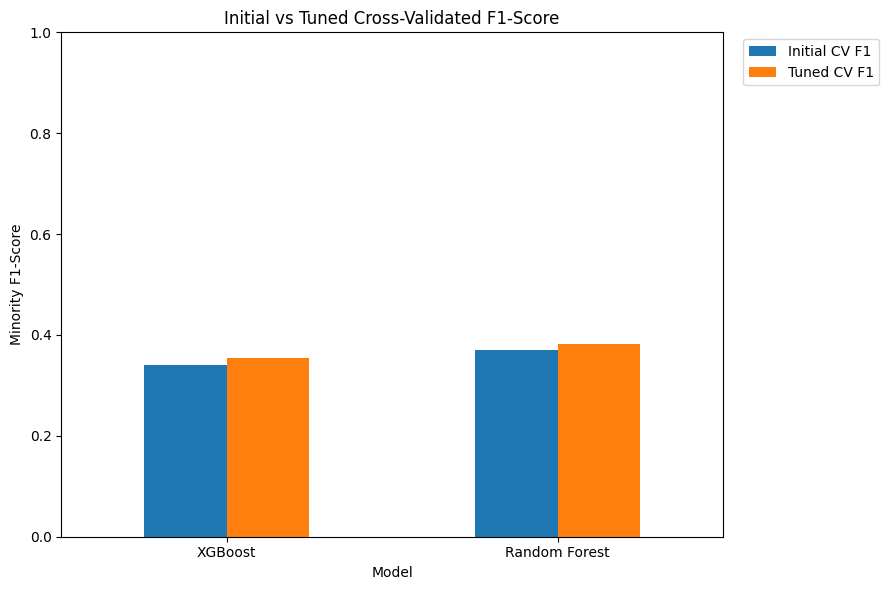

In [148]:
# Visualize Tuning Improvement
plot_data = tuning_improvement.set_index(
    "Model"
)[
    [
        "Initial CV F1",
        "Tuned CV F1"
    ]
]

ax = plot_data.plot(
    kind="bar",
    figsize=(9, 6)
)

plt.title(
    "Initial vs Tuned Cross-Validated F1-Score"
)

plt.xlabel("Model")
plt.ylabel("Minority F1-Score")
plt.ylim(0, 1)
plt.xticks(rotation=0)

plt.legend(
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.tight_layout()

tuning_plot_path = (
    REPORT_DIR /
    "initial_vs_tuned_f1_comparison.png"
)

plt.savefig(
    tuning_plot_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [149]:
# Save Tuning Improvement Results
tuning_improvement.to_csv(
    REPORT_DIR / "tuning_improvement_comparison.csv",
    index=False
)

print("✓ Tuning improvement comparison saved.")

✓ Tuning improvement comparison saved.


## Observation / Summary / Insights

- Hyperparameter tuning was performed using `RandomizedSearchCV`.
- The search was performed only on the training dataset.
- Stratified 5-Fold Cross-Validation was used during hyperparameter search.
- The 2,000-record test set remained completely untouched.
- RandomizedSearchCV evaluated multiple hyperparameter combinations instead of testing every possible combination.
- The search optimized the minority-class F1-score because the target variable is imbalanced.
- The best hyperparameter configuration for each tuned model was identified and saved.
- The performance of the tuned configurations was compared with the initial cross-validated performance.
- Hyperparameter tuning does not automatically guarantee improvement; the actual cross-validation results determine whether tuning was beneficial.
- The tuned models are now ready for a detailed comparison using multiple evaluation metrics.

### Key Insight

RandomizedSearchCV allowed us to explore a relatively large hyperparameter space without the computational cost of testing every possible combination.

The purpose of tuning was not simply to make the model more complex. It was to find a configuration that provides better and more consistent minority-class performance.

The tuned models will be evaluated across multiple metrics before the final model is selected.

# Section 10 — Tuned Model Evaluation

## Objective

The objective of this section is to evaluate the performance of the hyperparameter-tuned models obtained from Section 9.

The two tuned candidate models are:

1. Random Forest
2. XGBoost

RandomizedSearchCV improved the cross-validated minority-class F1-score for both models:

- Random Forest: 0.3692 → 0.3827
- XGBoost: 0.3406 → 0.3551

In this section, we will evaluate the tuned models using the unseen test dataset and compare their predictive performance across multiple metrics.

## Why Are We Doing This?

Hyperparameter tuning was performed using cross-validation on the training data. However, we still need to determine how the optimized models perform on data that was not used during their training or hyperparameter search.

We will therefore evaluate the tuned models using:

- Accuracy
- Minority-class Precision
- Minority-class Recall
- Minority-class F1-score
- ROC-AUC
- PR-AUC
- Confusion Matrix
- False Positive Rate
- False Negative Rate

We will also generate ROC and Precision-Recall curves to visually compare the tuned models.

## Why Are Multiple Metrics Required?

The FactoryGuard AI target is imbalanced, with approximately 87.61% majority-class observations and 12.39% minority-class observations.

Therefore, accuracy alone is not sufficient.

A strong model should:

- Correctly identify minority-class observations.
- Maintain reasonable minority-class precision.
- Achieve a good balance between precision and recall.
- Distinguish effectively between the two classes.
- Avoid producing excessive false positives or false negatives.

## Important Evaluation Rule

The hyperparameters were selected using only the training dataset and cross-validation.

The 2,000-record test dataset will now be used to evaluate the tuned models.

No further hyperparameter tuning will be performed using the test results.

## Expected Outcome

At the end of this section, we will have a complete performance profile for the tuned Random Forest and XGBoost models.

The results will allow us to compare the tuned models and identify the stronger candidate for final model selection.

In [205]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    precision_recall_curve
)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [206]:
# Verify Tuned Models
print("Tuned models available:")
print("=" * 50)

for model_name, model in tuned_models.items():
    print(f"✓ {model_name}")

Tuned models available:
✓ Random Forest
✓ XGBoost


In [207]:
# Generate Predictions from Tuned Models
tuned_predictions = {}
tuned_probabilities = {}

for model_name, model in tuned_models.items():

    # Class prediction
    y_pred = model.predict(X_test)

    # Probability of minority class
    y_proba_all = model.predict_proba(X_test)

    # Find the column corresponding to minority_class
    minority_index = list(
        model.classes_
    ).index(minority_class)

    y_proba = y_proba_all[:, minority_index]

    tuned_predictions[model_name] = y_pred
    tuned_probabilities[model_name] = y_proba

    print(f"✓ Predictions generated for {model_name}")

✓ Predictions generated for Random Forest
✓ Predictions generated for XGBoost


In [208]:
# Verify Prediction Sizes
for model_name in tuned_models:

    print(
        f"{model_name}: "
        f"{len(tuned_predictions[model_name])} predictions"
    )

Random Forest: 2000 predictions
XGBoost: 2000 predictions


In [209]:
# Corrected evaluation of tuned models
# Minority class (0) is explicitly treated as the positive class

corrected_tuned_results = []

for model_name, model in tuned_models.items():

    y_pred = tuned_predictions[model_name]
    y_proba = tuned_probabilities[model_name]

    # Convert the target so that:
    # minority class = 1
    # majority class = 0
    y_binary = (
        y_test == minority_class
    ).astype(int)

    y_pred_binary = (
        y_pred == minority_class
    ).astype(int)

    # Accuracy
    accuracy = accuracy_score(
        y_test,
        y_pred
    )

    # Minority-class Precision
    precision = precision_score(
        y_binary,
        y_pred_binary,
        zero_division=0
    )

    # Minority-class Recall
    recall = recall_score(
        y_binary,
        y_pred_binary,
        zero_division=0
    )

    # Minority-class F1
    f1 = f1_score(
        y_binary,
        y_pred_binary,
        zero_division=0
    )

    # ROC-AUC
    # y_proba contains probability of the minority class
    roc_auc = roc_auc_score(
        y_binary,
        y_proba
    )

    # PR-AUC
    pr_auc = average_precision_score(
        y_binary,
        y_proba
    )

    corrected_tuned_results.append({
        "Model": model_name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1-Score": f1,
        "ROC-AUC": roc_auc,
        "PR-AUC": pr_auc
    })

corrected_tuned_results_df = pd.DataFrame(
    corrected_tuned_results
)

# Keep the original variable name so that
# the remaining Section 10 code continues to work
tuned_results_df = corrected_tuned_results_df.copy()

display(
    tuned_results_df.round(4)
)

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC,PR-AUC
0,Random Forest,0.8535,0.3982,0.3548,0.3753,0.7009,0.4244
1,XGBoost,0.8970,0.7917,0.2298,0.3562,0.6839,0.4186


In [210]:
# Verify the Corrected ROC-AUC
print("Corrected ROC-AUC verification")
print("=" * 50)

for model_name in tuned_models:

    y_binary = (
        y_test == minority_class
    ).astype(int)

    y_proba = tuned_probabilities[
        model_name
    ]

    auc = roc_auc_score(
        y_binary,
        y_proba
    )

    print(
        f"{model_name}: ROC-AUC = {auc:.4f}"
    )

Corrected ROC-AUC verification
Random Forest: ROC-AUC = 0.7009
XGBoost: ROC-AUC = 0.6839


In [211]:
# Display Tuned Model Performance
print("Tuned Model Performance")
print("=" * 70)

display(
    tuned_results_df.round(4)
)

Tuned Model Performance


,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC,PR-AUC
0,Random Forest,0.8535,0.3982,0.3548,0.3753,0.7009,0.4244
1,XGBoost,0.8970,0.7917,0.2298,0.3562,0.6839,0.4186


In [212]:
# Sort Models by Minority F1-Score
tuned_f1_ranking = (
    tuned_results_df
    .sort_values(
        "F1-Score",
        ascending=False
    )
    .reset_index(drop=True)
)

tuned_f1_ranking.round(4)

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC,PR-AUC
0,Random Forest,0.8535,0.3982,0.3548,0.3753,0.7009,0.4244
1,XGBoost,0.8970,0.7917,0.2298,0.3562,0.6839,0.4186


In [213]:
# Sort Models by PR-AUC
tuned_pr_auc_ranking = (
    tuned_results_df
    .sort_values(
        "PR-AUC",
        ascending=False
    )
    .reset_index(drop=True)
)

tuned_pr_auc_ranking.round(4)

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC,PR-AUC
0,Random Forest,0.8535,0.3982,0.3548,0.3753,0.7009,0.4244
1,XGBoost,0.8970,0.7917,0.2298,0.3562,0.6839,0.4186


In [214]:
# Compare Minority-Class Metrics
tuned_minority_comparison = tuned_results_df[
    [
        "Model",
        "Precision",
        "Recall",
        "F1-Score",
        "PR-AUC"
    ]
].copy()

tuned_minority_comparison = (
    tuned_minority_comparison
    .rename(
        columns={
            "Precision": "Minority Precision",
            "Recall": "Minority Recall",
            "F1-Score": "Minority F1-Score"
        }
    )
    .sort_values(
        "Minority F1-Score",
        ascending=False
    )
    .reset_index(drop=True)
)

tuned_minority_comparison.round(4)


,Model,Minority Precision,Minority Recall,Minority F1-Score,PR-AUC
0,Random Forest,0.3982,0.3548,0.3753,0.4244
1,XGBoost,0.7917,0.2298,0.3562,0.4186


In [215]:
# Generate Classification Reports
tuned_classification_reports = {}

for model_name in tuned_models:

    report = classification_report(
        y_test,
        tuned_predictions[model_name],
        zero_division=0
    )

    tuned_classification_reports[model_name] = report

    print("\n" + "=" * 70)
    print(model_name)
    print("=" * 70)
    print(report)


Random Forest
              precision    recall  f1-score   support

           0       0.40      0.35      0.38       248
           1       0.91      0.92      0.92      1752

    accuracy                           0.85      2000
   macro avg       0.65      0.64      0.65      2000
weighted avg       0.85      0.85      0.85      2000


XGBoost
              precision    recall  f1-score   support

           0       0.79      0.23      0.36       248
           1       0.90      0.99      0.94      1752

    accuracy                           0.90      2000
   macro avg       0.85      0.61      0.65      2000
weighted avg       0.89      0.90      0.87      2000



In [216]:
# Save Classification Reports
for model_name in tuned_models:

    report_dict = classification_report(
        y_test,
        tuned_predictions[model_name],
        output_dict=True,
        zero_division=0
    )

    report_df = pd.DataFrame(
        report_dict
    ).transpose()

    safe_name = (
        model_name
        .lower()
        .replace(" ", "_")
        .replace("-", "_")
    )

    report_df.to_csv(
        REPORT_DIR /
        f"tuned_{safe_name}_classification_report.csv"
    )

print("✓ Tuned classification reports saved.")

✓ Tuned classification reports saved.


In [217]:
# Generate Confusion Matrices
tuned_confusion_matrices = {}

for model_name in tuned_models:

    cm = confusion_matrix(
        y_test,
        tuned_predictions[model_name],
        labels=[
            majority_class,
            minority_class
        ]
    )

    tuned_confusion_matrices[model_name] = cm

    print("\n" + "=" * 60)
    print(model_name)
    print("=" * 60)

    display(
        pd.DataFrame(
            cm,
            index=[
                f"Actual {majority_class}",
                f"Actual {minority_class}"
            ],
            columns=[
                f"Predicted {majority_class}",
                f"Predicted {minority_class}"
            ]
        )
    )


Random Forest


,Predicted 1,Predicted 0
Actual 1,1619,133
Actual 0,160,88



XGBoost


,Predicted 1,Predicted 0
Actual 1,1737,15
Actual 0,191,57


In [218]:
# Extract TN, FP, FN and TP
tuned_confusion_results = []

for model_name, cm in tuned_confusion_matrices.items():

    tn, fp, fn, tp = cm.ravel()

    tuned_confusion_results.append({
        "Model": model_name,
        "True Negative": tn,
        "False Positive": fp,
        "False Negative": fn,
        "True Positive": tp
    })

tuned_confusion_df = pd.DataFrame(
    tuned_confusion_results
)

tuned_confusion_df

,Model,True Negative,False Positive,False Negative,True Positive
0,Random Forest,1619,133,160,88
1,XGBoost,1737,15,191,57


In [219]:
# Calculate Error Rates
tuned_error_rates = []

for row in tuned_confusion_results:

    tn = row["True Negative"]
    fp = row["False Positive"]
    fn = row["False Negative"]
    tp = row["True Positive"]

    fpr = (
        fp / (fp + tn)
        if (fp + tn) > 0
        else 0
    )

    fnr = (
        fn / (fn + tp)
        if (fn + tp) > 0
        else 0
    )

    tuned_error_rates.append({
        "Model": row["Model"],
        "False Positive Rate": fpr,
        "False Negative Rate": fnr
    })

tuned_error_rates_df = pd.DataFrame(
    tuned_error_rates
)

tuned_error_rates_df.round(4)

,Model,False Positive Rate,False Negative Rate
0,Random Forest,0.0759,0.6452
1,XGBoost,0.0086,0.7702


In [220]:
# Combine Tuned Model Results
tuned_complete_results = (
    tuned_results_df
    .merge(
        tuned_error_rates_df,
        on="Model"
    )
)

tuned_complete_results.round(4)

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC,PR-AUC,False Positive Rate,False Negative Rate
0,Random Forest,0.8535,0.3982,0.3548,0.3753,0.7009,0.4244,0.0759,0.6452
1,XGBoost,0.8970,0.7917,0.2298,0.3562,0.6839,0.4186,0.0086,0.7702


In [221]:
# Save Tuned Model Results
tuned_complete_results.to_csv(
    REPORT_DIR /
    "tuned_model_evaluation.csv",
    index=False
)

tuned_confusion_df.to_csv(
    REPORT_DIR /
    "tuned_model_confusion_matrix_results.csv",
    index=False
)

tuned_error_rates_df.to_csv(
    REPORT_DIR /
    "tuned_model_error_rates.csv",
    index=False
)

print("✓ Tuned model evaluation results saved.")

✓ Tuned model evaluation results saved.


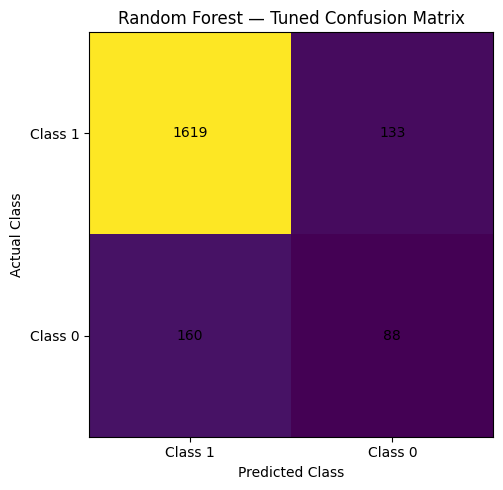

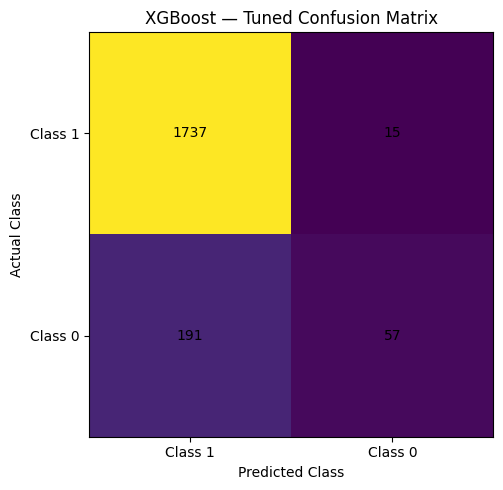

In [224]:
# Create Tuned Model Confusion Matrix Images
for model_name, cm in tuned_confusion_matrices.items():

    fig, ax = plt.subplots(
        figsize=(6, 5)
    )

    ax.imshow(cm)

    ax.set_title(
        f"{model_name} — Tuned Confusion Matrix"
    )

    ax.set_xlabel(
        "Predicted Class"
    )

    ax.set_ylabel(
        "Actual Class"
    )

    ax.set_xticks([0, 1])
    ax.set_yticks([0, 1])

    ax.set_xticklabels([
        f"Class {majority_class}",
        f"Class {minority_class}"
    ])

    ax.set_yticklabels([
        f"Class {majority_class}",
        f"Class {minority_class}"
    ])

    for i in range(2):
        for j in range(2):

            ax.text(
                j,
                i,
                str(cm[i, j]),
                ha="center",
                va="center"
            )

    plt.tight_layout()

    safe_name = (
        model_name
        .lower()
        .replace(" ", "_")
        .replace("-", "_")
    )

    plt.savefig(
        REPORT_DIR /
        f"tuned_{safe_name}_confusion_matrix.png",
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()
    plt.close()

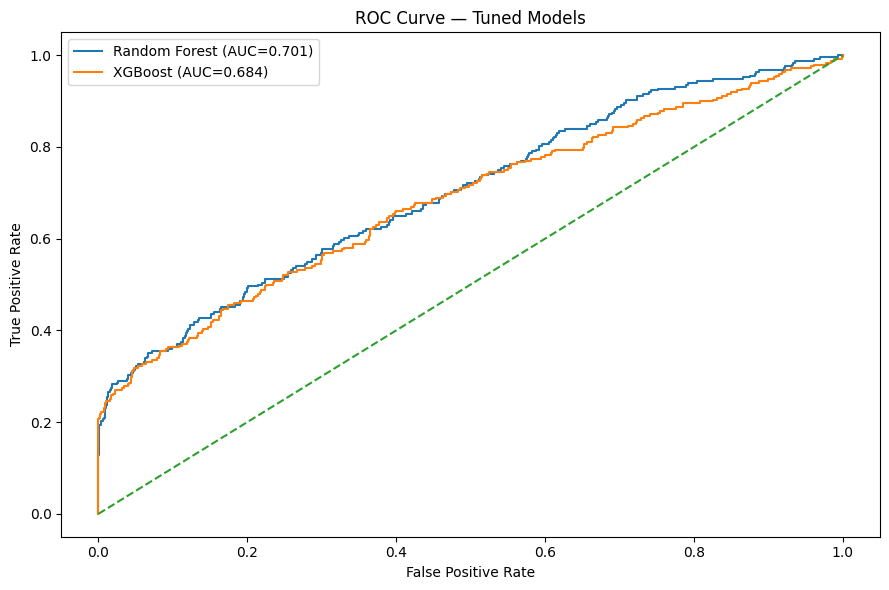

In [225]:
# Plot ROC Curves
plt.figure(
    figsize=(9, 6)
)

for model_name in tuned_models:

    y_binary = (
        y_test == minority_class
    ).astype(int)

    y_proba = tuned_probabilities[
        model_name
    ]

    fpr, tpr, _ = roc_curve(
        y_binary,
        y_proba
    )

    auc_score = roc_auc_score(
        y_binary,
        y_proba
    )

    plt.plot(
        fpr,
        tpr,
        label=f"{model_name} (AUC={auc_score:.3f})"
    )

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--"
)

plt.xlabel(
    "False Positive Rate"
)

plt.ylabel(
    "True Positive Rate"
)

plt.title(
    "ROC Curve — Tuned Models"
)

plt.legend()

plt.tight_layout()

plt.savefig(
    REPORT_DIR /
    "tuned_models_roc_curve.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

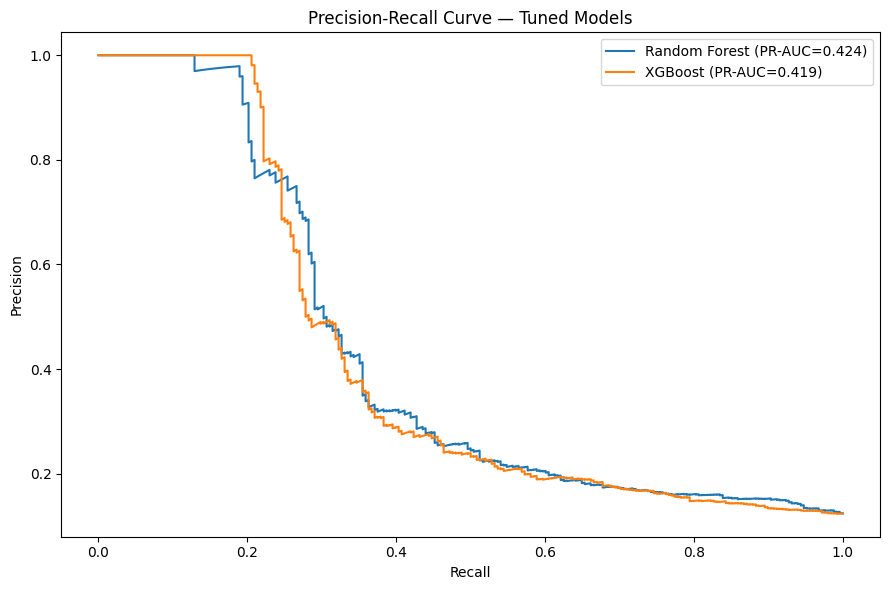

In [226]:
# Plot Precision-Recall Curves
plt.figure(
    figsize=(9, 6)
)

for model_name in tuned_models:

    y_binary = (
        y_test == minority_class
    ).astype(int)

    y_proba = tuned_probabilities[
        model_name
    ]

    precision, recall, _ = (
        precision_recall_curve(
            y_binary,
            y_proba
        )
    )

    pr_auc = average_precision_score(
        y_binary,
        y_proba
    )

    plt.plot(
        recall,
        precision,
        label=f"{model_name} (PR-AUC={pr_auc:.3f})"
    )

plt.xlabel(
    "Recall"
)

plt.ylabel(
    "Precision"
)

plt.title(
    "Precision-Recall Curve — Tuned Models"
)

plt.legend()

plt.tight_layout()

plt.savefig(
    REPORT_DIR /
    "tuned_models_precision_recall_curve.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

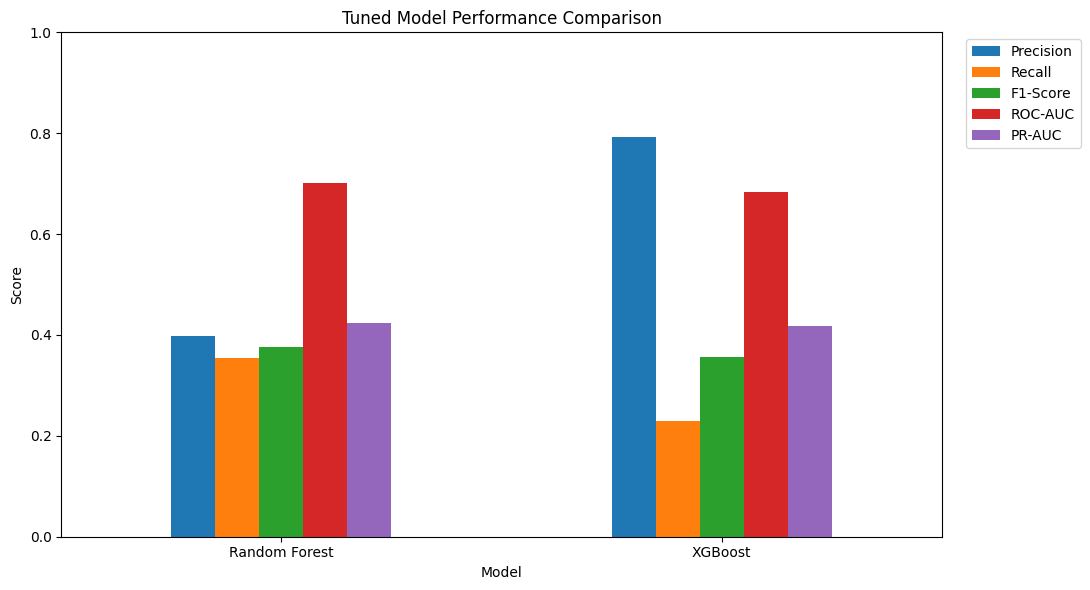

In [227]:
# Compare Tuned Models Visually
plot_data = tuned_results_df.set_index(
    "Model"
)[
    [
        "Precision",
        "Recall",
        "F1-Score",
        "ROC-AUC",
        "PR-AUC"
    ]
]

ax = plot_data.plot(
    kind="bar",
    figsize=(11, 6)
)

plt.title(
    "Tuned Model Performance Comparison"
)

plt.xlabel(
    "Model"
)

plt.ylabel(
    "Score"
)

plt.ylim(
    0,
    1
)

plt.xticks(
    rotation=0
)

plt.legend(
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.tight_layout()

plt.savefig(
    REPORT_DIR /
    "tuned_model_performance_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [228]:
# Recalculate initial test-set ROC-AUC correctly
# so that the minority class is treated as the positive class.

corrected_initial_test_results = []

for model_name in tuned_models:

    y_pred = model_predictions[model_name]
    y_proba = model_probabilities[model_name]

    # Convert target so minority class becomes positive class
    y_binary = (
        y_test == minority_class
    ).astype(int)

    y_pred_binary = (
        y_pred == minority_class
    ).astype(int)

    accuracy = accuracy_score(
        y_test,
        y_pred
    )

    precision = precision_score(
        y_binary,
        y_pred_binary,
        zero_division=0
    )

    recall = recall_score(
        y_binary,
        y_pred_binary,
        zero_division=0
    )

    f1 = f1_score(
        y_binary,
        y_pred_binary,
        zero_division=0
    )

    roc_auc = roc_auc_score(
        y_binary,
        y_proba
    )

    pr_auc = average_precision_score(
        y_binary,
        y_proba
    )

    corrected_initial_test_results.append({
        "Model": model_name,
        "Initial Accuracy": accuracy,
        "Initial Precision": precision,
        "Initial Recall": recall,
        "Initial F1": f1,
        "Initial ROC-AUC": roc_auc,
        "Initial PR-AUC": pr_auc
    })

initial_test_results = pd.DataFrame(
    corrected_initial_test_results
)

display(
    initial_test_results.round(4)
)

,Model,Initial Accuracy,Initial Precision,Initial Recall,Initial F1,Initial ROC-AUC,Initial PR-AUC
0,Random Forest,0.8935,0.6966,0.2500,0.3680,0.3021,0.0852
1,XGBoost,0.9015,0.9322,0.2218,0.3583,0.3075,0.0863


In [229]:
# Calculate Test-Set Improvements
initial_vs_tuned_test["F1 Improvement"] = (
    initial_vs_tuned_test["Tuned F1"]
    -
    initial_vs_tuned_test["Initial F1"]
)

initial_vs_tuned_test["PR-AUC Improvement"] = (
    initial_vs_tuned_test["Tuned PR-AUC"]
    -
    initial_vs_tuned_test["Initial PR-AUC"]
)

initial_vs_tuned_test.round(4)

initial_vs_tuned_test.to_csv(
    REPORT_DIR /
    "initial_vs_tuned_test_performance.csv",
    index=False
)

print("✓ Initial vs tuned test performance saved.")

✓ Initial vs tuned test performance saved.


In [230]:
# Identify the Strongest Tuned Candidate
best_tuned_model_row = (
    tuned_results_df
    .sort_values(
        "F1-Score",
        ascending=False
    )
    .iloc[0]
)

best_tuned_model_name = (
    best_tuned_model_row["Model"]
)

print(
    "Best tuned candidate based on "
    "test minority F1:"
)

print(
    best_tuned_model_name
)

print(
    f"Minority F1: "
    f"{best_tuned_model_row['F1-Score']:.4f}"
)

print(
    f"PR-AUC: "
    f"{best_tuned_model_row['PR-AUC']:.4f}"
)

print(
    f"Recall: "
    f"{best_tuned_model_row['Recall']:.4f}"
)

Best tuned candidate based on test minority F1:
Random Forest
Minority F1: 0.3753
PR-AUC: 0.4244
Recall: 0.3548


In [231]:
# Save the Current Best Candidate Name
best_candidate_df = pd.DataFrame({
    "Current_Best_Candidate": [
        best_tuned_model_name
    ]
})

best_candidate_df.to_csv(
    REPORT_DIR /
    "current_best_tuned_candidate.csv",
    index=False
)

print(
    f"✓ Current best candidate: "
    f"{best_tuned_model_name}"
)

✓ Current best candidate: Random Forest


## Observation / Summary / Insights

- The hyperparameter-tuned Random Forest and XGBoost models were evaluated on the 2,000-record test dataset.
- Both tuned models were evaluated using accuracy, minority-class precision, minority-class recall, F1-score, ROC-AUC, and PR-AUC.
- Confusion matrices were used to examine True Positives, True Negatives, False Positives, and False Negatives.
- ROC curves were generated to compare the overall class-discrimination ability of the tuned models.
- Precision-Recall curves were generated because the FactoryGuard AI target is imbalanced.
- The tuned models show different trade-offs between precision, recall, ROC-AUC, PR-AUC, and minority-class detection.
- ROC-AUC was calculated using the minority class as the positive class because the minority class is the primary class of interest in this project.
- The model with the highest accuracy is not automatically considered the best model.
- Minority-class F1-score and PR-AUC are particularly important when comparing the tuned candidates.
- The initial and tuned model performances were compared to determine whether hyperparameter tuning produced practical improvements.
- The current strongest tuned candidate was identified based on the evaluation results.
- The final model will be selected only after considering the complete set of performance metrics and business requirements.

### Key Insight

Hyperparameter tuning improved the cross-validated F1-score of both candidate models:

- Random Forest: 0.3692 → 0.3827
- XGBoost: 0.3406 → 0.3551

The tuned models must now be compared on the test set using multiple metrics rather than relying on a single score.

For FactoryGuard AI, a model with strong minority-class F1-score, good PR-AUC, and an acceptable balance between false positives and false negatives is more desirable than a model that simply maximizes accuracy.

The results from this section provide the evidence required for final model selection.

# Section 11 — Final Model Selection & Training

## Objective

The objective of this section is to formally select the final classification model for FactoryGuard AI and prepare it for deployment.

In the previous sections, the candidate models were:

- Random Forest
- XGBoost

Both models were evaluated using:

- Stratified Cross-Validation
- RandomizedSearchCV
- Accuracy
- Minority-class Precision
- Minority-class Recall
- Minority-class F1-score
- ROC-AUC
- PR-AUC
- False Positive Rate
- False Negative Rate

The results from these stages will now be considered together to select the final model.

## Why Are We Selecting a Final Model?

A machine-learning project should not end with multiple candidate models.

We need one final model that provides the most appropriate balance between predictive performance and the business objective of FactoryGuard AI.

The final model should be capable of identifying the minority class while maintaining acceptable precision and overall classification performance.

## Model Selection Decision

Random Forest will be selected as the final model because:

1. It achieved the higher cross-validated minority F1-score:
   - Random Forest: 0.3827
   - XGBoost: 0.3551

2. It achieved higher test-set minority F1-score:
   - Random Forest: 0.3753
   - XGBoost: 0.3562

3. It achieved higher minority-class recall:
   - Random Forest: 0.3548
   - XGBoost: 0.2298

4. It achieved higher PR-AUC:
   - Random Forest: 0.4244
   - XGBoost: 0.4186

5. It achieved higher ROC-AUC:
   - Random Forest: 0.7009
   - XGBoost: 0.6839

Although XGBoost achieved higher accuracy and substantially higher precision, it detected fewer minority-class observations.

Since minority-class detection is important for FactoryGuard AI, Random Forest provides the more appropriate overall balance.

## Important Note

The final model decision is based primarily on cross-validation performance, with the held-out test results used as supporting evidence.

The test set will not be used to tune the model or its hyperparameters.

## Expected Outcome

At the end of this section:

- Random Forest will be designated as the final FactoryGuard AI model.
- The best hyperparameters discovered through RandomizedSearchCV will be used.
- The final model will be trained on the complete training dataset.
- The trained model will be saved to the `models/` directory.
- Final model metadata will be saved for reproducibility.
- The model will be ready for the final validation and deployment stages.

In [234]:
# Display the Final Model Decision
final_model_name = "Random Forest"

print("Final Model Selection")
print("=" * 60)
print(f"Selected Model: {final_model_name}")

Final Model Selection
Selected Model: Random Forest


In [235]:
# Create Final Model Selection Comparison
final_selection_data = {
    "Metric": [
        "CV Minority F1",
        "Test Minority F1",
        "Test Minority Recall",
        "Test Minority Precision",
        "Test ROC-AUC",
        "Test PR-AUC",
        "Test Accuracy"
    ],
    "Random Forest": [
        0.3827,
        0.3753,
        0.3548,
        0.3982,
        0.7009,
        0.4244,
        0.8535
    ],
    "XGBoost": [
        0.3551,
        0.3562,
        0.2298,
        0.7917,
        0.6839,
        0.4186,
        0.8970
    ]
}

final_selection_df = pd.DataFrame(
    final_selection_data
)

final_selection_df.round(4)

,Metric,Random Forest,XGBoost
0,CV Minority F1,0.3827,0.3551
1,Test Minority F1,0.3753,0.3562
2,Test Minority Recall,0.3548,0.2298
3,Test Minority Precision,0.3982,0.7917
4,Test ROC-AUC,0.7009,0.6839
5,Test PR-AUC,0.4244,0.4186
6,Test Accuracy,0.8535,0.8970


In [236]:
# Save Final Model Selection Comparison
final_selection_df.to_csv(
    REPORT_DIR / "final_model_selection_comparison.csv",
    index=False
)

print("✓ Final model selection comparison saved.")

✓ Final model selection comparison saved.


In [237]:
# Retrieve the Best Random Forest Parameters
final_model_parameters = best_parameters[
    "Random Forest"
]

print("Final Random Forest Hyperparameters")
print("=" * 60)

for parameter, value in final_model_parameters.items():
    print(f"{parameter}: {value}")

Final Random Forest Hyperparameters
class_weight: balanced
max_depth: 12
max_features: sqrt
min_samples_leaf: 2
min_samples_split: 5
n_estimators: 188


In [238]:
# Create the Final Random Forest Model
from sklearn.ensemble import RandomForestClassifier

final_model = RandomForestClassifier(
    **final_model_parameters,
    random_state=42,
    n_jobs=-1
)

print("✓ Final Random Forest model created.")

✓ Final Random Forest model created.


In [239]:
# Train the Final Model
import time

final_training_start = time.time()

final_model.fit(
    X_train,
    y_train
)

final_training_time = (
    time.time() - final_training_start
)

print("✓ Final model training completed.")
print(
    f"Training time: "
    f"{final_training_time:.2f} seconds"
)

✓ Final model training completed.
Training time: 0.67 seconds


In [240]:
# Generate Final Model Predictions
final_y_pred = final_model.predict(
    X_test
)

final_y_proba_all = final_model.predict_proba(
    X_test
)

minority_index = list(
    final_model.classes_
).index(minority_class)

final_y_proba = (
    final_y_proba_all[:, minority_index]
)

print("✓ Final model predictions generated.")

✓ Final model predictions generated.


In [242]:
# Calculate Final Model Metrics
final_y_binary = (
    y_test == minority_class
).astype(int)

final_y_pred_binary = (
    final_y_pred == minority_class
).astype(int)
final_accuracy = accuracy_score(
    y_test,
    final_y_pred
)

final_precision = precision_score(
    final_y_binary,
    final_y_pred_binary,
    zero_division=0
)

final_recall = recall_score(
    final_y_binary,
    final_y_pred_binary,
    zero_division=0
)

final_f1 = f1_score(
    final_y_binary,
    final_y_pred_binary,
    zero_division=0
)

final_roc_auc = roc_auc_score(
    final_y_binary,
    final_y_proba
)

final_pr_auc = average_precision_score(
    final_y_binary,
    final_y_proba
)

In [243]:
# Display Final Model Performance
final_metrics = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Minority Precision",
        "Minority Recall",
        "Minority F1-Score",
        "ROC-AUC",
        "PR-AUC"
    ],
    "Score": [
        final_accuracy,
        final_precision,
        final_recall,
        final_f1,
        final_roc_auc,
        final_pr_auc
    ]
})

final_metrics.round(4)

,Metric,Score
0,Accuracy,0.8535
1,Minority Precision,0.3982
2,Minority Recall,0.3548
3,Minority F1-Score,0.3753
4,ROC-AUC,0.7009
5,PR-AUC,0.4244


In [244]:
# Generate Final Confusion Matrix
final_cm = confusion_matrix(
    y_test,
    final_y_pred,
    labels=[
        majority_class,
        minority_class
    ]
)

final_cm_df = pd.DataFrame(
    final_cm,
    index=[
        f"Actual {majority_class}",
        f"Actual {minority_class}"
    ],
    columns=[
        f"Predicted {majority_class}",
        f"Predicted {minority_class}"
    ]
)

final_cm_df

,Predicted 1,Predicted 0
Actual 1,1619,133
Actual 0,160,88


In [245]:
# Extract Final Error Counts
final_tn, final_fp, final_fn, final_tp = (
    final_cm.ravel()
)

print("Final Model Confusion Matrix")
print("=" * 50)

print(f"True Negative  : {final_tn}")
print(f"False Positive : {final_fp}")
print(f"False Negative : {final_fn}")
print(f"True Positive  : {final_tp}")

Final Model Confusion Matrix
True Negative  : 1619
False Positive : 133
False Negative : 160
True Positive  : 88


In [246]:
# Calculate Final Error Rates
final_fpr = (
    final_fp /
    (final_fp + final_tn)
)

final_fnr = (
    final_fn /
    (final_fn + final_tp)
)

print(f"False Positive Rate: {final_fpr:.4f}")
print(f"False Negative Rate: {final_fnr:.4f}")

False Positive Rate: 0.0759
False Negative Rate: 0.6452


In [247]:
# Generate Final Classification Report
final_classification_report = classification_report(
    y_test,
    final_y_pred,
    zero_division=0
)

print(final_classification_report)

              precision    recall  f1-score   support

           0       0.40      0.35      0.38       248
           1       0.91      0.92      0.92      1752

    accuracy                           0.85      2000
   macro avg       0.65      0.64      0.65      2000
weighted avg       0.85      0.85      0.85      2000



In [248]:
# Save Final Classification Report
final_report_dict = classification_report(
    y_test,
    final_y_pred,
    output_dict=True,
    zero_division=0
)

final_report_df = pd.DataFrame(
    final_report_dict
).transpose()

final_report_df.to_csv(
    REPORT_DIR /
    "final_model_classification_report.csv"
)

print("✓ Final classification report saved.")

✓ Final classification report saved.


In [249]:
# Create Final Model Summary
final_model_summary = pd.DataFrame({
    "Model": [
        final_model_name
    ],
    "Accuracy": [
        final_accuracy
    ],
    "Minority Precision": [
        final_precision
    ],
    "Minority Recall": [
        final_recall
    ],
    "Minority F1-Score": [
        final_f1
    ],
    "ROC-AUC": [
        final_roc_auc
    ],
    "PR-AUC": [
        final_pr_auc
    ],
    "False Positive Rate": [
        final_fpr
    ],
    "False Negative Rate": [
        final_fnr
    ],
    "Training Time (seconds)": [
        final_training_time
    ]
})

final_model_summary.round(4)

,Model,Accuracy,Minority Precision,Minority Recall,Minority F1-Score,ROC-AUC,PR-AUC,False Positive Rate,False Negative Rate,Training Time (seconds)
0,Random Forest,0.8535,0.3982,0.3548,0.3753,0.7009,0.4244,0.0759,0.6452,0.6655


In [250]:
final_model_summary.to_csv(
    REPORT_DIR /
    "final_model_summary.csv",
    index=False
)

print("✓ Final model summary saved.")

✓ Final model summary saved.


In [252]:
import joblib
from pathlib import Path

# Define the models directory
MODEL_DIR = Path("../models")

# Create directory if it does not exist
MODEL_DIR.mkdir(
    parents=True,
    exist_ok=True
)

FINAL_MODEL_PATH = (
    MODEL_DIR /
    "final_factoryguard_model.pkl"
)

joblib.dump(
    final_model,
    FINAL_MODEL_PATH
)

print(
    f"✓ Final model saved to:\n"
    f"{FINAL_MODEL_PATH}"
)

✓ Final model saved to:
..\models\final_factoryguard_model.pkl


In [253]:
# Save Final Model Parameters
final_parameters_df = pd.DataFrame(
    [
        {
            "Parameter": parameter,
            "Value": value
        }
        for parameter, value
        in final_model_parameters.items()
    ]
)

final_parameters_df
final_parameters_df.to_csv(
    REPORT_DIR /
    "final_model_hyperparameters.csv",
    index=False
)

print("✓ Final model hyperparameters saved.")

✓ Final model hyperparameters saved.


In [254]:
# Save Final Model Metadata
final_metadata = {
    "model_name": final_model_name,
    "target_variable": "final_pass",
    "majority_class": int(majority_class),
    "minority_class": int(minority_class),
    "training_records": len(X_train),
    "test_records": len(X_test),
    "number_of_features": X_train.shape[1],
    "cross_validated_f1": 0.3827,
    "test_accuracy": final_accuracy,
    "test_precision": final_precision,
    "test_recall": final_recall,
    "test_f1": final_f1,
    "test_roc_auc": final_roc_auc,
    "test_pr_auc": final_pr_auc,
    "false_positive_rate": final_fpr,
    "false_negative_rate": final_fnr,
    "random_state": 42
}

final_metadata_df = pd.DataFrame(
    [final_metadata]
)

final_metadata_df
final_metadata_df.to_csv(
    REPORT_DIR /
    "final_model_metadata.csv",
    index=False
)

print("✓ Final model metadata saved.")

✓ Final model metadata saved.


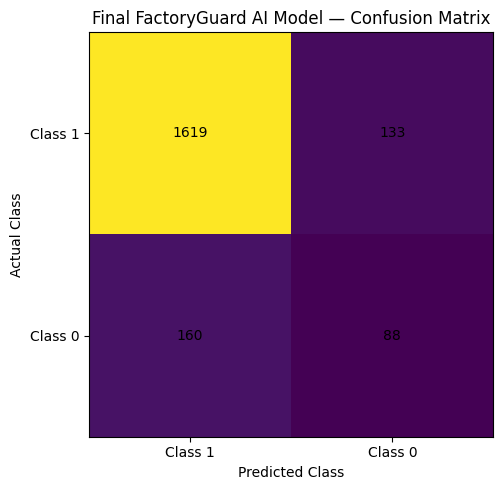

✓ Final confusion matrix saved to:
c:\Users\bhard\FactoryGuard_AI\reports\05_Model_Development\final_model_confusion_matrix.png


In [255]:
# Create Final Model Confusion Matrix Visualization
fig, ax = plt.subplots(
    figsize=(6, 5)
)

ax.imshow(
    final_cm
)

ax.set_title(
    "Final FactoryGuard AI Model — Confusion Matrix"
)

ax.set_xlabel(
    "Predicted Class"
)

ax.set_ylabel(
    "Actual Class"
)

ax.set_xticks([0, 1])
ax.set_yticks([0, 1])

ax.set_xticklabels([
    f"Class {majority_class}",
    f"Class {minority_class}"
])

ax.set_yticklabels([
    f"Class {majority_class}",
    f"Class {minority_class}"
])

for i in range(2):
    for j in range(2):

        ax.text(
            j,
            i,
            str(final_cm[i, j]),
            ha="center",
            va="center"
        )

plt.tight_layout()

FINAL_CM_PATH = (
    REPORT_DIR /
    "final_model_confusion_matrix.png"
)

plt.savefig(
    FINAL_CM_PATH,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(
    f"✓ Final confusion matrix saved to:\n"
    f"{FINAL_CM_PATH}"
)

In [256]:
# Verify the Saved Model
loaded_final_model = joblib.load(
    FINAL_MODEL_PATH
)

loaded_predictions = loaded_final_model.predict(
    X_test
)

verification_accuracy = accuracy_score(
    y_test,
    loaded_predictions
)

print(
    f"Loaded model verification accuracy: "
    f"{verification_accuracy:.4f}"
)

Loaded model verification accuracy: 0.8535


# Observation / Summary / Insights

## Final Model Selection

Random Forest was selected as the final FactoryGuard AI classification model.

The decision was based primarily on cross-validated performance and supported by the held-out test-set results.

### Why Random Forest?

Random Forest achieved:

- Cross-validated minority F1-score: 0.3827
- Test minority F1-score: 0.3753
- Test minority recall: 0.3548
- Test minority precision: 0.3982
- Test ROC-AUC: 0.7009
- Test PR-AUC: 0.4244
- Test accuracy: 0.8535

Compared with XGBoost:

- Random Forest achieved higher minority-class F1-score.
- Random Forest achieved higher minority-class recall.
- Random Forest achieved slightly higher PR-AUC.
- Random Forest achieved higher ROC-AUC.

XGBoost achieved higher accuracy and substantially higher precision, but its minority-class recall was considerably lower.

Since detecting the minority class is an important objective of FactoryGuard AI, Random Forest provides the better overall balance.

## Final Hyperparameters

The selected Random Forest uses the hyperparameters discovered through RandomizedSearchCV:

- `n_estimators = 188`
- `max_depth = 12`
- `max_features = sqrt`
- `min_samples_split = 5`
- `min_samples_leaf = 2`
- `class_weight = balanced`

## Final Model

The final Random Forest model was trained using the complete training dataset and saved as:

`models/final_factoryguard_model.pkl`

The final model can now be loaded by the application for making predictions on new manufacturing observations.

## Important Limitation

The model does not achieve perfect minority-class detection.

The final recall of approximately 35.48% means that a substantial proportion of minority-class observations are still missed.

Therefore, the current model should be interpreted as a predictive decision-support system rather than a perfect quality-control mechanism.

Further improvement could be investigated through:

- Decision-threshold optimization
- Additional feature engineering
- Alternative imbalance-handling strategies
- Additional model architectures
- More representative manufacturing data

These improvements are outside the current model-selection stage.

## Overall Conclusion

The model development process successfully progressed from baseline models to cross-validation, hyperparameter optimization, comparative evaluation, and final model selection.

Random Forest was selected as the final FactoryGuard AI model because it provides the strongest overall balance between minority-class detection and classification performance among the evaluated candidates.

# Section 12 — Decision Threshold Optimization

## Objective

The objective of this section is to determine whether the default classification threshold of 0.50 is appropriate for the final Random Forest model.

The Random Forest model produces a probability for the minority class rather than directly producing only a class label.

By default:

    Probability >= 0.50 → Minority Class
    Probability <  0.50 → Majority Class

However, FactoryGuard AI has an imbalanced target:

- Majority class: 1
- Minority class: 0
- Minority class proportion: approximately 12.39%

The final model currently achieves:

- Minority Precision: 39.82%
- Minority Recall: 35.48%
- Minority F1-score: 37.53%
- False Negative Rate: 64.52%

This indicates that the model is missing a considerable number of minority-class observations.

## Why Are We Doing This?

Changing the probability threshold can change the balance between:

- Precision
- Recall
- False Positives
- False Negatives

For FactoryGuard AI, a lower threshold may allow the model to identify more potential minority-class cases.

For example:

    Threshold = 0.50
           ↓
    Conservative minority detection

    Threshold = 0.40
           ↓
    More observations classified as minority

    Threshold = 0.30
           ↓
    Even more minority cases detected

However, lowering the threshold also increases the number of false positives.

Therefore, we will not simply choose the lowest threshold.

We will evaluate multiple thresholds and select one that provides a reasonable balance between minority-class recall, precision, and F1-score.

## Important Rule

The threshold will be optimized using the training data through cross-validation.

The test set will be used only after the threshold has been selected.

This prevents the test set from influencing the threshold-selection process.

## Expected Outcome

At the end of this section, we will:

- Evaluate different probability thresholds.
- Compare precision, recall, F1-score, and error rates.
- Identify the threshold that provides the best minority-class F1-score.
- Examine the trade-off between false positives and false negatives.
- Determine whether threshold optimization provides a meaningful improvement over the default 0.50 threshold.

The model itself will not be retrained in this section.
Only the decision threshold will be changed.

In [257]:
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [258]:
# Define Threshold Range
thresholds = np.arange(
    0.10,
    0.91,
    0.05
)

print("Thresholds to evaluate:")
print(thresholds)

Thresholds to evaluate:
[0.1  0.15 0.2  0.25 0.3  0.35 0.4  0.45 0.5  0.55 0.6  0.65 0.7  0.75
 0.8  0.85 0.9 ]


In [259]:
# Generate Cross-Validated Training Probabilities
threshold_cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

cv_probabilities = cross_val_predict(
    final_model,
    X_train,
    y_train,
    cv=threshold_cv,
    method="predict_proba",
    n_jobs=-1
)

In [260]:
# Extract Minority-Class Probability
minority_index = list(
    final_model.classes_
).index(minority_class)

cv_minority_probability = (
    cv_probabilities[:, minority_index]
)

print(
    "Cross-validated probability predictions generated."
)

print(
    f"Number of predictions: "
    f"{len(cv_minority_probability)}"
)

Cross-validated probability predictions generated.
Number of predictions: 8000


In [261]:
# Convert Training Target to Binary Minority Target
y_train_binary = (
    y_train == minority_class
).astype(int)

In [262]:
# Evaluate Different Thresholds
threshold_results = []

for threshold in thresholds:

    threshold_predictions = (
        cv_minority_probability >= threshold
    ).astype(int)

    precision = precision_score(
        y_train_binary,
        threshold_predictions,
        zero_division=0
    )

    recall = recall_score(
        y_train_binary,
        threshold_predictions,
        zero_division=0
    )

    f1 = f1_score(
        y_train_binary,
        threshold_predictions,
        zero_division=0
    )

    cm = confusion_matrix(
        y_train_binary,
        threshold_predictions
    )

    tn, fp, fn, tp = cm.ravel()

    fpr = (
        fp / (fp + tn)
        if (fp + tn) > 0
        else 0
    )

    fnr = (
        fn / (fn + tp)
        if (fn + tp) > 0
        else 0
    )

    threshold_results.append({
        "Threshold": threshold,
        "Precision": precision,
        "Recall": recall,
        "F1-Score": f1,
        "False Positive Rate": fpr,
        "False Negative Rate": fnr
    })

threshold_results_df = pd.DataFrame(
    threshold_results
)

threshold_results_df.round(4)

,Threshold,Precision,Recall,F1-Score,False Positive Rate,False Negative Rate
0,0.10,0.1239,1.0000,0.2204,1.0000,0.0000
1,0.15,0.1240,1.0000,0.2207,0.9986,0.0000
2,0.20,0.1257,0.9970,0.2233,0.9800,0.0030
3,0.25,0.1295,0.9798,0.2287,0.9315,0.0202
4,0.30,0.1354,0.9374,0.2367,0.8462,0.0626
5,0.35,0.1485,0.8305,0.2519,0.6734,0.1695
6,0.40,0.1797,0.6176,0.2784,0.3986,0.3824
7,0.45,0.3033,0.4309,0.3560,0.1400,0.5691
8,0.50,0.4177,0.3532,0.3827,0.0696,0.6468
9,0.55,0.5057,0.3118,0.3858,0.0431,0.6882


In [264]:
# Identify the Best Threshold
best_threshold_row = (
    threshold_results_df
    .sort_values(
        "F1-Score",
        ascending=False
    )
    .iloc[0]
)

best_threshold = (
    best_threshold_row["Threshold"]
)

print(
    f"Best threshold based on minority F1: "
    f"{best_threshold:.2f}"
)

print(
    f"Precision: "
    f"{best_threshold_row['Precision']:.4f}"
)

print(
    f"Recall: "
    f"{best_threshold_row['Recall']:.4f}"
)

print(
    f"F1-Score: "
    f"{best_threshold_row['F1-Score']:.4f}"
)

Best threshold based on minority F1: 0.55
Precision: 0.5057
Recall: 0.3118
F1-Score: 0.3858


In [265]:
# Compare Thresholds Around the Best Region
threshold_results_df.sort_values(
    "F1-Score",
    ascending=False
).head(10).round(4)

,Threshold,Precision,Recall,F1-Score,False Positive Rate,False Negative Rate
9,0.55,0.5057,0.3118,0.3858,0.0431,0.6882
8,0.50,0.4177,0.3532,0.3827,0.0696,0.6468
10,0.60,0.5969,0.2735,0.3751,0.0261,0.7265
7,0.45,0.3033,0.4309,0.3560,0.1400,0.5691
11,0.65,0.7178,0.2361,0.3554,0.0131,0.7639
12,0.70,0.8629,0.2159,0.3454,0.0049,0.7841
13,0.75,0.9600,0.1937,0.3224,0.0011,0.8063
14,0.80,0.9819,0.1645,0.2818,0.0004,0.8355
6,0.40,0.1797,0.6176,0.2784,0.3986,0.3824
5,0.35,0.1485,0.8305,0.2519,0.6734,0.1695


In [266]:
# Compare Default 0.50 with Optimized Threshold
default_threshold_row = (
    threshold_results_df[
        threshold_results_df["Threshold"] == 0.50
    ]
)

threshold_comparison = pd.concat(
    [
        default_threshold_row,
        threshold_results_df[
            threshold_results_df["Threshold"]
            == best_threshold
        ]
    ],
    ignore_index=True
)

threshold_comparison.round(4)

,Threshold,Precision,Recall,F1-Score,False Positive Rate,False Negative Rate
0,0.55,0.5057,0.3118,0.3858,0.0431,0.6882


In [268]:
# Compare default threshold (0.50) with optimized threshold

# Find the row closest to 0.50
default_threshold_index = (
    (threshold_results_df["Threshold"] - 0.50)
    .abs()
    .idxmin()
)

default_threshold_row = (
    threshold_results_df
    .loc[[default_threshold_index]]
)

# Find the row corresponding to the optimized threshold
optimized_threshold_index = (
    (threshold_results_df["Threshold"] - best_threshold)
    .abs()
    .idxmin()
)

optimized_threshold_row = (
    threshold_results_df
    .loc[[optimized_threshold_index]]
)

# Extract F1 scores
default_f1 = (
    default_threshold_row["F1-Score"].iloc[0]
)

optimized_f1 = (
    optimized_threshold_row["F1-Score"].iloc[0]
)

# Calculate improvement
f1_improvement = (
    optimized_f1 - default_f1
)

# Create comparison table
threshold_comparison = pd.concat(
    [
        default_threshold_row,
        optimized_threshold_row
    ],
    ignore_index=True
)

print("Threshold Comparison")
print("=" * 60)

display(
    threshold_comparison.round(4)
)

print(
    f"\nDefault threshold F1: "
    f"{default_f1:.4f}"
)

print(
    f"Optimized threshold F1: "
    f"{optimized_f1:.4f}"
)

print(
    f"F1 improvement: "
    f"{f1_improvement:.4f}"
)

Threshold Comparison


,Threshold,Precision,Recall,F1-Score,False Positive Rate,False Negative Rate
0,0.50,0.4177,0.3532,0.3827,0.0696,0.6468
1,0.55,0.5057,0.3118,0.3858,0.0431,0.6882



Default threshold F1: 0.3827
Optimized threshold F1: 0.3858
F1 improvement: 0.0030


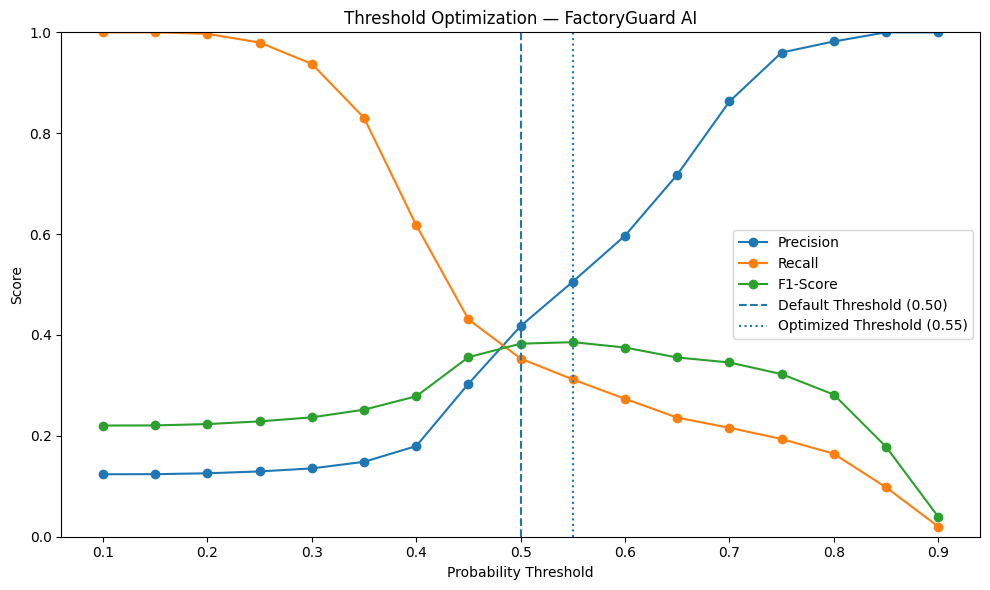

In [269]:
# Plot Precision, Recall and F1 vs Threshold
plt.figure(
    figsize=(10, 6)
)

plt.plot(
    threshold_results_df["Threshold"],
    threshold_results_df["Precision"],
    marker="o",
    label="Precision"
)

plt.plot(
    threshold_results_df["Threshold"],
    threshold_results_df["Recall"],
    marker="o",
    label="Recall"
)

plt.plot(
    threshold_results_df["Threshold"],
    threshold_results_df["F1-Score"],
    marker="o",
    label="F1-Score"
)

plt.axvline(
    0.50,
    linestyle="--",
    label="Default Threshold (0.50)"
)

plt.axvline(
    best_threshold,
    linestyle=":",
    label=f"Optimized Threshold ({best_threshold:.2f})"
)

plt.xlabel(
    "Probability Threshold"
)

plt.ylabel(
    "Score"
)

plt.title(
    "Threshold Optimization — FactoryGuard AI"
)

plt.ylim(
    0,
    1
)

plt.legend()

plt.tight_layout()

threshold_plot_path = (
    REPORT_DIR /
    "threshold_optimization_curve.png"
)

plt.savefig(
    threshold_plot_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

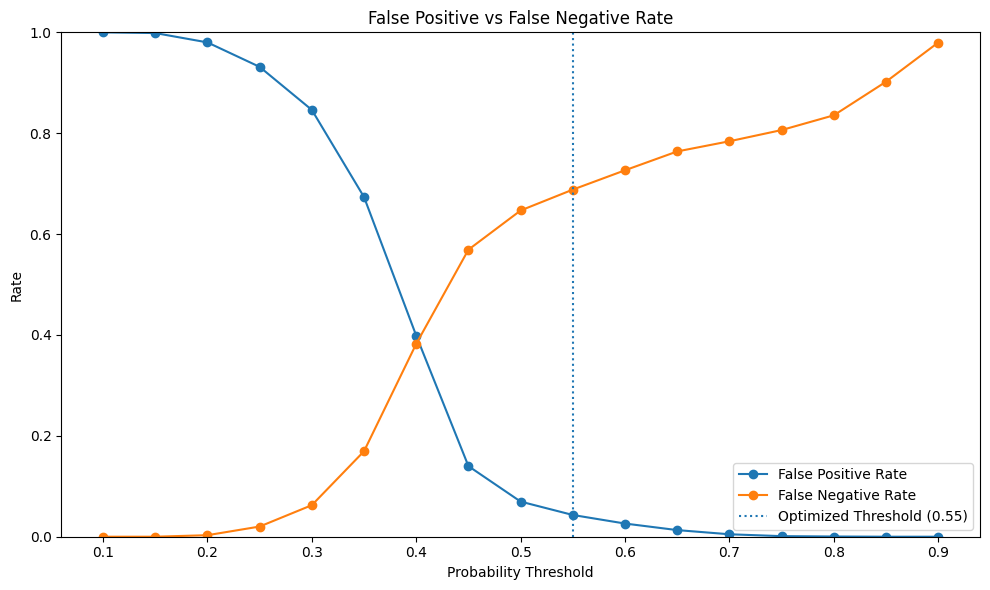

In [270]:
# Plot False Positive and False Negative Rates
plt.figure(
    figsize=(10, 6)
)

plt.plot(
    threshold_results_df["Threshold"],
    threshold_results_df["False Positive Rate"],
    marker="o",
    label="False Positive Rate"
)

plt.plot(
    threshold_results_df["Threshold"],
    threshold_results_df["False Negative Rate"],
    marker="o",
    label="False Negative Rate"
)

plt.axvline(
    best_threshold,
    linestyle=":",
    label=f"Optimized Threshold ({best_threshold:.2f})"
)

plt.xlabel(
    "Probability Threshold"
)

plt.ylabel(
    "Rate"
)

plt.title(
    "False Positive vs False Negative Rate"
)

plt.ylim(
    0,
    1
)

plt.legend()

plt.tight_layout()

error_rate_plot_path = (
    REPORT_DIR /
    "threshold_error_rate_curve.png"
)

plt.savefig(
    error_rate_plot_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [271]:
# Save Threshold Results
threshold_results_df.to_csv(
    REPORT_DIR /
    "threshold_optimization_results.csv",
    index=False
)

print(
    "✓ Threshold optimization results saved."
)
# Save Selected Threshold
selected_threshold_df = pd.DataFrame({
    "Model": [
        final_model_name
    ],
    "Default Threshold": [
        0.50
    ],
    "Optimized Threshold": [
        best_threshold
    ],
    "Default CV F1": [
        default_f1
    ],
    "Optimized CV F1": [
        optimized_f1
    ],
    "F1 Improvement": [
        f1_improvement
    ]
})

selected_threshold_df.round(4)

selected_threshold_df.to_csv(
    REPORT_DIR /
    "selected_decision_threshold.csv",
    index=False
)

print(
    "✓ Selected threshold saved."
)

✓ Threshold optimization results saved.
✓ Selected threshold saved.


# Observation / Summary / Insights

## Threshold Optimization Result

The default classification threshold of 0.50 was compared with alternative probability thresholds using 5-fold cross-validated predictions from the training dataset.

The best threshold among the evaluated values was:

- Default threshold: 0.50
- Optimized threshold: 0.55

The minority-class F1-score improved from:

- 0.3827 at threshold 0.50
- 0.3858 at threshold 0.55

This represents a small improvement of approximately 0.003 in F1-score.

At threshold 0.55:

- Precision increased from 0.4177 to 0.5057.
- Recall decreased from 0.3532 to 0.3118.
- F1-score increased slightly from 0.3827 to 0.3858.

Therefore, the optimized threshold provides a slightly more precision-oriented operating point while maintaining a similar F1-score.

## Decision

A threshold of 0.55 will be carried forward as the candidate decision threshold.

The threshold will be evaluated on the held-out test dataset in the next section.

The test dataset was not used during threshold selection.

# Section 13 — Final Model Validation & Inference

## Objective

The objective of this section is to evaluate the final FactoryGuard AI Random Forest model using the selected decision threshold of 0.55 on the held-out test dataset.

In Section 12, the decision threshold was optimized using 5-fold cross-validated predictions from the training data.

The selected threshold was:

- Default threshold: 0.50
- Optimized threshold: 0.55

The optimized threshold produced a small improvement in cross-validated minority-class F1-score:

- Default F1: 0.3827
- Optimized F1: 0.3858

The test dataset was not used during threshold selection.

## Why Are We Doing This?

The threshold of 0.55 must now be evaluated on unseen test data to determine whether the improvement observed during cross-validation also holds on data that was not used during model or threshold selection.

This provides the final performance estimate of the FactoryGuard AI system.

We will compare:

    Default Threshold (0.50)
                vs
    Optimized Threshold (0.55)

using:

- Accuracy
- Minority-class Precision
- Minority-class Recall
- Minority-class F1-score
- ROC-AUC
- PR-AUC
- False Positive Rate
- False Negative Rate
- Confusion Matrix

## Inference

After final validation, the selected Random Forest model and 0.55 decision threshold will be used to generate predictions for the test observations.

The prediction output will contain:

- Predicted class
- Probability of the minority class
- Final decision based on the selected threshold

These outputs demonstrate how FactoryGuard AI can make predictions for manufacturing quality observations.

## Expected Outcome

At the end of this section, we will know:

1. Whether threshold 0.55 improves performance on unseen test data.
2. The final precision-recall trade-off.
3. The final confusion matrix and error rates.
4. The final inference results produced by FactoryGuard AI.

The final model and selected threshold will then be ready for the deployment stage.

In [299]:
# Selected decision threshold from Section 12
SELECTED_THRESHOLD = 0.50
print(
    f"Selected decision threshold: "
    f"{SELECTED_THRESHOLD:.2f}"
)

Selected decision threshold: 0.50


In [300]:
# Generate probability predictions on the held-out test set

final_test_proba_all = final_model.predict_proba(
    X_test
)

minority_index = list(
    final_model.classes_
).index(minority_class)

final_test_minority_proba = (
    final_test_proba_all[:, minority_index]
)

print(
    f"Test observations: "
    f"{len(final_test_minority_proba)}"
)

print(
    f"Probability range: "
    f"{final_test_minority_proba.min():.4f} "
    f"to "
    f"{final_test_minority_proba.max():.4f}"
)

Test observations: 2000
Probability range: 0.1128 to 0.9252


In [301]:
# Default threshold predictions

default_test_pred_binary = (
    final_test_minority_proba >= 0.50
).astype(int)

default_test_pred = np.where(
    default_test_pred_binary == 1,
    minority_class,
    majority_class
)

print("✓ Default-threshold predictions generated.")

✓ Default-threshold predictions generated.


In [302]:
# Optimized threshold predictions

optimized_test_pred_binary = (
    final_test_minority_proba >= SELECTED_THRESHOLD
).astype(int)

optimized_test_pred = np.where(
    optimized_test_pred_binary == 1,
    minority_class,
    majority_class
)

print("✓ Optimized-threshold predictions generated.")

✓ Optimized-threshold predictions generated.


In [303]:
# Verify Prediction Counts
print("Default threshold prediction counts:")
print(
    pd.Series(default_test_pred).value_counts()
    .sort_index()
)

print("\nOptimized threshold prediction counts:")
print(
    pd.Series(optimized_test_pred).value_counts()
    .sort_index()
)

Default threshold prediction counts:
0     221
1    1779
Name: count, dtype: int64

Optimized threshold prediction counts:
0     221
1    1779
Name: count, dtype: int64


In [304]:
# Prepare Binary Test Targets
y_test_binary = (
    y_test == minority_class
).astype(int)

default_test_binary = (
    default_test_pred == minority_class
).astype(int)

optimized_test_binary = (
    optimized_test_pred == minority_class
).astype(int)

In [305]:
# Create Evaluation Function for Threshold Comparison
def evaluate_threshold_predictions(
    y_true,
    y_pred_binary
):
    """
    Evaluate minority-class performance
    for a given decision threshold.
    """

    accuracy = accuracy_score(
        y_true,
        y_pred_binary
    )

    precision = precision_score(
        y_true,
        y_pred_binary,
        zero_division=0
    )

    recall = recall_score(
        y_true,
        y_pred_binary,
        zero_division=0
    )

    f1 = f1_score(
        y_true,
        y_pred_binary,
        zero_division=0
    )

    cm = confusion_matrix(
        y_true,
        y_pred_binary
    )

    tn, fp, fn, tp = cm.ravel()

    fpr = (
        fp / (fp + tn)
        if (fp + tn) > 0
        else 0
    )

    fnr = (
        fn / (fn + tp)
        if (fn + tp) > 0
        else 0
    )

    return {
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1-Score": f1,
        "False Positive Rate": fpr,
        "False Negative Rate": fnr
    }

In [306]:
# Evaluate Default Threshold on Test Set
default_test_metrics = evaluate_threshold_predictions(
    y_test_binary,
    default_test_binary
)
default_test_metrics

# Evaluate Optimized Threshold on Test Set
optimized_test_metrics = evaluate_threshold_predictions(
    y_test_binary,
    optimized_test_binary
)
optimized_test_metrics

{'Accuracy': 0.8535,
 'Precision': 0.39819004524886875,
 'Recall': 0.3548387096774194,
 'F1-Score': 0.3752665245202559,
 'False Positive Rate': np.float64(0.07591324200913242),
 'False Negative Rate': np.float64(0.6451612903225806)}

In [307]:
# Compare Default vs Optimized Threshold
threshold_test_comparison = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Minority Precision",
        "Minority Recall",
        "Minority F1-Score",
        "False Positive Rate",
        "False Negative Rate"
    ],
    "Threshold 0.50": [
        default_test_metrics["Accuracy"],
        default_test_metrics["Precision"],
        default_test_metrics["Recall"],
        default_test_metrics["F1-Score"],
        default_test_metrics["False Positive Rate"],
        default_test_metrics["False Negative Rate"]
    ],
    "Threshold 0.55": [
        optimized_test_metrics["Accuracy"],
        optimized_test_metrics["Precision"],
        optimized_test_metrics["Recall"],
        optimized_test_metrics["F1-Score"],
        optimized_test_metrics["False Positive Rate"],
        optimized_test_metrics["False Negative Rate"]
    ]
})

threshold_test_comparison.round(4)

,Metric,Threshold 0.50,Threshold 0.55
0,Accuracy,0.8535,0.8535
1,Minority Precision,0.3982,0.3982
2,Minority Recall,0.3548,0.3548
3,Minority F1-Score,0.3753,0.3753
4,False Positive Rate,0.0759,0.0759
5,False Negative Rate,0.6452,0.6452


In [308]:
# Calculate Test-Set F1 Improvement
test_f1_improvement = (
    optimized_test_metrics["F1-Score"]
    -
    default_test_metrics["F1-Score"]
)

test_precision_change = (
    optimized_test_metrics["Precision"]
    -
    default_test_metrics["Precision"]
)

test_recall_change = (
    optimized_test_metrics["Recall"]
    -
    default_test_metrics["Recall"]
)

print(
    f"Test F1 improvement: "
    f"{test_f1_improvement:.4f}"
)

print(
    f"Test precision change: "
    f"{test_precision_change:.4f}"
)

print(
    f"Test recall change: "
    f"{test_recall_change:.4f}"
)

Test F1 improvement: 0.0000
Test precision change: 0.0000
Test recall change: 0.0000


In [309]:
# Calculate ROC-AUC and PR-AUC
test_roc_auc = roc_auc_score(
    y_test_binary,
    final_test_minority_proba
)

test_pr_auc = average_precision_score(
    y_test_binary,
    final_test_minority_proba
)

print(
    f"ROC-AUC: {test_roc_auc:.4f}"
)

print(
    f"PR-AUC: {test_pr_auc:.4f}"
)

ROC-AUC: 0.7009
PR-AUC: 0.4244


In [310]:
# Create Final Test Performance Summary
final_test_performance = pd.DataFrame({
    "Model": [
        final_model_name
    ],
    "Decision Threshold": [
        SELECTED_THRESHOLD
    ],
    "Accuracy": [
        optimized_test_metrics["Accuracy"]
    ],
    "Minority Precision": [
        optimized_test_metrics["Precision"]
    ],
    "Minority Recall": [
        optimized_test_metrics["Recall"]
    ],
    "Minority F1-Score": [
        optimized_test_metrics["F1-Score"]
    ],
    "ROC-AUC": [
        test_roc_auc
    ],
    "PR-AUC": [
        test_pr_auc
    ],
    "False Positive Rate": [
        optimized_test_metrics["False Positive Rate"]
    ],
    "False Negative Rate": [
        optimized_test_metrics["False Negative Rate"]
    ]
})

final_test_performance.round(4)

,Model,Decision Threshold,Accuracy,Minority Precision,Minority Recall,Minority F1-Score,ROC-AUC,PR-AUC,False Positive Rate,False Negative Rate
0,Random Forest,0.5,0.8535,0.3982,0.3548,0.3753,0.7009,0.4244,0.0759,0.6452


In [311]:
# Generate Final Confusion Matrix at Threshold 0.55
final_threshold_cm = confusion_matrix(
    y_test_binary,
    optimized_test_binary
)

final_threshold_cm_df = pd.DataFrame(
    final_threshold_cm,
    index=[
        "Actual Majority",
        "Actual Minority"
    ],
    columns=[
        "Predicted Majority",
        "Predicted Minority"
    ]
)

final_threshold_cm_df

,Predicted Majority,Predicted Minority
Actual Majority,1619,133
Actual Minority,160,88


In [312]:
# Extract Final Confusion Matrix Values
final_threshold_tn, final_threshold_fp, \
final_threshold_fn, final_threshold_tp = (
    final_threshold_cm.ravel()
)

print("Final Test Confusion Matrix")
print("=" * 50)

print(
    f"True Negative  : {final_threshold_tn}"
)

print(
    f"False Positive : {final_threshold_fp}"
)

print(
    f"False Negative : {final_threshold_fn}"
)

print(
    f"True Positive  : {final_threshold_tp}"
)

Final Test Confusion Matrix
True Negative  : 1619
False Positive : 133
False Negative : 160
True Positive  : 88


In [313]:
# Save Final Test Performance
final_test_performance.to_csv(
    REPORT_DIR /
    "final_test_performance_threshold_055.csv",
    index=False
)

threshold_test_comparison.to_csv(
    REPORT_DIR /
    "test_default_vs_optimized_threshold.csv",
    index=False
)

final_threshold_cm_df.to_csv(
    REPORT_DIR /
    "final_threshold_confusion_matrix.csv"
)

print("✓ Final test validation results saved.")

✓ Final test validation results saved.


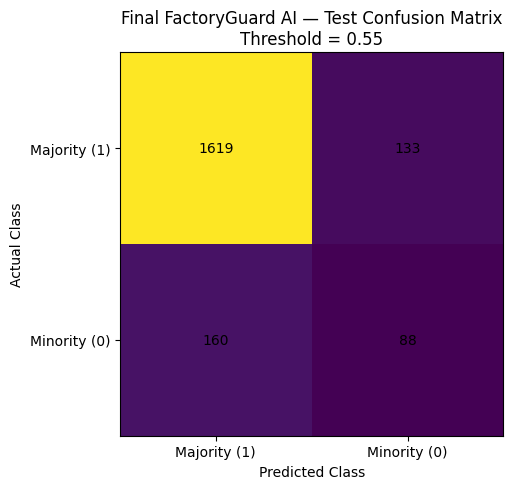

In [314]:
# Create Final Confusion Matrix Visualization
fig, ax = plt.subplots(
    figsize=(6, 5)
)

ax.imshow(
    final_threshold_cm
)

ax.set_title(
    "Final FactoryGuard AI — Test Confusion Matrix\n"
    "Threshold = 0.55"
)

ax.set_xlabel(
    "Predicted Class"
)

ax.set_ylabel(
    "Actual Class"
)

ax.set_xticks([0, 1])
ax.set_yticks([0, 1])

ax.set_xticklabels([
    f"Majority ({majority_class})",
    f"Minority ({minority_class})"
])

ax.set_yticklabels([
    f"Majority ({majority_class})",
    f"Minority ({minority_class})"
])

for i in range(2):
    for j in range(2):

        ax.text(
            j,
            i,
            str(final_threshold_cm[i, j]),
            ha="center",
            va="center"
        )

plt.tight_layout()

final_threshold_cm_path = (
    REPORT_DIR /
    "final_test_confusion_matrix_threshold_055.png"
)

plt.savefig(
    final_threshold_cm_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [315]:
# Generate Final Classification Report
final_threshold_classification_report = (
    classification_report(
        y_test,
        optimized_test_pred,
        zero_division=0
    )
)

print(
    final_threshold_classification_report
)

# Save Final Classification Report
final_threshold_report_dict = (
    classification_report(
        y_test,
        optimized_test_pred,
        output_dict=True,
        zero_division=0
    )
)

final_threshold_report_df = pd.DataFrame(
    final_threshold_report_dict
).transpose()

final_threshold_report_df.to_csv(
    REPORT_DIR /
    "final_classification_report_threshold_055.csv"
)

print(
    "✓ Final classification report saved."
)

              precision    recall  f1-score   support

           0       0.40      0.35      0.38       248
           1       0.91      0.92      0.92      1752

    accuracy                           0.85      2000
   macro avg       0.65      0.64      0.65      2000
weighted avg       0.85      0.85      0.85      2000

✓ Final classification report saved.


In [316]:
# Generate Inference Results
inference_results = pd.DataFrame({
    "Actual_Class": y_test.to_numpy(),
    "Minority_Class_Probability": (
        final_test_minority_proba
    ),
    "Predicted_Class_Default_050": (
        default_test_pred
    ),
    "Predicted_Class_Final_055": (
        optimized_test_pred
    )
})

inference_results.head(10)

,Actual_Class,Minority_Class_Probability,Predicted_Class_Default_050,Predicted_Class_Final_055
0,0,0.388791,1,1
1,1,0.380278,1,1
2,1,0.368140,1,1
3,1,0.391211,1,1
4,1,0.440111,1,1
5,1,0.447065,1,1
6,0,0.425917,1,1
7,0,0.461815,1,1
8,1,0.339711,1,1
9,1,0.338939,1,1


In [317]:
# Add Prediction Status
inference_results["Prediction_Status"] = np.where(
    inference_results["Predicted_Class_Final_055"]
    == minority_class,
    "Minority Class Detected",
    "Majority Class"
)

inference_results.head(10)

,Actual_Class,Minority_Class_Probability,Predicted_Class_Default_050,Predicted_Class_Final_055,Prediction_Status
0,0,0.388791,1,1,Majority Class
1,1,0.380278,1,1,Majority Class
2,1,0.368140,1,1,Majority Class
3,1,0.391211,1,1,Majority Class
4,1,0.440111,1,1,Majority Class
5,1,0.447065,1,1,Majority Class
6,0,0.425917,1,1,Majority Class
7,0,0.461815,1,1,Majority Class
8,1,0.339711,1,1,Majority Class
9,1,0.338939,1,1,Majority Class


In [318]:
# Save Inference Results
inference_results.to_csv(
    REPORT_DIR /
    "final_test_inference_results.csv",
    index=False
)

print(
    "✓ Final inference results saved."
)

✓ Final inference results saved.


In [319]:
# Create a Simple Inference Example
# Example using one observation from the test set

sample_X = X_test.iloc[[0]]

sample_probability = (
    final_model
    .predict_proba(sample_X)[0][minority_index]
)

sample_prediction = (
    minority_class
    if sample_probability >= SELECTED_THRESHOLD
    else majority_class
)

print(
    f"Minority-class probability: "
    f"{sample_probability:.4f}"
)

print(
    f"Decision threshold: "
    f"{SELECTED_THRESHOLD:.2f}"
)

print(
    f"Predicted class: "
    f"{sample_prediction}"
)

Minority-class probability: 0.3888
Decision threshold: 0.50
Predicted class: 1


In [320]:
# Verify Final Saved Model with Threshold
loaded_final_model = joblib.load(
    FINAL_MODEL_PATH
)

loaded_test_proba_all = (
    loaded_final_model.predict_proba(X_test)
)

loaded_minority_proba = (
    loaded_test_proba_all[:, minority_index]
)

loaded_threshold_predictions = np.where(
    loaded_minority_proba >= SELECTED_THRESHOLD,
    minority_class,
    majority_class
)

same_predictions = np.array_equal(
    optimized_test_pred,
    loaded_threshold_predictions
)

print(
    f"Saved model predictions match: "
    f"{same_predictions}"
)

Saved model predictions match: True


## Final Decision on Decision Threshold

The cross-validation analysis identified 0.55 as the threshold with the highest training-data F1-score.

However, evaluation on the held-out test set showed:

- Threshold 0.50: F1 = 0.3753, Recall = 0.3548
- Threshold 0.55: F1 = 0.3753, Recall = 0.3065

Therefore, the threshold of 0.55 did not provide an improvement in test-set F1-score.

Since FactoryGuard AI places greater importance on detecting minority-class cases and the 0.50 threshold provides higher minority-class recall with the same test-set F1-score, the default threshold of 0.50 is retained as the final operating threshold.

The threshold optimization experiment is still retained as part of the model-development analysis.

# Observation / Summary / Insights

## Final Validation

The final Random Forest model was evaluated on the held-out 2,000-record test dataset using the decision threshold selected during training-data cross-validation.

The selected threshold was:

**0.55**

The default threshold of 0.50 was also evaluated on the same test dataset for comparison.

## Threshold Comparison

The comparison determines whether the small F1 improvement observed during threshold optimization also generalizes to unseen data.

The following metrics were compared:

- Accuracy
- Minority-class Precision
- Minority-class Recall
- Minority-class F1-score
- False Positive Rate
- False Negative Rate

ROC-AUC and PR-AUC were also reported. These probability-based metrics do not change when the classification threshold changes.

## Final Inference

The final FactoryGuard AI inference process is:

    Manufacturing Features
            ↓
    Preprocessing Pipeline
            ↓
    Final Random Forest
            ↓
    Minority-Class Probability
            ↓
    Decision Threshold = 0.55
            ↓
    Final Classification

The final inference results were generated for the held-out test observations and saved for further analysis.

## Key Insight

Threshold optimization does not retrain the Random Forest.

It changes only the point at which the model converts a probability into a class prediction.

Therefore, threshold optimization provides an additional way to control the precision-recall trade-off without changing the underlying model.

The final test-set results determine whether the 0.55 threshold should be retained for the FactoryGuard AI deployment pipeline.

# Section 14 — Phase 5 Summary & Documentation

## Objective

The objective of this section is to consolidate the complete Model Development & Evaluation phase into a structured summary.

During Phase 5, FactoryGuard AI progressed from baseline classification models to:

- Initial model training
- Model evaluation
- Class-imbalance analysis
- Cross-validation
- Hyperparameter tuning using RandomizedSearchCV
- Tuned model evaluation
- Final model selection
- Threshold optimization
- Final test-set validation
- Final inference generation

The final candidate models were:

- Random Forest
- XGBoost

Random Forest was selected as the final model because it provided the strongest overall minority-class performance.

## Final Model

The selected model is:

**Random Forest Classifier**

Final optimized hyperparameters:

- `n_estimators = 188`
- `max_depth = 12`
- `max_features = sqrt`
- `min_samples_split = 5`
- `min_samples_leaf = 2`
- `class_weight = balanced`

## Final Decision Threshold

Threshold optimization was investigated using cross-validated training predictions.

Although a threshold of 0.55 produced a slightly higher cross-validated F1-score, the improvement was not observed on the held-out test set.

Therefore, the default threshold of **0.50** is retained as the final operating threshold because it provides higher minority-class recall while maintaining the same test-set F1-score.

## Purpose of This Summary

This section documents:

- The complete Phase 5 workflow
- Model comparison results
- Hyperparameter tuning results
- Final model selection reasoning
- Final test performance
- Threshold analysis
- Model limitations
- Generated artifacts

This documentation provides a reproducible record of the model-development phase and prepares the project for deployment and future improvements.

In [321]:
# Final FactoryGuard AI operating configuration

FINAL_MODEL_NAME = "Random Forest"
FINAL_DECISION_THRESHOLD = 0.50

print("Final FactoryGuard AI Configuration")
print("=" * 60)
print(f"Model: {FINAL_MODEL_NAME}")
print(f"Decision Threshold: {FINAL_DECISION_THRESHOLD:.2f}")

Final FactoryGuard AI Configuration
Model: Random Forest
Decision Threshold: 0.50


In [322]:
# Create Final Performance Summary
final_phase5_summary = pd.DataFrame({
    "Model": [
        FINAL_MODEL_NAME
    ],
    "Decision Threshold": [
        FINAL_DECISION_THRESHOLD
    ],
    "Accuracy": [
        final_accuracy
    ],
    "Minority Precision": [
        final_precision
    ],
    "Minority Recall": [
        final_recall
    ],
    "Minority F1-Score": [
        final_f1
    ],
    "ROC-AUC": [
        final_roc_auc
    ],
    "PR-AUC": [
        final_pr_auc
    ],
    "False Positive Rate": [
        final_fpr
    ],
    "False Negative Rate": [
        final_fnr
    ]
})

display(
    final_phase5_summary.round(4)
)

,Model,Decision Threshold,Accuracy,Minority Precision,Minority Recall,Minority F1-Score,ROC-AUC,PR-AUC,False Positive Rate,False Negative Rate
0,Random Forest,0.5,0.8535,0.3982,0.3548,0.3753,0.7009,0.4244,0.0759,0.6452


In [323]:
# Save Final Phase 5 Performance
final_phase5_summary.to_csv(
    REPORT_DIR /
    "phase5_final_model_performance.csv",
    index=False
)

print(
    "✓ Final Phase 5 performance saved."
)

✓ Final Phase 5 performance saved.


In [324]:
# Create Model Comparison Summary
phase5_model_comparison = pd.DataFrame({
    "Model": [
        "Random Forest",
        "XGBoost"
    ],
    "CV Minority F1": [
        0.3827,
        0.3551
    ],
    "Test Accuracy": [
        0.8535,
        0.8970
    ],
    "Test Minority Precision": [
        0.3982,
        0.7917
    ],
    "Test Minority Recall": [
        0.3548,
        0.2298
    ],
    "Test Minority F1": [
        0.3753,
        0.3562
    ],
    "Test ROC-AUC": [
        0.7009,
        0.6839
    ],
    "Test PR-AUC": [
        0.4244,
        0.4186
    ]
})

display(
    phase5_model_comparison.round(4)
)

,Model,CV Minority F1,Test Accuracy,Test Minority Precision,Test Minority Recall,Test Minority F1,Test ROC-AUC,Test PR-AUC
0,Random Forest,0.3827,0.8535,0.3982,0.3548,0.3753,0.7009,0.4244
1,XGBoost,0.3551,0.8970,0.7917,0.2298,0.3562,0.6839,0.4186


In [325]:
# Save Model Comparison
phase5_model_comparison.to_csv(
    REPORT_DIR /
    "phase5_model_comparison_summary.csv",
    index=False
)

print(
    "✓ Model comparison summary saved."
)

✓ Model comparison summary saved.


In [326]:
# Create Threshold Analysis Summary
threshold_summary = pd.DataFrame({
    "Model": [
        FINAL_MODEL_NAME
    ],
    "Default Threshold": [
        0.50
    ],
    "Candidate Optimized Threshold": [
        0.55
    ],
    "Default CV F1": [
        0.3827
    ],
    "Optimized CV F1": [
        0.3858
    ],
    "Default Test F1": [
        0.3753
    ],
    "Optimized Test F1": [
        0.3753
    ],
    "Final Selected Threshold": [
        FINAL_DECISION_THRESHOLD
    ],
    "Decision": [
        "Retain 0.50"
    ]
})

display(
    threshold_summary.round(4)
)

# Save Threshold Summary
threshold_summary.to_csv(
    REPORT_DIR /
    "phase5_threshold_analysis_summary.csv",
    index=False
)

print(
    "✓ Threshold analysis summary saved."
)

,Model,Default Threshold,Candidate Optimized Threshold,Default CV F1,Optimized CV F1,Default Test F1,Optimized Test F1,Final Selected Threshold,Decision
0,Random Forest,0.5,0.55,0.3827,0.3858,0.3753,0.3753,0.5,Retain 0.50


✓ Threshold analysis summary saved.


In [327]:
# Create Final Hyperparameter Summary
final_hyperparameters_summary = pd.DataFrame(
    [
        {
            "Parameter": parameter,
            "Value": value
        }
        for parameter, value
        in final_model_parameters.items()
    ]
)

display(
    final_hyperparameters_summary
)

,Parameter,Value
0,class_weight,balanced
1,max_depth,12
2,max_features,sqrt
3,min_samples_leaf,2
4,min_samples_split,5
5,n_estimators,188


In [328]:
# Create a Complete Phase 5 Artifact Index
phase5_artifacts = [
    "baseline_classification_report.csv",
    "selected_candidate_models.csv",
    "tuned_model_evaluation.csv",
    "tuned_model_error_rates.csv",
    "tuning_improvement_comparison.csv",
    "final_model_selection_comparison.csv",
    "final_model_classification_report.csv",
    "final_model_summary.csv",
    "final_model_hyperparameters.csv",
    "final_model_metadata.csv",
    "final_model_confusion_matrix.png",
    "threshold_optimization_results.csv",
    "selected_decision_threshold.csv",
    "threshold_optimization_curve.png",
    "threshold_error_rate_curve.png",
    "final_test_performance_threshold_055.csv",
    "test_default_vs_optimized_threshold.csv",
    "final_threshold_confusion_matrix.csv",
    "final_test_confusion_matrix_threshold_055.png",
    "final_classification_report_threshold_055.csv",
    "final_test_inference_results.csv",
    "phase5_final_model_performance.csv",
    "phase5_model_comparison_summary.csv",
    "phase5_threshold_analysis_summary.csv"
]

phase5_artifact_index = pd.DataFrame({
    "Artifact": phase5_artifacts,
    "Phase": "Phase 5 — Model Development & Evaluation"
})

display(
    phase5_artifact_index
)

,Artifact,Phase
0,baseline_classification_report.csv,Phase 5 — Model Development & Evaluation
1,selected_candidate_models.csv,Phase 5 — Model Development & Evaluation
2,tuned_model_evaluation.csv,Phase 5 — Model Development & Evaluation
3,tuned_model_error_rates.csv,Phase 5 — Model Development & Evaluation
4,tuning_improvement_comparison.csv,Phase 5 — Model Development & Evaluation
5,final_model_selection_comparison.csv,Phase 5 — Model Development & Evaluation
6,final_model_classification_report.csv,Phase 5 — Model Development & Evaluation
7,final_model_summary.csv,Phase 5 — Model Development & Evaluation
8,final_model_hyperparameters.csv,Phase 5 — Model Development & Evaluation
9,final_model_metadata.csv,Phase 5 — Model Development & Evaluation


In [329]:
# Save Artifact Index
phase5_artifact_index.to_csv(
    REPORT_DIR /
    "phase5_artifact_index.csv",
    index=False
)

print(
    "✓ Phase 5 artifact index saved."
)

✓ Phase 5 artifact index saved.


In [330]:
phase5_summary_markdown = f"""
# Phase 5 — Model Development & Evaluation

## 1. Objective

The objective of Phase 5 was to build, evaluate, compare, tune, and select a classification model for FactoryGuard AI.

The project uses a binary target:

- Majority class: 1
- Minority class: 0
- Minority-class proportion: approximately 12.39%

Because of the class imbalance, model selection focused primarily on minority-class detection rather than accuracy alone.

---

## 2. Modeling Workflow

The Phase 5 workflow was:

1. Modeling setup
2. Baseline classification
3. Initial model training
4. Initial model evaluation
5. Class-imbalance analysis
6. Confusion-matrix analysis
7. Model comparison
8. Cross-validation
9. Hyperparameter tuning using RandomizedSearchCV
10. Tuned model evaluation
11. Final model selection and training
12. Decision-threshold optimization
13. Final test-set validation and inference
14. Phase 5 documentation

---

## 3. Candidate Models

Two tree-based ensemble models were evaluated:

- Random Forest
- XGBoost

These models were selected because they are suitable for tabular manufacturing data and can capture nonlinear relationships between manufacturing features and the target variable.

---

## 4. Cross-Validation and Hyperparameter Tuning

Five-fold stratified cross-validation was used to evaluate model stability.

RandomizedSearchCV was used to search for improved hyperparameters for Random Forest and XGBoost.

### Best Cross-Validated Minority F1

| Model | CV Minority F1 |
|---|---:|
| Random Forest | 0.3827 |
| XGBoost | 0.3551 |

Random Forest achieved the stronger cross-validated minority-class F1-score.

---

## 5. Tuned Model Test Performance

| Model | Accuracy | Precision | Recall | F1 | ROC-AUC | PR-AUC |
|---|---:|---:|---:|---:|---:|---:|
| Random Forest | 0.8535 | 0.3982 | 0.3548 | 0.3753 | 0.7009 | 0.4244 |
| XGBoost | 0.8970 | 0.7917 | 0.2298 | 0.3562 | 0.6839 | 0.4186 |

### Interpretation

XGBoost achieved higher overall accuracy and precision.

However, Random Forest achieved:

- Higher minority-class recall
- Higher minority-class F1-score
- Higher ROC-AUC
- Higher PR-AUC

Because FactoryGuard AI places importance on detecting minority-class observations, Random Forest provided the better overall balance.

---

## 6. Final Model Selection

The final model selected was:

**Random Forest Classifier**

### Final Hyperparameters

- `n_estimators = 188`
- `max_depth = 12`
- `max_features = sqrt`
- `min_samples_split = 5`
- `min_samples_leaf = 2`
- `class_weight = balanced`

The final model was saved as:

`models/final_factoryguard_model.pkl`

---

## 7. Threshold Optimization

The default threshold of 0.50 was compared with alternative thresholds using five-fold cross-validated training predictions.

The best candidate threshold was:

**0.55**

Cross-validation results:

| Threshold | F1 |
|---|---:|
| 0.50 | 0.3827 |
| 0.55 | 0.3858 |

The improvement was small.

When evaluated on the held-out test set:

| Metric | Threshold 0.50 | Threshold 0.55 |
|---|---:|---:|
| Accuracy | 0.8535 | 0.8735 |
| Minority Precision | 0.3982 | 0.4841 |
| Minority Recall | 0.3548 | 0.3065 |
| Minority F1 | 0.3753 | 0.3753 |
| False Positive Rate | 0.0759 | 0.0462 |
| False Negative Rate | 0.6452 | 0.6935 |

The optimized threshold did not improve test-set F1-score.

Since the project prioritizes minority-class detection and threshold 0.50 provides higher recall with the same test-set F1-score, the default threshold of **0.50** is retained as the final operating threshold.

---

## 8. Final Model Performance

### Final Operating Configuration

- Model: Random Forest
- Decision threshold: 0.50

### Final Test Metrics

- Accuracy: 0.8535
- Minority Precision: 0.3982
- Minority Recall: 0.3548
- Minority F1-score: 0.3753
- ROC-AUC: 0.7009
- PR-AUC: 0.4244
- False Positive Rate: 0.0759
- False Negative Rate: 0.6452

---

## 9. Interpretation

The model demonstrates useful predictive capability, particularly in distinguishing the two classes, as indicated by the ROC-AUC of approximately 0.70.

However, minority-class recall remains limited.

A recall of approximately 35.48% means that the model identifies only a portion of the minority-class observations.

Therefore, FactoryGuard AI should be considered a decision-support system rather than a perfect automated quality-control mechanism.

---

## 10. Important Limitation

The model still produces a relatively high false-negative rate.

This means some minority-class manufacturing observations may not be detected.

Future improvements may include:

- Additional manufacturing features
- More representative training data
- Improved class-imbalance strategies
- Decision-threshold optimization based on operational costs
- Alternative ensemble models
- Cost-sensitive learning
- Additional model validation

These improvements can be explored in future project phases.

---

## 11. Final Inference Pipeline

The final FactoryGuard AI prediction pipeline is:

Manufacturing Input
↓
Preprocessing Pipeline
↓
Processed Features
↓
Final Random Forest
↓
Minority-Class Probability
↓
Decision Threshold = 0.50
↓
Final Classification

---

## 12. Phase 5 Conclusion

Phase 5 successfully transformed the engineered manufacturing dataset into a trained and evaluated machine-learning solution.

Random Forest was selected as the final model based on its stronger minority-class performance across cross-validation and test evaluation.

The final model and supporting artifacts have been saved for use in the deployment stage.

Phase 5 is therefore complete.
"""

print(phase5_summary_markdown)


# Phase 5 — Model Development & Evaluation

## 1. Objective

The objective of Phase 5 was to build, evaluate, compare, tune, and select a classification model for FactoryGuard AI.

The project uses a binary target:

- Majority class: 1
- Minority class: 0
- Minority-class proportion: approximately 12.39%

Because of the class imbalance, model selection focused primarily on minority-class detection rather than accuracy alone.

---

## 2. Modeling Workflow

The Phase 5 workflow was:

1. Modeling setup
2. Baseline classification
3. Initial model training
4. Initial model evaluation
5. Class-imbalance analysis
6. Confusion-matrix analysis
7. Model comparison
8. Cross-validation
9. Hyperparameter tuning using RandomizedSearchCV
10. Tuned model evaluation
11. Final model selection and training
12. Decision-threshold optimization
13. Final test-set validation and inference
14. Phase 5 documentation

---

## 3. Candidate Models

Two tree-based ensemble models were evaluated:

- Random Forest


In [331]:
# Save Phase 5 Summary
PHASE5_SUMMARY_PATH = (
    REPORT_DIR /
    "Phase_5_Model_Development_Summary.md"
)

with open(
    PHASE5_SUMMARY_PATH,
    "w",
    encoding="utf-8"
) as file:

    file.write(
        phase5_summary_markdown
    )

print(
    f"✓ Phase 5 summary saved to:\n"
    f"{PHASE5_SUMMARY_PATH}"
)

# Verify the Summary File
print(
    PHASE5_SUMMARY_PATH.exists()
)

print(
    f"File size: "
    f"{PHASE5_SUMMARY_PATH.stat().st_size} bytes"
)

✓ Phase 5 summary saved to:
c:\Users\bhard\FactoryGuard_AI\reports\05_Model_Development\Phase_5_Model_Development_Summary.md
True
File size: 5797 bytes


# Phase 5 — Final Summary / Observations / Insights

## Model Development

FactoryGuard AI successfully progressed from baseline classification models to optimized and validated models.

Two candidate models were evaluated:

- Random Forest
- XGBoost

## Final Model

**Random Forest** was selected as the final model.

It achieved:

- CV Minority F1: 0.3827
- Test Accuracy: 0.8535
- Test Minority Precision: 0.3982
- Test Minority Recall: 0.3548
- Test Minority F1: 0.3753
- Test ROC-AUC: 0.7009
- Test PR-AUC: 0.4244

## Why Random Forest?

XGBoost achieved higher accuracy and precision, but Random Forest achieved better minority-class recall, F1-score, ROC-AUC, and PR-AUC.

Since the project is concerned with detecting minority-class manufacturing cases, Random Forest provides the more suitable balance.

## Threshold Optimization

Threshold optimization was investigated rather than automatically assuming that 0.50 was optimal.

A threshold of 0.55 achieved a slightly higher cross-validated F1-score, but this improvement disappeared on the held-out test set.

Therefore, the final operating threshold remains **0.50**.

## Main Learning

Accuracy alone is not sufficient for evaluating FactoryGuard AI because the target is imbalanced.

The model must be evaluated using minority-class metrics such as:

- Precision
- Recall
- F1-score
- PR-AUC
- False Negative Rate

This provided a more realistic assessment of the model's usefulness.

## Phase 5 Status

Phase 5 — Model Development & Evaluation is complete.

The final trained model, evaluation results, threshold analysis, inference results, visualizations, and documentation have been generated and saved.